In [6]:
# =========================================================
# FINAL ARCHITECTURE:
# 1) Direct status LightGBM
# 2) Recursive target LightGBM
# 3) Chronos-2 (optional, with safe fallback)
# 4) Horizon-wise blending
# 5) Horizon-wise scaling
# 6) Final submission
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import math
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor

# -----------------------------
# SETTINGS
# -----------------------------
TRAIN_PATH = "data/train.parquet"
TEST_PATH = "data/test.parquet"

HORIZON = 10
N_FOLDS = 5
FOLD_STEP = 10

DIRECT_TRAIN_DAYS = 21   # окно для direct-модели
USE_CHRONOS = True       # если Chronos не сработает, будет авто-fallback
CHRONOS_MODEL_NAME = "amazon/chronos-2"

# direct model
DIRECT_PARAMS = dict(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    min_child_samples=50,
    random_state=42,
    n_jobs=-1
)

# recursive model
RECURSIVE_PARAMS = dict(
    n_estimators=700,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_samples=50,
    random_state=42,
    n_jobs=-1
)

RECURSIVE_LAGS = [1, 2, 3, 4, 6, 8, 12, 24, 48, 96, 336]
RECURSIVE_ROLL_MEAN = [4, 8, 12, 24, 48, 96]
RECURSIVE_ROLL_STD = [8, 24, 48, 96]

DIRECT_TARGET_LAGS = [1, 2, 4, 8, 12, 24, 48, 96, 336]
DIRECT_STATUS_LAGS = [1, 2, 4]
SCALE_GRID = np.arange(0.90, 1.1001, 0.005)
WEIGHT_GRID_STEP = 0.1

# -----------------------------
# METRICS / UTILS
# -----------------------------
def wape_plus_rbias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = y_true.sum()
    wape = np.abs(y_pred - y_true).sum() / denom
    rbias = abs(y_pred.sum() / denom - 1)
    return wape + rbias

def metric_parts(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = y_true.sum()
    wape = np.abs(y_pred - y_true).sum() / denom
    rbias = abs(y_pred.sum() / denom - 1)
    return {
        "metric": wape + rbias,
        "wape": wape,
        "rbias": rbias,
        "true_sum": float(y_true.sum()),
        "pred_sum": float(y_pred.sum()),
    }

def make_backtest_folds(all_timestamps, horizon=10, n_folds=5, step=10):
    folds = []
    n = len(all_timestamps)
    for i in range(n_folds):
        valid_end = n - i * step
        valid_start = valid_end - horizon
        if valid_start <= 0:
            break
        train_ts = all_timestamps[:valid_start]
        valid_ts = all_timestamps[valid_start:valid_end]
        folds.append((train_ts, valid_ts))
    return folds[::-1]

def add_time_features(df):
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["hour"] = df["timestamp"].dt.hour.astype(np.int16)
    df["minute"] = df["timestamp"].dt.minute.astype(np.int16)
    df["dayofweek"] = df["timestamp"].dt.dayofweek.astype(np.int16)
    df["month"] = df["timestamp"].dt.month.astype(np.int16)
    df["dayofmonth"] = df["timestamp"].dt.day.astype(np.int16)
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(np.int8)
    df["tod_step"] = (df["hour"] * 2 + (df["minute"] // 30)).astype(np.int16)

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24.0)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24.0)
    df["tod_sin"] = np.sin(2 * np.pi * df["tod_step"] / 48.0)
    df["tod_cos"] = np.cos(2 * np.pi * df["tod_step"] / 48.0)
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7.0)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7.0)
    return df

def add_status_features(df, status_cols):
    df = df.copy()
    df["status_sum"] = df[status_cols].sum(axis=1)
    df["status_max"] = df[status_cols].max(axis=1)
    df["status_nnz"] = (df[status_cols] > 0).sum(axis=1)
    for c in ["status_5", "status_6", "status_4", "status_3"]:
        if c in df.columns:
            df[f"{c}_share"] = df[c] / (df["status_sum"] + 1.0)
    return df

def safe_div(a, b):
    return a / (b + 1.0)

def get_ts_index_map(all_timestamps):
    return {ts: i for i, ts in enumerate(all_timestamps)}

# -----------------------------
# LOAD DATA
# -----------------------------
train = pd.read_parquet(TRAIN_PATH)
test = pd.read_parquet(TEST_PATH)

train["timestamp"] = pd.to_datetime(train["timestamp"])
test["timestamp"] = pd.to_datetime(test["timestamp"])

train = train.sort_values(["route_id", "timestamp"]).reset_index(drop=True)
test = test.sort_values(["route_id", "timestamp"]).reset_index(drop=True)

status_cols = [c for c in train.columns if c.startswith("status_")]
route_to_office = train.groupby("route_id")["office_from_id"].first().to_dict()
test["office_from_id"] = test["route_id"].map(route_to_office)

print("train shape:", train.shape)
print("test shape :", test.shape)
display(train.head())
display(test.head())

all_timestamps = sorted(train["timestamp"].unique())
folds = make_backtest_folds(all_timestamps, horizon=HORIZON, n_folds=N_FOLDS, step=FOLD_STEP)

print("\nFolds:")
for i, (tr_ts, va_ts) in enumerate(folds, 1):
    print(i, tr_ts[0], tr_ts[-1], "|", va_ts[0], va_ts[-1], "|", len(va_ts))

# =========================================================
# DIRECT STATUS MODEL
# =========================================================
def build_direct_base(df):
    df = df.copy()
    df = add_time_features(df)
    df = add_status_features(df, status_cols)

    grp_target = df.groupby("route_id")["target_2h"]
    for lag in DIRECT_TARGET_LAGS:
        df[f"target_lag_{lag}"] = grp_target.shift(lag)

    grp = df.groupby("route_id")
    for c in status_cols + ["status_sum", "status_max", "status_nnz"]:
        for lag in DIRECT_STATUS_LAGS:
            df[f"{c}_lag_{lag}"] = grp[c].shift(lag)

    # rolling по status_sum / target
    df["status_sum_roll_mean_4"] = grp["status_sum"].shift(1).rolling(4).mean()
    df["status_sum_roll_mean_12"] = grp["status_sum"].shift(1).rolling(12).mean()
    df["status_sum_roll_mean_48"] = grp["status_sum"].shift(1).rolling(48).mean()
    df["target_roll_mean_4"] = grp["target_2h"].shift(1).rolling(4).mean()
    df["target_roll_mean_12"] = grp["target_2h"].shift(1).rolling(12).mean()
    df["target_roll_mean_48"] = grp["target_2h"].shift(1).rolling(48).mean()

    # route / office stats
    route_stats = df.groupby("route_id")["target_2h"].agg(
        route_mean="mean",
        route_std="std",
        route_zero_share=lambda x: (x == 0).mean()
    ).reset_index()
    route_stats["route_std"] = route_stats["route_std"].fillna(0.0)

    office_stats = df.groupby("office_from_id")["target_2h"].agg(
        office_mean="mean",
        office_std="std",
        office_zero_share=lambda x: (x == 0).mean()
    ).reset_index()
    office_stats["office_std"] = office_stats["office_std"].fillna(0.0)

    # route-time profiles
    route_tod = df.groupby(["route_id", "tod_step"])["target_2h"].mean().rename("route_tod_mean").reset_index()
    route_dow_tod = df.groupby(["route_id", "dayofweek", "tod_step"])["target_2h"].mean().rename("route_dow_tod_mean").reset_index()
    office_tod = df.groupby(["office_from_id", "tod_step"])["target_2h"].mean().rename("office_tod_mean").reset_index()

    df = df.merge(route_stats, on="route_id", how="left")
    df = df.merge(office_stats, on="office_from_id", how="left")
    df = df.merge(route_tod, on=["route_id", "tod_step"], how="left")
    df = df.merge(route_dow_tod, on=["route_id", "dayofweek", "tod_step"], how="left")
    df = df.merge(office_tod, on=["office_from_id", "tod_step"], how="left")

    # future targets
    for h in range(1, HORIZON + 1):
        df[f"target_step_{h}"] = grp["target_2h"].shift(-h)

    return df

direct_base_full = build_direct_base(train)

DIRECT_FEATURES = [
    "route_id", "office_from_id",
    "hour", "minute", "dayofweek", "month", "dayofmonth", "is_weekend", "tod_step",
    "hour_sin", "hour_cos", "tod_sin", "tod_cos", "dow_sin", "dow_cos",
    "status_sum", "status_max", "status_nnz",
    "route_mean", "route_std", "route_zero_share",
    "office_mean", "office_std", "office_zero_share",
    "route_tod_mean", "route_dow_tod_mean", "office_tod_mean",
] + status_cols

DIRECT_FEATURES += [c for c in direct_base_full.columns if c.endswith("_share")]
DIRECT_FEATURES += [f"target_lag_{lag}" for lag in DIRECT_TARGET_LAGS]
for c in status_cols + ["status_sum", "status_max", "status_nnz"]:
    DIRECT_FEATURES += [f"{c}_lag_{lag}" for lag in DIRECT_STATUS_LAGS]
DIRECT_FEATURES += [
    "status_sum_roll_mean_4", "status_sum_roll_mean_12", "status_sum_roll_mean_48",
    "target_roll_mean_4", "target_roll_mean_12", "target_roll_mean_48"
]

DIRECT_FEATURES = [c for c in DIRECT_FEATURES if c in direct_base_full.columns]
DIRECT_FEATURES = list(dict.fromkeys(DIRECT_FEATURES))

print("N DIRECT_FEATURES:", len(DIRECT_FEATURES))
dups = pd.Series(DIRECT_FEATURES).duplicated().sum()
print("DIRECT duplicate features:", dups)

def train_direct_models(train_cut_ts):
    """
    train_cut_ts = first validation timestamp
    Обучаем direct модели без leakage:
    origin rows берём только те, чьи target_step_10 не залезают в validation.
    """
    ts_sorted = all_timestamps
    ts_to_pos = get_ts_index_map(ts_sorted)
    valid_start_pos = ts_to_pos[train_cut_ts]
    max_train_origin_pos = valid_start_pos - HORIZON - 1

    if max_train_origin_pos < 0:
        raise ValueError("Not enough history for direct model fold.")

    max_train_origin_ts = ts_sorted[max_train_origin_pos]
    min_train_origin_ts = max_train_origin_ts - pd.Timedelta(days=DIRECT_TRAIN_DAYS)

    train_df = direct_base_full[
        (direct_base_full["timestamp"] >= min_train_origin_ts) &
        (direct_base_full["timestamp"] <= max_train_origin_ts)
    ].copy()

    train_df = train_df.dropna(subset=[f"target_step_{h}" for h in range(1, HORIZON + 1)])
    train_df = train_df.dropna(subset=[c for c in DIRECT_FEATURES if c in train_df.columns])

    models = {}
    for h in range(1, HORIZON + 1):
        y = train_df[f"target_step_{h}"].values
        model = LGBMRegressor(**DIRECT_PARAMS)
        model.fit(train_df[DIRECT_FEATURES], y)
        models[h] = model

    return models

def predict_direct_from_origin(models, origin_df, future_timestamps):
    """
    origin_df: одна строка на route_id, последний доступный снимок состояния.
    future_timestamps: список длины 10
    """
    origin_df = origin_df.copy()
    origin_df = origin_df.sort_values("route_id").reset_index(drop=True)

    X = origin_df[DIRECT_FEATURES].copy()
    preds = []

    for h, ts in enumerate(future_timestamps, start=1):
        pred = models[h].predict(X)
        pred = np.clip(pred, 0, None)
        step_df = origin_df[["route_id"]].copy()
        step_df["timestamp"] = ts
        step_df["horizon"] = h
        step_df["pred_direct"] = pred
        preds.append(step_df)

    return pd.concat(preds, ignore_index=True)

# =========================================================
# RECURSIVE TARGET MODEL
# =========================================================
def make_recursive_static_maps(train_df):
    df = add_time_features(train_df.copy())

    route_stats = df.groupby("route_id")["target_2h"].agg(
        route_mean="mean",
        route_std="std",
        route_min="min",
        route_max="max",
        route_zero_share=lambda x: (x == 0).mean(),
        route_q25=lambda x: x.quantile(0.25),
        route_q50="median",
        route_q75=lambda x: x.quantile(0.75),
    ).reset_index()
    route_stats["route_std"] = route_stats["route_std"].fillna(0.0)

    office_stats = df.groupby("office_from_id")["target_2h"].agg(
        office_mean="mean",
        office_std="std",
        office_zero_share=lambda x: (x == 0).mean(),
    ).reset_index()
    office_stats["office_std"] = office_stats["office_std"].fillna(0.0)

    route_tod = df.groupby(["route_id", "tod_step"])["target_2h"].mean().rename("route_tod_mean").reset_index()
    route_dow_tod = df.groupby(["route_id", "dayofweek", "tod_step"])["target_2h"].mean().rename("route_dow_tod_mean").reset_index()
    office_tod = df.groupby(["office_from_id", "tod_step"])["target_2h"].mean().rename("office_tod_mean").reset_index()

    return route_stats, office_stats, route_tod, route_dow_tod, office_tod

def build_recursive_training_matrix(train_df):
    df = add_time_features(train_df.copy())
    grp = df.groupby("route_id")["target_2h"]

    for lag in RECURSIVE_LAGS:
        df[f"lag_{lag}"] = grp.shift(lag)

    for w in RECURSIVE_ROLL_MEAN:
        df[f"roll_mean_{w}"] = grp.shift(1).rolling(w).mean()

    for w in RECURSIVE_ROLL_STD:
        df[f"roll_std_{w}"] = grp.shift(1).rolling(w).std()

    for w in [8, 24]:
        df[f"roll_min_{w}"] = grp.shift(1).rolling(w).min()
        df[f"roll_max_{w}"] = grp.shift(1).rolling(w).max()

    df["lag1_minus_lag48"] = df["lag_1"] - df["lag_48"]
    df["lag1_div_lag48"] = safe_div(df["lag_1"], df["lag_48"])
    df["lag48_minus_lag336"] = df["lag_48"] - df["lag_336"]
    df["lag48_div_lag336"] = safe_div(df["lag_48"], df["lag_336"])
    df["roll_mean_4_minus_48"] = df["roll_mean_4"] - df["roll_mean_48"]

    route_stats, office_stats, route_tod, route_dow_tod, office_tod = make_recursive_static_maps(train_df)
    df = df.merge(route_stats, on="route_id", how="left")
    df = df.merge(office_stats, on="office_from_id", how="left")
    df = df.merge(route_tod, on=["route_id", "tod_step"], how="left")
    df = df.merge(route_dow_tod, on=["route_id", "dayofweek", "tod_step"], how="left")
    df = df.merge(office_tod, on=["office_from_id", "tod_step"], how="left")

    feature_cols = [
        "route_id", "office_from_id",
        "hour", "minute", "dayofweek", "month", "dayofmonth", "is_weekend", "tod_step",
        "hour_sin", "hour_cos", "tod_sin", "tod_cos", "dow_sin", "dow_cos",
    ]

    feature_cols += [f"lag_{lag}" for lag in RECURSIVE_LAGS]
    feature_cols += [f"roll_mean_{w}" for w in RECURSIVE_ROLL_MEAN]
    feature_cols += [f"roll_std_{w}" for w in RECURSIVE_ROLL_STD]
    feature_cols += [f"roll_min_{w}" for w in [8, 24]]
    feature_cols += [f"roll_max_{w}" for w in [8, 24]]
    feature_cols += [
        "lag1_minus_lag48", "lag1_div_lag48",
        "lag48_minus_lag336", "lag48_div_lag336",
        "roll_mean_4_minus_48",
        "route_mean", "route_std", "route_min", "route_max", "route_zero_share",
        "route_q25", "route_q50", "route_q75",
        "office_mean", "office_std", "office_zero_share",
        "route_tod_mean", "route_dow_tod_mean", "office_tod_mean",
    ]
    feature_cols = list(dict.fromkeys(feature_cols))

    required_cols = [f"lag_{lag}" for lag in RECURSIVE_LAGS]
    model_df = df.dropna(subset=required_cols).copy()

    return model_df, feature_cols, route_stats, office_stats, route_tod, route_dow_tod, office_tod
    required_cols = [f"lag_{lag}" for lag in RECURSIVE_LAGS]
    model_df = df.dropna(subset=required_cols).copy()

    return model_df, feature_cols, route_stats, office_stats, route_tod, route_dow_tod, office_tod

def train_recursive_model(train_df):
    model_df, feature_cols, route_stats, office_stats, route_tod, route_dow_tod, office_tod = build_recursive_training_matrix(train_df)
    model = LGBMRegressor(**RECURSIVE_PARAMS)
    model.fit(model_df[feature_cols], model_df["target_2h"])
    static_bundle = {
        "route_stats": route_stats,
        "office_stats": office_stats,
        "route_tod": route_tod,
        "route_dow_tod": route_dow_tod,
        "office_tod": office_tod,
        "feature_cols": feature_cols
    }
    return model, static_bundle

def build_recursive_feature_row(route_id, office_from_id, ts, hist, static_bundle):
    hour = ts.hour
    minute = ts.minute
    dayofweek = ts.dayofweek
    month = ts.month
    dayofmonth = ts.day
    is_weekend = int(dayofweek >= 5)
    tod_step = hour * 2 + minute // 30

    row = {
        "route_id": int(route_id),
        "office_from_id": int(office_from_id),
        "hour": hour,
        "minute": minute,
        "dayofweek": dayofweek,
        "month": month,
        "dayofmonth": dayofmonth,
        "is_weekend": is_weekend,
        "tod_step": tod_step,
        "hour_sin": np.sin(2 * np.pi * hour / 24.0),
        "hour_cos": np.cos(2 * np.pi * hour / 24.0),
        "tod_sin": np.sin(2 * np.pi * tod_step / 48.0),
        "tod_cos": np.cos(2 * np.pi * tod_step / 48.0),
        "dow_sin": np.sin(2 * np.pi * dayofweek / 7.0),
        "dow_cos": np.cos(2 * np.pi * dayofweek / 7.0),
    }

    hist_arr = np.asarray(hist, dtype=float)
    for lag in RECURSIVE_LAGS:
        row[f"lag_{lag}"] = hist_arr[-lag] if len(hist_arr) >= lag else np.nan

    for w in RECURSIVE_ROLL_MEAN:
        row[f"roll_mean_{w}"] = hist_arr[-w:].mean() if len(hist_arr) >= w else np.nan
    for w in RECURSIVE_ROLL_STD:
        row[f"roll_std_{w}"] = hist_arr[-w:].std(ddof=1) if len(hist_arr) >= w and w > 1 else np.nan
    for w in [8, 24]:
        row[f"roll_min_{w}"] = hist_arr[-w:].min() if len(hist_arr) >= w else np.nan
        row[f"roll_max_{w}"] = hist_arr[-w:].max() if len(hist_arr) >= w else np.nan

    row["lag1_minus_lag48"] = row["lag_1"] - row["lag_48"]
    row["lag1_div_lag48"] = safe_div(row["lag_1"], row["lag_48"])
    row["lag48_minus_lag336"] = row["lag_48"] - row["lag_336"]
    row["lag48_div_lag336"] = safe_div(row["lag_48"], row["lag_336"])
    row["roll_mean_4_minus_48"] = row["roll_mean_4"] - row["roll_mean_48"]

    # static maps
    rs = static_bundle["route_stats"].set_index("route_id")
    os_ = static_bundle["office_stats"].set_index("office_from_id")
    rt = static_bundle["route_tod"].set_index(["route_id", "tod_step"])
    rdt = static_bundle["route_dow_tod"].set_index(["route_id", "dayofweek", "tod_step"])
    ot = static_bundle["office_tod"].set_index(["office_from_id", "tod_step"])

    if route_id in rs.index:
        for c in rs.columns:
            row[c] = rs.loc[route_id, c]
    else:
        for c in ["route_mean","route_std","route_min","route_max","route_zero_share","route_q25","route_q50","route_q75"]:
            row[c] = np.nan

    if office_from_id in os_.index:
        for c in os_.columns:
            row[c] = os_.loc[office_from_id, c]
    else:
        for c in ["office_mean","office_std","office_zero_share"]:
            row[c] = np.nan

    row["route_tod_mean"] = rt.loc[(route_id, tod_step), "route_tod_mean"] if (route_id, tod_step) in rt.index else np.nan
    row["route_dow_tod_mean"] = rdt.loc[(route_id, dayofweek, tod_step), "route_dow_tod_mean"] if (route_id, dayofweek, tod_step) in rdt.index else np.nan
    row["office_tod_mean"] = ot.loc[(office_from_id, tod_step), "office_tod_mean"] if (office_from_id, tod_step) in ot.index else np.nan

    return row

def recursive_predict(model, static_bundle, history_df, future_df):
    """
    history_df: route_id, office_from_id, timestamp, target_2h
    future_df: route_id, office_from_id, timestamp
    """
    hist_df = history_df[["route_id", "office_from_id", "timestamp", "target_2h"]].copy()
    fut_df = future_df[["route_id", "office_from_id", "timestamp"]].copy()

    hist_df = hist_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)
    fut_df = fut_df.sort_values(["timestamp", "route_id"]).reset_index(drop=True)

    route_hist = {}
    route_office = {}
    for rid, sub in hist_df.groupby("route_id"):
        route_hist[int(rid)] = sub["target_2h"].tolist()
        route_office[int(rid)] = int(sub["office_from_id"].iloc[0])

    preds = []
    feature_cols = static_bundle["feature_cols"]
    future_timestamps = sorted(fut_df["timestamp"].unique())

    for h, ts in enumerate(future_timestamps, start=1):
        cur = fut_df[fut_df["timestamp"] == ts].sort_values("route_id")
        rows = []
        for row in cur.itertuples(index=False):
            rid = int(row.route_id)
            office_id = int(row.office_from_id)
            feat_row = build_recursive_feature_row(
                route_id=rid,
                office_from_id=office_id,
                ts=ts,
                hist=route_hist[rid],
                static_bundle=static_bundle
            )
            rows.append(feat_row)

        X_step = pd.DataFrame(rows)
        for c in feature_cols:
            if c not in X_step.columns:
                X_step[c] = np.nan
        X_step = X_step[feature_cols]

        pred = model.predict(X_step)
        pred = np.clip(pred, 0, None)

        step_df = cur[["route_id", "timestamp"]].copy()
        step_df["horizon"] = h
        step_df["pred_recursive"] = pred
        preds.append(step_df)

        for rid, p in zip(step_df["route_id"].values, pred):
            route_hist[int(rid)].append(float(p))

    return pd.concat(preds, ignore_index=True)

# =========================================================
# CHRONOS-2
# =========================================================
CHRONOS_AVAILABLE = False
Chronos2Pipeline = None
pipeline_chronos = None

if USE_CHRONOS:
    try:
        import torch
        from chronos import Chronos2Pipeline

        DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
        TORCH_DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32

        pipeline_chronos = Chronos2Pipeline.from_pretrained(
            CHRONOS_MODEL_NAME,
            device_map=DEVICE,
            torch_dtype=TORCH_DTYPE,
        )
        CHRONOS_AVAILABLE = True
        print("\nChronos-2 loaded on:", DEVICE)
    except Exception as e:
        print("\nChronos-2 unavailable, fallback to 2-model ensemble.")
        print("Reason:", repr(e))
        CHRONOS_AVAILABLE = False

def chronos_predict(history_df, future_df):
    """
    Возвращает preds по route_id,timestamp,horizon.
    Если Chronos недоступен -> None
    """
    if not CHRONOS_AVAILABLE:
        return None

    def add_calendar(df):
        df = df.copy()
        df["hour"] = df["timestamp"].dt.hour.astype(int)
        df["minute"] = df["timestamp"].dt.minute.astype(int)
        df["dayofweek"] = df["timestamp"].dt.dayofweek.astype(int)
        df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
        df["tod_step"] = (df["hour"] * 2 + df["minute"] // 30).astype(int)
        df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24.0)
        df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24.0)
        df["tod_sin"] = np.sin(2 * np.pi * df["tod_step"] / 48.0)
        df["tod_cos"] = np.cos(2 * np.pi * df["tod_step"] / 48.0)
        df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7.0)
        df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7.0)
        return df

    context_df = history_df[["route_id", "timestamp", "target_2h", "office_from_id"]].copy()
    context_df = context_df.rename(columns={"route_id": "series_id", "target_2h": "target"})
    context_df = add_calendar(context_df)

    future_in = future_df[["route_id", "timestamp", "office_from_id"]].copy()
    future_in = future_in.rename(columns={"route_id": "series_id"})
    future_in = add_calendar(future_in)

    context_cols_wo_target = set(context_df.columns) - {"target"}
    future_cols = set(future_in.columns)
    if len(future_cols - context_cols_wo_target) != 0:
        raise ValueError("Chronos future_df has extra columns.")

    pred_df = pipeline_chronos.predict_df(
        context_df,
        future_df=future_in,
        prediction_length=HORIZON,
        quantile_levels=[0.1, 0.5, 0.9],
        id_column="series_id",
        timestamp_column="timestamp",
        target="target",
    )

    candidate_cols = [c for c in pred_df.columns if str(c) in ["0.5", "0.50", "median"]]
    if len(candidate_cols) == 0:
        numeric_cols = pred_df.select_dtypes(include=[np.number]).columns.tolist()
        numeric_cols = [c for c in numeric_cols if c not in [
            "series_id", "hour", "minute", "dayofweek", "is_weekend", "tod_step", "office_from_id"
        ]]
        if not numeric_cols:
            raise ValueError(f"Could not infer Chronos forecast column. cols={pred_df.columns.tolist()}")
        point_col = numeric_cols[0]
    else:
        point_col = candidate_cols[0]

    out = pred_df.rename(columns={point_col: "pred_chronos"})[["series_id", "timestamp", "pred_chronos"]].copy()
    out = out.rename(columns={"series_id": "route_id"})
    out["pred_chronos"] = out["pred_chronos"].clip(lower=0)

    horizon_map = {ts: i + 1 for i, ts in enumerate(sorted(future_df["timestamp"].unique()))}
    out["horizon"] = out["timestamp"].map(horizon_map)

    return out

# =========================================================
# OOF PREDICTIONS FOR BLENDING
# =========================================================
fold_pred_frames = []
fold_summary = []

for fold_id, (tr_ts, va_ts) in enumerate(folds, start=1):
    print(f"\n================ FOLD {fold_id} ================")
    tr_df = train[train["timestamp"].isin(tr_ts)].copy()
    va_df = train[train["timestamp"].isin(va_ts)].copy()

    origin_ts = tr_ts[-1]  # последний наблюдаемый момент перед validation
    origin_rows = direct_base_full[direct_base_full["timestamp"] == origin_ts].copy()

    # direct
    direct_models = train_direct_models(va_ts[0])
    pred_direct = predict_direct_from_origin(direct_models, origin_rows, va_ts)

    # recursive
    rec_model, rec_static = train_recursive_model(tr_df)
    pred_recursive = recursive_predict(
        model=rec_model,
        static_bundle=rec_static,
        history_df=tr_df,
        future_df=va_df[["route_id", "office_from_id", "timestamp"]]
    )

    # chronos
    try:
        pred_chronos = chronos_predict(
            history_df=tr_df,
            future_df=va_df[["route_id", "office_from_id", "timestamp"]]
        )
    except Exception as e:
        print("Chronos fold failed, continue without it. Reason:", repr(e))
        pred_chronos = None

    # ground truth
    horizon_map = {ts: i + 1 for i, ts in enumerate(sorted(va_ts))}
    gt = va_df[["route_id", "timestamp", "target_2h"]].copy()
    gt["horizon"] = gt["timestamp"].map(horizon_map)

    merged = gt.merge(pred_direct, on=["route_id", "timestamp", "horizon"], how="left")
    merged = merged.merge(pred_recursive, on=["route_id", "timestamp", "horizon"], how="left")
    if pred_chronos is not None:
        merged = merged.merge(pred_chronos, on=["route_id", "timestamp", "horizon"], how="left")
    else:
        merged["pred_chronos"] = np.nan

    merged["fold"] = fold_id
    fold_pred_frames.append(merged)

    s_direct = metric_parts(merged["target_2h"], merged["pred_direct"])
    s_rec = metric_parts(merged["target_2h"], merged["pred_recursive"])
    if merged["pred_chronos"].notna().all():
        s_chr = metric_parts(merged["target_2h"], merged["pred_chronos"])
    else:
        s_chr = {"metric": np.nan, "wape": np.nan, "rbias": np.nan}

    fold_summary.append({
        "fold": fold_id,
        "direct_metric": s_direct["metric"],
        "recursive_metric": s_rec["metric"],
        "chronos_metric": s_chr["metric"],
    })

    print("direct   :", s_direct)
    print("recursive:", s_rec)
    print("chronos  :", s_chr)

    del tr_df, va_df, pred_direct, pred_recursive, merged, rec_model, rec_static, direct_models
    gc.collect()

oof_df = pd.concat(fold_pred_frames, ignore_index=True)
fold_summary_df = pd.DataFrame(fold_summary)

print("\n===== FOLD SUMMARY =====")
display(fold_summary_df)

# =========================================================
# HORIZON-WISE WEIGHT TUNING
# =========================================================
def generate_weight_triplets(step=0.1):
    weights = []
    vals = np.round(np.arange(0, 1 + 1e-9, step), 10)
    for a in vals:
        for b in vals:
            c = round(1 - a - b, 10)
            if c < -1e-9:
                continue
            if c < 0:
                c = 0.0
            if abs(a + b + c - 1.0) < 1e-8:
                weights.append((float(a), float(b), float(c)))
    return weights

WEIGHT_TRIPLETS = generate_weight_triplets(WEIGHT_GRID_STEP)

horizon_params = []

horizon_params = []

for h in range(1, HORIZON + 1):
    sub = oof_df[oof_df["horizon"] == h].copy()
    y = sub["target_2h"].values
    has_chronos = sub["pred_chronos"].notna().all()

    best = None

    if has_chronos:
        for wd, wr, wc in WEIGHT_TRIPLETS:
            pred = (
                wd * sub["pred_direct"].values +
                wr * sub["pred_recursive"].values +
                wc * sub["pred_chronos"].values
            )
            score = metric_parts(y, pred)

            if (best is None) or (score["metric"] < best["raw_metric"]):
                best = {
                    "horizon": h,
                    "w_direct": wd,
                    "w_recursive": wr,
                    "w_chronos": wc,
                    "raw_metric": score["metric"],
                    "raw_wape": score["wape"],
                    "raw_rbias": score["rbias"],
                }
    else:
        vals = np.round(np.arange(0, 1 + 1e-9, WEIGHT_GRID_STEP), 10)
        for wd in vals:
            wr = 1.0 - wd
            pred = wd * sub["pred_direct"].values + wr * sub["pred_recursive"].values
            score = metric_parts(y, pred)

            if (best is None) or (score["metric"] < best["raw_metric"]):
                best = {
                    "horizon": h,
                    "w_direct": float(wd),
                    "w_recursive": float(wr),
                    "w_chronos": 0.0,
                    "raw_metric": score["metric"],
                    "raw_wape": score["wape"],
                    "raw_rbias": score["rbias"],
                }

    best_k = None
    best_scaled = None
    for k in SCALE_GRID:
        pred = (
            best["w_direct"] * sub["pred_direct"].values +
            best["w_recursive"] * sub["pred_recursive"].values +
            best["w_chronos"] * np.nan_to_num(sub["pred_chronos"].values, nan=0.0)
        ) * k
        score = metric_parts(y, pred)
        if (best_scaled is None) or (score["metric"] < best_scaled["metric"]):
            best_scaled = score
            best_k = float(k)

    best["scale_k"] = best_k
    best["scaled_metric"] = best_scaled["metric"]
    best["scaled_wape"] = best_scaled["wape"]
    best["scaled_rbias"] = best_scaled["rbias"]
    horizon_params.append(best)

horizon_params_df = pd.DataFrame(horizon_params)
print("\n===== HORIZON PARAMS =====")
display(horizon_params_df)

# OOF blended score
oof_blended = []
for h in range(1, HORIZON + 1):
    hp = horizon_params_df[horizon_params_df["horizon"] == h].iloc[0]
    sub = oof_df[oof_df["horizon"] == h].copy()
    pred = (
        hp["w_direct"] * sub["pred_direct"].values +
        hp["w_recursive"] * sub["pred_recursive"].values +
        hp["w_chronos"] * np.nan_to_num(sub["pred_chronos"].values, nan=0.0)
    ) * hp["scale_k"]
    sub["pred_ensemble"] = np.clip(pred, 0, None)
    oof_blended.append(sub)

oof_blended_df = pd.concat(oof_blended, ignore_index=True)
oof_score = metric_parts(oof_blended_df["target_2h"], oof_blended_df["pred_ensemble"])

print("\n===== OOF ENSEMBLE SCORE =====")
print(oof_score)

# =========================================================
# TRAIN FINAL MODELS ON FULL TRAIN
# =========================================================
print("\nTraining final direct models...")
# для теста direct-модель можно обучить на всех origin rows, где target_step_10 известен
direct_train_full = direct_base_full.dropna(subset=[f"target_step_{h}" for h in range(1, HORIZON + 1)]).copy()
direct_train_full = direct_train_full.dropna(subset=[c for c in DIRECT_FEATURES if c in direct_train_full.columns])

final_direct_models = {}
for h in range(1, HORIZON + 1):
    model = LGBMRegressor(**DIRECT_PARAMS)
    model.fit(direct_train_full[DIRECT_FEATURES], direct_train_full[f"target_step_{h}"].values)
    final_direct_models[h] = model

print("Training final recursive model...")
final_recursive_model, final_recursive_static = train_recursive_model(train)

print("Predicting final direct...")
final_origin_ts = train["timestamp"].max()
final_origin_rows = direct_base_full[direct_base_full["timestamp"] == final_origin_ts].copy()
test_ts_sorted = sorted(test["timestamp"].unique())

final_pred_direct = predict_direct_from_origin(
    models=final_direct_models,
    origin_df=final_origin_rows,
    future_timestamps=test_ts_sorted
)

print("Predicting final recursive...")
final_pred_recursive = recursive_predict(
    model=final_recursive_model,
    static_bundle=final_recursive_static,
    history_df=train,
    future_df=test[["route_id", "office_from_id", "timestamp"]]
)

print("Predicting final Chronos...")
try:
    final_pred_chronos = chronos_predict(
        history_df=train,
        future_df=test[["route_id", "office_from_id", "timestamp"]]
    )
except Exception as e:
    print("Final Chronos failed, continue without it. Reason:", repr(e))
    final_pred_chronos = None

# =========================================================
# FINAL ENSEMBLE FOR TEST
# =========================================================
test_work = test[["id", "route_id", "timestamp"]].copy()
test_work["horizon"] = test_work.groupby("route_id").cumcount() + 1

final_merge = test_work.merge(
    final_pred_direct[["route_id", "timestamp", "horizon", "pred_direct"]],
    on=["route_id", "timestamp", "horizon"], how="left"
).merge(
    final_pred_recursive[["route_id", "timestamp", "horizon", "pred_recursive"]],
    on=["route_id", "timestamp", "horizon"], how="left"
)

if final_pred_chronos is not None:
    final_merge = final_merge.merge(
        final_pred_chronos[["route_id", "timestamp", "horizon", "pred_chronos"]],
        on=["route_id", "timestamp", "horizon"], how="left"
    )
else:
    final_merge["pred_chronos"] = np.nan

# apply horizon-wise weights and scales
final_preds = []
for h in range(1, HORIZON + 1):
    hp = horizon_params_df[horizon_params_df["horizon"] == h].iloc[0]
    sub = final_merge[final_merge["horizon"] == h].copy()

    pred = (
        hp["w_direct"] * sub["pred_direct"].values +
        hp["w_recursive"] * sub["pred_recursive"].values +
        hp["w_chronos"] * np.nan_to_num(sub["pred_chronos"].values, nan=0.0)
    ) * hp["scale_k"]

    sub["y_pred"] = np.clip(pred, 0, None)
    final_preds.append(sub)

final_pred_df = pd.concat(final_preds, ignore_index=True).sort_values("id").reset_index(drop=True)
submission = final_pred_df[["id", "y_pred"]].copy()

# =========================================================
# SAVE ALL SUBMISSIONS
# =========================================================
# components
sub_direct = test_work.merge(
    final_pred_direct[["route_id", "timestamp", "horizon", "pred_direct"]],
    on=["route_id", "timestamp", "horizon"], how="left"
)[["id", "pred_direct"]].rename(columns={"pred_direct": "y_pred"}).sort_values("id").reset_index(drop=True)

sub_recursive = test_work.merge(
    final_pred_recursive[["route_id", "timestamp", "horizon", "pred_recursive"]],
    on=["route_id", "timestamp", "horizon"], how="left"
)[["id", "pred_recursive"]].rename(columns={"pred_recursive": "y_pred"}).sort_values("id").reset_index(drop=True)

sub_direct.to_csv("submission_direct_lgb.csv", index=False)
sub_recursive.to_csv("submission_recursive_lgb.csv", index=False)
submission.to_csv("submission_final_ensemble.csv", index=False)

print("\nsaved: submission_direct_lgb.csv")
print("saved: submission_recursive_lgb.csv")
if final_pred_chronos is not None:
    sub_chronos = test_work.merge(
        final_pred_chronos[["route_id", "timestamp", "horizon", "pred_chronos"]],
        on=["route_id", "timestamp", "horizon"], how="left"
    )[["id", "pred_chronos"]].rename(columns={"pred_chronos": "y_pred"}).sort_values("id").reset_index(drop=True)
    sub_chronos.to_csv("submission_chronos2_component.csv", index=False)
    print("saved: submission_chronos2_component.csv")

print("saved: submission_final_ensemble.csv")

# =========================================================
# REPORTS
# =========================================================
print("\n===== DIRECT / RECURSIVE / ENSEMBLE DESCRIBE =====")
print("\nDirect:")
print(sub_direct["y_pred"].describe())
print("\nRecursive:")
print(sub_recursive["y_pred"].describe())
if final_pred_chronos is not None:
    print("\nChronos:")
    print(sub_chronos["y_pred"].describe())
print("\nEnsemble:")
print(submission["y_pred"].describe())

print("\nnull preds:", submission["y_pred"].isna().sum())
print("negative preds:", (submission["y_pred"] < 0).sum())

# sums by timestamp
plot_df = test.merge(submission, on="id", how="left").groupby("timestamp", as_index=False)["y_pred"].sum()
plt.figure(figsize=(12, 4))
plt.plot(plot_df["timestamp"], plot_df["y_pred"], marker="o")
plt.title("Final ensemble: sum of predictions by timestamp")
plt.xticks(rotation=30)
plt.show()

# horizon params plot
plt.figure(figsize=(12, 4))
plt.plot(horizon_params_df["horizon"], horizon_params_df["w_direct"], marker="o", label="w_direct")
plt.plot(horizon_params_df["horizon"], horizon_params_df["w_recursive"], marker="o", label="w_recursive")
plt.plot(horizon_params_df["horizon"], horizon_params_df["w_chronos"], marker="o", label="w_chronos")
plt.title("Horizon-wise blend weights")
plt.xlabel("horizon")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(horizon_params_df["horizon"], horizon_params_df["scale_k"], marker="o")
plt.title("Horizon-wise scaling")
plt.xlabel("horizon")
plt.show()

print("\n===== HORIZON PARAMS FINAL =====")
display(horizon_params_df)

print("\n===== OOF FOLD SUMMARY =====")
display(fold_summary_df)

print("\n===== FINAL SUBMISSION HEAD =====")
display(submission.head(20))

print("\nDONE.")

KeyboardInterrupt: 

In [50]:
# =========================================================
# CAREFUL STACKING WITHOUT SKLEARN
# Uses numpy closed-form linear / ridge regression
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRAIN_PATH = "data/train.parquet"
TEST_PATH = "data/test.parquet"
HORIZON = 10
SCALE_GRID = np.arange(0.90, 1.1001, 0.005)
FINAL_DIRECT_BLEND_GRID = np.arange(0.0, 1.0001, 0.05)

def metric_parts(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = y_true.sum()
    wape = np.abs(y_pred - y_true).sum() / denom
    rbias = abs(y_pred.sum() / denom - 1)
    return {
        "metric": wape + rbias,
        "wape": wape,
        "rbias": rbias,
        "true_sum": float(y_true.sum()),
        "pred_sum": float(y_pred.sum()),
    }

def fit_linear_closed_form(X, y, ridge_alpha=0.0, positive=False):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    X_design = np.column_stack([np.ones(len(X)), X])

    if ridge_alpha > 0:
        A = X_design.T @ X_design
        reg = np.eye(A.shape[0]) * ridge_alpha
        reg[0, 0] = 0.0  # intercept не штрафуем
        b = X_design.T @ y
        coef = np.linalg.solve(A + reg, b)
    else:
        coef, *_ = np.linalg.lstsq(X_design, y, rcond=None)

    intercept = coef[0]
    weights = coef[1:]

    if positive:
        weights = np.clip(weights, 0, None)

    return {"intercept": intercept, "weights": weights, "positive": positive, "ridge_alpha": ridge_alpha}

def predict_linear_closed_form(model, X):
    X = np.asarray(X, dtype=float)
    pred = model["intercept"] + X @ model["weights"]
    return pred

train = pd.read_parquet(TRAIN_PATH)
test = pd.read_parquet(TEST_PATH)

train["timestamp"] = pd.to_datetime(train["timestamp"])
test["timestamp"] = pd.to_datetime(test["timestamp"])

train = train.sort_values(["route_id", "timestamp"]).reset_index(drop=True)
test = test.sort_values(["route_id", "timestamp"]).reset_index(drop=True)

assert "oof_df" in globals(), "oof_df не найден в памяти"
oof = oof_df.copy()
if "pred_chronos" not in oof.columns:
    oof["pred_chronos"] = np.nan

assert os.path.exists("submission_direct_lgb.csv")
assert os.path.exists("submission_recursive_lgb.csv")

sub_direct = pd.read_csv("submission_direct_lgb.csv").sort_values("id").reset_index(drop=True)
sub_recursive = pd.read_csv("submission_recursive_lgb.csv").sort_values("id").reset_index(drop=True)

if os.path.exists("submission_chronos2_component.csv"):
    sub_chronos = pd.read_csv("submission_chronos2_component.csv").sort_values("id").reset_index(drop=True)
    HAS_CHRONOS = True
else:
    sub_chronos = None
    HAS_CHRONOS = False

test_stack = test[["id", "route_id", "timestamp"]].copy()
test_stack["horizon"] = test_stack.groupby("route_id").cumcount() + 1

test_stack = test_stack.merge(
    sub_direct.rename(columns={"y_pred": "pred_direct"}),
    on="id", how="left"
).merge(
    sub_recursive.rename(columns={"y_pred": "pred_recursive"}),
    on="id", how="left"
)

if HAS_CHRONOS:
    test_stack = test_stack.merge(
        sub_chronos.rename(columns={"y_pred": "pred_chronos"}),
        on="id", how="left"
    )
else:
    test_stack["pred_chronos"] = np.nan

def make_meta_features(df, use_chronos=True):
    cols = ["pred_direct", "pred_recursive"]
    if use_chronos and df["pred_chronos"].notna().all():
        cols.append("pred_chronos")

    X = df[cols].copy()
    X["direct_minus_recursive"] = df["pred_direct"] - df["pred_recursive"]
    X["direct_div_recursive"] = df["pred_direct"] / (df["pred_recursive"] + 1.0)

    if "pred_chronos" in cols:
        X["direct_minus_chronos"] = df["pred_direct"] - df["pred_chronos"]
        X["chronos_minus_recursive"] = df["pred_chronos"] - df["pred_recursive"]
        X["direct_div_chronos"] = df["pred_direct"] / (df["pred_chronos"] + 1.0)

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return X

horizon_models = []
oof_stack_rows = []

for h in range(1, HORIZON + 1):
    sub = oof[oof["horizon"] == h].copy().reset_index(drop=True)
    use_chronos = sub["pred_chronos"].notna().all()
    X = make_meta_features(sub, use_chronos=use_chronos)
    y = sub["target_2h"].values

    candidates = []

    # OLS
    mdl_ols = fit_linear_closed_form(X, y, ridge_alpha=0.0, positive=False)
    pred_ols = np.clip(predict_linear_closed_form(mdl_ols, X), 0, None)
    score_ols = metric_parts(y, pred_ols)
    candidates.append(("ols", mdl_ols, pred_ols, score_ols))

    # Positive OLS
    mdl_pos = fit_linear_closed_form(X, y, ridge_alpha=0.0, positive=True)
    pred_pos = np.clip(predict_linear_closed_form(mdl_pos, X), 0, None)
    score_pos = metric_parts(y, pred_pos)
    candidates.append(("ols_positive", mdl_pos, pred_pos, score_pos))

    # Ridge variants
    for alpha in [0.1, 1.0, 5.0, 10.0]:
        mdl_r = fit_linear_closed_form(X, y, ridge_alpha=alpha, positive=False)
        pred_r = np.clip(predict_linear_closed_form(mdl_r, X), 0, None)
        score_r = metric_parts(y, pred_r)
        candidates.append((f"ridge_{alpha}", mdl_r, pred_r, score_r))

    best_name, best_model, best_pred, best_score = min(candidates, key=lambda x: x[3]["metric"])

    best_k = None
    best_scaled_score = None
    best_scaled_pred = None
    for k in SCALE_GRID:
        pred_k = np.clip(best_pred * k, 0, None)
        score_k = metric_parts(y, pred_k)
        if (best_scaled_score is None) or (score_k["metric"] < best_scaled_score["metric"]):
            best_scaled_score = score_k
            best_k = float(k)
            best_scaled_pred = pred_k

    best_blend_w = None
    best_blend_score = None
    best_blend_pred = None
    for w_direct in FINAL_DIRECT_BLEND_GRID:
        pred_b = np.clip(w_direct * sub["pred_direct"].values + (1.0 - w_direct) * best_scaled_pred, 0, None)
        score_b = metric_parts(y, pred_b)
        if (best_blend_score is None) or (score_b["metric"] < best_blend_score["metric"]):
            best_blend_score = score_b
            best_blend_w = float(w_direct)
            best_blend_pred = pred_b

    horizon_models.append({
        "horizon": h,
        "model_name": best_name,
        "model": best_model,
        "use_chronos": use_chronos,
        "scale_k": best_k,
        "direct_blend_w": best_blend_w,
        "raw_metric": best_score["metric"],
        "scaled_metric": best_scaled_score["metric"],
        "blend_metric": best_blend_score["metric"],
        "feature_names": list(X.columns),
    })

    tmp = sub[["route_id", "timestamp", "horizon", "target_2h", "pred_direct", "pred_recursive", "pred_chronos"]].copy()
    tmp["pred_stack_raw"] = best_pred
    tmp["pred_stack_scaled"] = best_scaled_pred
    tmp["pred_stack_blend"] = best_blend_pred
    oof_stack_rows.append(tmp)

horizon_models_df = pd.DataFrame([
    {k: v for k, v in d.items() if k not in ["model", "feature_names"]} for d in horizon_models
])
oof_stack_df = pd.concat(oof_stack_rows, ignore_index=True)

print("===== HORIZON STACK PARAMS =====")
display(horizon_models_df)

print("===== OOF STACK SCORES =====")
print("raw   :", metric_parts(oof_stack_df["target_2h"], oof_stack_df["pred_stack_raw"]))
print("scaled:", metric_parts(oof_stack_df["target_2h"], oof_stack_df["pred_stack_scaled"]))
print("blend :", metric_parts(oof_stack_df["target_2h"], oof_stack_df["pred_stack_blend"]))

test_stack_preds = []

for d in horizon_models:
    h = d["horizon"]
    sub = test_stack[test_stack["horizon"] == h].copy().reset_index(drop=True)

    X_test = make_meta_features(sub, use_chronos=d["use_chronos"])
    X_test = X_test.reindex(columns=d["feature_names"], fill_value=0.0)

    pred_raw = np.clip(predict_linear_closed_form(d["model"], X_test), 0, None)
    pred_scaled = np.clip(pred_raw * d["scale_k"], 0, None)
    pred_blend = np.clip(d["direct_blend_w"] * sub["pred_direct"].values + (1.0 - d["direct_blend_w"]) * pred_scaled, 0, None)

    out = sub[["id", "route_id", "timestamp", "horizon"]].copy()
    out["y_pred_stack_raw"] = pred_raw
    out["y_pred_stack_scaled"] = pred_scaled
    out["y_pred_stack_blend"] = pred_blend
    test_stack_preds.append(out)

test_stack_pred_df = pd.concat(test_stack_preds, ignore_index=True).sort_values("id").reset_index(drop=True)

submission_stack_raw = test_stack_pred_df[["id", "y_pred_stack_raw"]].rename(columns={"y_pred_stack_raw": "y_pred"})
submission_stack_scaled = test_stack_pred_df[["id", "y_pred_stack_scaled"]].rename(columns={"y_pred_stack_scaled": "y_pred"})
submission_stack_blend = test_stack_pred_df[["id", "y_pred_stack_blend"]].rename(columns={"y_pred_stack_blend": "y_pred"})

submission_stack_raw.to_csv("submission_stack_raw.csv", index=False)
submission_stack_scaled.to_csv("submission_stack_linear.csv", index=False)
submission_stack_blend.to_csv("submission_stack_blend_with_direct.csv", index=False)

print("saved: submission_stack_raw.csv")
print("saved: submission_stack_linear.csv")
print("saved: submission_stack_blend_with_direct.csv")

print("\nSubmission stack blend describe:")
print(submission_stack_blend["y_pred"].describe())

===== HORIZON STACK PARAMS =====


,horizon,model_name,use_chronos,scale_k,direct_blend_w,raw_metric,scaled_metric,blend_metric
0,1,ridge_10.0,True,1.0,0.00,0.146039,0.146039,0.146039
1,2,ridge_10.0,True,1.0,0.00,0.201609,0.201609,0.201609
2,3,ridge_10.0,True,1.0,0.00,0.240764,0.240764,0.240764
3,4,ridge_10.0,True,1.0,0.00,0.267076,0.267076,0.267076
4,5,ridge_10.0,True,1.0,0.00,0.277883,0.277883,0.277883
5,6,ridge_10.0,True,1.0,0.05,0.284308,0.284308,0.283518
6,7,ridge_10.0,True,1.0,0.00,0.276907,0.276907,0.276907
7,8,ridge_10.0,True,1.0,0.10,0.271598,0.271598,0.271123
8,9,ridge_10.0,True,1.0,0.05,0.273067,0.273067,0.272644
9,10,ridge_10.0,True,1.0,0.05,0.274471,0.274471,0.274015


===== OOF STACK SCORES =====
raw   : {'metric': 0.25139372820642786, 'wape': 0.25080214312722166, 'rbias': 0.0005915850792062027, 'true_sum': 3730915.0, 'pred_sum': 3733122.153645787}
scaled: {'metric': 0.25139372820642786, 'wape': 0.25080214312722166, 'rbias': 0.0005915850792062027, 'true_sum': 3730915.0, 'pred_sum': 3733122.153645787}
blend : {'metric': 0.25113936938651277, 'wape': 0.2508339536881173, 'rbias': 0.00030541569839548366, 'true_sum': 3730915.0, 'pred_sum': 3732054.4800103796}
saved: submission_stack_raw.csv
saved: submission_stack_linear.csv
saved: submission_stack_blend_with_direct.csv

Submission stack blend describe:
count    10000.000000
mean        74.374278
std         59.115318
min          0.000000
25%         28.769742
50%         56.292498
75%        107.516960
max        515.739601
Name: y_pred, dtype: float64


train shape: (4342000, 12)
test shape : (10000, 4)
status_cols: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8']

Folds:
1 2025-03-01 00:00:00 2025-05-29 09:30:00 | 2025-05-29 10:00:00 2025-05-29 14:30:00 | 10
2 2025-03-01 00:00:00 2025-05-29 14:30:00 | 2025-05-29 15:00:00 2025-05-29 19:30:00 | 10
3 2025-03-01 00:00:00 2025-05-29 19:30:00 | 2025-05-29 20:00:00 2025-05-30 00:30:00 | 10
4 2025-03-01 00:00:00 2025-05-30 00:30:00 | 2025-05-30 01:00:00 2025-05-30 05:30:00 | 10
5 2025-03-01 00:00:00 2025-05-30 05:30:00 | 2025-05-30 06:00:00 2025-05-30 10:30:00 | 10

N DIRECT_V2_FEATURES: 120

===== FOLD 1 =====
RAW   : {'metric': 0.276226708348606, 'wape': 0.2758847167175357, 'rbias': 0.00034199163107029307, 'true_sum': 729677.0, 'pred_sum': 729926.5434273845}
SCALED: {'metric': 0.276226708348606, 'wape': 0.2758847167175357, 'rbias': 0.00034199163107029307, 'true_sum': 729677.0, 'pred_sum': 729926.5434273845} | best_k = 1.0

===== FOLD 2 =====


,fold,raw_metric,raw_wape,raw_rbias,scaled_metric,scaled_wape,scaled_rbias,best_k
0,1,0.276227,0.275885,0.000342,0.276227,0.275885,0.000342,1.000
1,2,0.268694,0.240129,0.028565,0.243282,0.242704,0.000578,1.030
2,3,0.265900,0.248088,0.017812,0.250650,0.248818,0.001832,1.020
3,4,0.290195,0.273067,0.017127,0.275612,0.273228,0.002384,1.015
4,5,0.358338,0.315611,0.042727,0.308178,0.307160,0.001018,0.960



===== OOF DIRECT V2 =====
RAW   : {'metric': 0.2743734694087646, 'wape': 0.2684935822628237, 'rbias': 0.0058798871459408986, 'true_sum': 3730915.0, 'pred_sum': 3708977.640848902}
SCALED: {'metric': 0.2680605477416773, 'wape': 0.26776800576478976, 'rbias': 0.00029254197688755035, 'true_sum': 3730915.0, 'pred_sum': 3732006.4492496992}

FINAL_SCALE (median best_k): 1.0150000000000001

Training final direct v2 models on full train...
Final direct v2 models trained.

saved: submission_direct_v2.csv
saved: submission_direct_v2_scaled.csv

Submission RAW describe:
count    10000.000000
mean        73.484287
std         58.888081
min          0.000000
25%         28.116954
50%         55.784121
75%        106.300960
max        452.925387
Name: y_pred, dtype: float64

Submission SCALED describe:
count    10000.000000
mean        74.586552
std         59.771402
min          0.000000
25%         28.538709
50%         56.620883
75%        107.895474
max        459.719268
Name: y_pred, dtype: floa

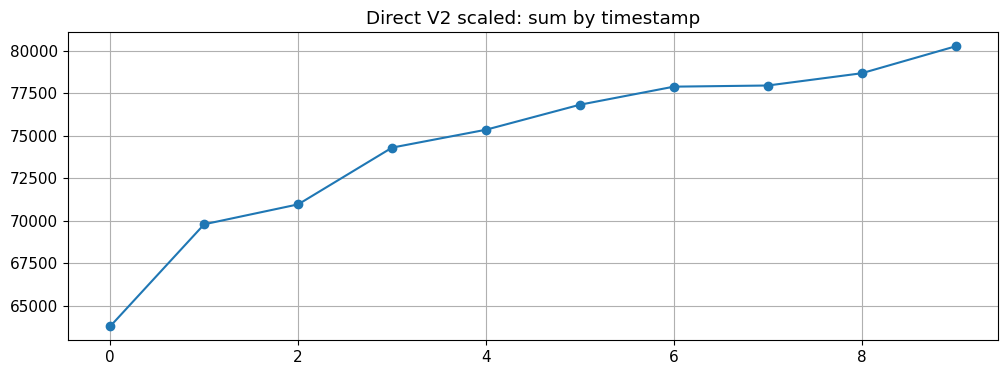


DONE.


In [ ]:
# =========================================================
# DIRECT V2: stronger direct model with richer features
# One-cell notebook script
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import gc
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor

# ---------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------
TRAIN_PATH = "data/train.parquet"
TEST_PATH = "data/test.parquet"

HORIZON = 10
N_FOLDS = 5
FOLD_STEP = 10

# Try a fresher window; easy to change to 14 / 21 / 28
DIRECT_TRAIN_DAYS = 14

DIRECT_V2_PARAMS = dict(
    n_estimators=700,
    learning_rate=0.04,
    num_leaves=63,
    max_depth=8,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.0,
    reg_lambda=1.0,
    min_child_samples=50,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

SCALE_GRID = np.arange(0.90, 1.1001, 0.005)

# ---------------------------------------------------------
# METRIC / UTILS
# ---------------------------------------------------------
def metric_parts(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = y_true.sum()
    wape = np.abs(y_pred - y_true).sum() / denom
    rbias = abs(y_pred.sum() / denom - 1)
    return {
        "metric": wape + rbias,
        "wape": wape,
        "rbias": rbias,
        "true_sum": float(y_true.sum()),
        "pred_sum": float(y_pred.sum()),
    }

def make_backtest_folds(all_timestamps, horizon=10, n_folds=5, step=10):
    folds = []
    n = len(all_timestamps)
    for i in range(n_folds):
        valid_end = n - i * step
        valid_start = valid_end - horizon
        if valid_start <= 0:
            break
        train_ts = all_timestamps[:valid_start]
        valid_ts = all_timestamps[valid_start:valid_end]
        folds.append((train_ts, valid_ts))
    return folds[::-1]

def add_time_features(df):
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["hour"] = df["timestamp"].dt.hour.astype(np.int16)
    df["minute"] = df["timestamp"].dt.minute.astype(np.int16)
    df["dayofweek"] = df["timestamp"].dt.dayofweek.astype(np.int16)
    df["month"] = df["timestamp"].dt.month.astype(np.int16)
    df["dayofmonth"] = df["timestamp"].dt.day.astype(np.int16)
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(np.int8)
    df["tod_step"] = (df["hour"] * 2 + (df["minute"] // 30)).astype(np.int16)

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24.0)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24.0)
    df["tod_sin"] = np.sin(2 * np.pi * df["tod_step"] / 48.0)
    df["tod_cos"] = np.cos(2 * np.pi * df["tod_step"] / 48.0)
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7.0)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7.0)
    return df

def unique_preserve_order(seq):
    return list(dict.fromkeys(seq))

# ---------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------
train = pd.read_parquet(TRAIN_PATH)
test = pd.read_parquet(TEST_PATH)

train["timestamp"] = pd.to_datetime(train["timestamp"])
test["timestamp"] = pd.to_datetime(test["timestamp"])

train = train.sort_values(["route_id", "timestamp"]).reset_index(drop=True)
test = test.sort_values(["route_id", "timestamp"]).reset_index(drop=True)

route_to_office = train.groupby("route_id")["office_from_id"].first().to_dict()
test["office_from_id"] = test["route_id"].map(route_to_office)

status_cols = [c for c in train.columns if c.startswith("status_")]
all_timestamps = sorted(train["timestamp"].unique())
folds = make_backtest_folds(all_timestamps, horizon=HORIZON, n_folds=N_FOLDS, step=FOLD_STEP)

print("train shape:", train.shape)
print("test shape :", test.shape)
print("status_cols:", status_cols)
print("\nFolds:")
for i, (tr_ts, va_ts) in enumerate(folds, 1):
    print(i, tr_ts[0], tr_ts[-1], "|", va_ts[0], va_ts[-1], "|", len(va_ts))

# ---------------------------------------------------------
# BUILD DIRECT V2 BASE TABLE
# ---------------------------------------------------------
def build_direct_v2_base(df):
    df = df.copy()
    df = add_time_features(df)

    # basic status features
    df["status_sum"] = df[status_cols].sum(axis=1)
    df["status_max"] = df[status_cols].max(axis=1)
    df["status_nnz"] = (df[status_cols] > 0).sum(axis=1)

    for c in ["status_3", "status_4", "status_5", "status_6", "status_7", "status_8"]:
        if c in df.columns:
            df[f"{c}_share"] = df[c] / (df["status_sum"] + 1.0)

    if {"status_5", "status_6"}.issubset(df.columns):
        df["status_5_div_6"] = df["status_5"] / (df["status_6"] + 1.0)
        df["status_6_div_5"] = df["status_6"] / (df["status_5"] + 1.0)

    if {"status_5", "status_4"}.issubset(df.columns):
        df["status_5_div_4"] = df["status_5"] / (df["status_4"] + 1.0)

    grp_target = df.groupby("route_id")["target_2h"]
    grp = df.groupby("route_id")

    # target lags
    target_lags = [1, 2, 4, 8, 12, 24, 48, 96, 336]
    for lag in target_lags:
        df[f"target_lag_{lag}"] = grp_target.shift(lag)

    # status lags
    status_lags = [1, 2, 4]
    for c in status_cols + ["status_sum", "status_max", "status_nnz"]:
        for lag in status_lags:
            df[f"{c}_lag_{lag}"] = grp[c].shift(lag)

    # EWMA target
    for span in [4, 12, 48]:
        df[f"target_ewm_{span}"] = grp_target.shift(1).ewm(span=span, adjust=False).mean()

    # EWMA statuses
    for c in ["status_sum", "status_5", "status_6"]:
        if c in df.columns:
            for span in [4, 12, 48]:
                df[f"{c}_ewm_{span}"] = grp[c].shift(1).ewm(span=span, adjust=False).mean()

    # rolling stats
    for w in [4, 12, 48]:
        df[f"status_sum_roll_mean_{w}"] = grp["status_sum"].shift(1).rolling(w).mean()
        df[f"status_sum_roll_std_{w}"] = grp["status_sum"].shift(1).rolling(w).std()
        df[f"target_roll_mean_{w}"] = grp["target_2h"].shift(1).rolling(w).mean()
        df[f"target_roll_std_{w}"] = grp["target_2h"].shift(1).rolling(w).std()

    # recent zero count on target
    df["target_is_zero"] = (df["target_2h"] == 0).astype(np.int8)
    for w in [12, 48]:
        df[f"recent_zero_count_{w}"] = grp["target_is_zero"].shift(1).rolling(w).sum()

    # interactions with time
    df["status_sum_x_hour_sin"] = df["status_sum"] * df["hour_sin"]
    df["status_sum_x_tod_sin"] = df["status_sum"] * df["tod_sin"]
    df["status_max_x_tod_cos"] = df["status_max"] * df["tod_cos"]

    # route / office stats
    route_stats = df.groupby("route_id")["target_2h"].agg(
        route_mean="mean",
        route_std="std",
        route_zero_share=lambda x: (x == 0).mean(),
        route_q25=lambda x: x.quantile(0.25),
        route_q50="median",
        route_q75=lambda x: x.quantile(0.75)
    ).reset_index()
    route_stats["route_std"] = route_stats["route_std"].fillna(0.0)

    office_stats = df.groupby("office_from_id")["target_2h"].agg(
        office_mean="mean",
        office_std="std",
        office_zero_share=lambda x: (x == 0).mean()
    ).reset_index()
    office_stats["office_std"] = office_stats["office_std"].fillna(0.0)

    # profiles
    route_tod = df.groupby(["route_id", "tod_step"])["target_2h"].mean().rename("route_tod_mean").reset_index()
    route_dow_tod = df.groupby(["route_id", "dayofweek", "tod_step"])["target_2h"].mean().rename("route_dow_tod_mean").reset_index()
    office_tod = df.groupby(["office_from_id", "tod_step"])["target_2h"].mean().rename("office_tod_mean").reset_index()

    df = df.merge(route_stats, on="route_id", how="left")
    df = df.merge(office_stats, on="office_from_id", how="left")
    df = df.merge(route_tod, on=["route_id", "tod_step"], how="left")
    df = df.merge(route_dow_tod, on=["route_id", "dayofweek", "tod_step"], how="left")
    df = df.merge(office_tod, on=["office_from_id", "tod_step"], how="left")

    # ratio to route mean
    df["status_sum_div_route_mean"] = df["status_sum"] / (df["route_mean"] + 1.0)
    df["status_max_div_route_mean"] = df["status_max"] / (df["route_mean"] + 1.0)

    # direct targets
    for h in range(1, HORIZON + 1):
        df[f"target_step_{h}"] = grp_target.shift(-h)

    return df

direct_v2_base = build_direct_v2_base(train)

DIRECT_V2_FEATURES = [
    "route_id", "office_from_id",
    "hour", "minute", "dayofweek", "month", "dayofmonth", "is_weekend", "tod_step",
    "hour_sin", "hour_cos", "tod_sin", "tod_cos", "dow_sin", "dow_cos",
    "status_sum", "status_max", "status_nnz",
    "status_sum_x_hour_sin", "status_sum_x_tod_sin", "status_max_x_tod_cos",
    "route_mean", "route_std", "route_zero_share", "route_q25", "route_q50", "route_q75",
    "office_mean", "office_std", "office_zero_share",
    "route_tod_mean", "route_dow_tod_mean", "office_tod_mean",
    "status_sum_div_route_mean", "status_max_div_route_mean",
] + status_cols

DIRECT_V2_FEATURES += [c for c in direct_v2_base.columns if c.endswith("_share")]
DIRECT_V2_FEATURES += [c for c in direct_v2_base.columns if "_lag_" in c]
DIRECT_V2_FEATURES += [c for c in direct_v2_base.columns if "_ewm_" in c]
DIRECT_V2_FEATURES += [c for c in direct_v2_base.columns if "_roll_" in c]
DIRECT_V2_FEATURES += [c for c in direct_v2_base.columns if c.startswith("recent_zero_count_")]
DIRECT_V2_FEATURES += [c for c in ["status_5_div_6", "status_6_div_5", "status_5_div_4"] if c in direct_v2_base.columns]

DIRECT_V2_FEATURES = [c for c in DIRECT_V2_FEATURES if c in direct_v2_base.columns]
DIRECT_V2_FEATURES = unique_preserve_order(DIRECT_V2_FEATURES)

print("\nN DIRECT_V2_FEATURES:", len(DIRECT_V2_FEATURES))

# ---------------------------------------------------------
# TRAIN / PREDICT DIRECT V2
# ---------------------------------------------------------
def train_direct_v2_models(valid_start_ts):
    ts_to_pos = {ts: i for i, ts in enumerate(all_timestamps)}
    valid_start_pos = ts_to_pos[valid_start_ts]
    max_train_origin_pos = valid_start_pos - HORIZON - 1

    if max_train_origin_pos < 0:
        raise ValueError("Not enough history for direct model fold.")

    max_train_origin_ts = all_timestamps[max_train_origin_pos]
    min_train_origin_ts = max_train_origin_ts - pd.Timedelta(days=DIRECT_TRAIN_DAYS)

    train_df = direct_v2_base[
        (direct_v2_base["timestamp"] >= min_train_origin_ts) &
        (direct_v2_base["timestamp"] <= max_train_origin_ts)
    ].copy()

    train_df = train_df.dropna(subset=[f"target_step_{h}" for h in range(1, HORIZON + 1)])
    train_df = train_df.dropna(subset=DIRECT_V2_FEATURES)

    models = {}
    for h in range(1, HORIZON + 1):
        model = LGBMRegressor(**DIRECT_V2_PARAMS)
        y = train_df[f"target_step_{h}"].values
        model.fit(train_df[DIRECT_V2_FEATURES], y)
        models[h] = model

    return models

def predict_direct_v2_from_origin(models, origin_df, future_timestamps):
    origin_df = origin_df.copy().sort_values("route_id").reset_index(drop=True)
    X = origin_df[DIRECT_V2_FEATURES].copy()

    preds = []
    for h, ts in enumerate(future_timestamps, start=1):
        pred = models[h].predict(X)
        pred = np.clip(pred, 0, None)

        step_df = origin_df[["route_id"]].copy()
        step_df["timestamp"] = ts
        step_df["horizon"] = h
        step_df["pred_direct_v2"] = pred
        preds.append(step_df)

    return pd.concat(preds, ignore_index=True)

# ---------------------------------------------------------
# OOF EVALUATION
# ---------------------------------------------------------
oof_rows = []
fold_results = []

for fold_id, (tr_ts, va_ts) in enumerate(folds, start=1):
    print(f"\n===== FOLD {fold_id} =====")

    va_df = train[train["timestamp"].isin(va_ts)].copy()
    origin_ts = tr_ts[-1]
    origin_rows = direct_v2_base[direct_v2_base["timestamp"] == origin_ts].copy()

    models = train_direct_v2_models(va_ts[0])
    pred_df = predict_direct_v2_from_origin(models, origin_rows, va_ts)

    horizon_map = {ts: i + 1 for i, ts in enumerate(sorted(va_ts))}
    gt = va_df[["route_id", "timestamp", "target_2h"]].copy()
    gt["horizon"] = gt["timestamp"].map(horizon_map)

    eval_df = gt.merge(pred_df, on=["route_id", "timestamp", "horizon"], how="left")

    raw_score = metric_parts(eval_df["target_2h"], eval_df["pred_direct_v2"])

    best_k = None
    best_scaled_score = None
    for k in SCALE_GRID:
        pred_k = np.clip(eval_df["pred_direct_v2"].values * k, 0, None)
        score_k = metric_parts(eval_df["target_2h"], pred_k)
        if (best_scaled_score is None) or (score_k["metric"] < best_scaled_score["metric"]):
            best_scaled_score = score_k
            best_k = float(k)

    eval_df["pred_direct_v2_scaled"] = np.clip(eval_df["pred_direct_v2"] * best_k, 0, None)
    eval_df["fold"] = fold_id
    oof_rows.append(eval_df)

    fold_results.append({
        "fold": fold_id,
        "raw_metric": raw_score["metric"],
        "raw_wape": raw_score["wape"],
        "raw_rbias": raw_score["rbias"],
        "scaled_metric": best_scaled_score["metric"],
        "scaled_wape": best_scaled_score["wape"],
        "scaled_rbias": best_scaled_score["rbias"],
        "best_k": best_k
    })

    print("RAW   :", raw_score)
    print("SCALED:", best_scaled_score, "| best_k =", best_k)

    del models, pred_df, eval_df
    gc.collect()

oof_direct_v2 = pd.concat(oof_rows, ignore_index=True)
fold_results_df = pd.DataFrame(fold_results)

print("\n===== FOLD RESULTS DIRECT V2 =====")
display(fold_results_df)

oof_raw_score = metric_parts(oof_direct_v2["target_2h"], oof_direct_v2["pred_direct_v2"])
oof_scaled_score = metric_parts(oof_direct_v2["target_2h"], oof_direct_v2["pred_direct_v2_scaled"])

print("\n===== OOF DIRECT V2 =====")
print("RAW   :", oof_raw_score)
print("SCALED:", oof_scaled_score)

FINAL_SCALE = float(fold_results_df["best_k"].median())
print("\nFINAL_SCALE (median best_k):", FINAL_SCALE)

# ---------------------------------------------------------
# TRAIN FINAL DIRECT V2 ON FULL TRAIN
# ---------------------------------------------------------
print("\nTraining final direct v2 models on full train...")

full_train_df = direct_v2_base.dropna(subset=[f"target_step_{h}" for h in range(1, HORIZON + 1)]).copy()
full_train_df = full_train_df.dropna(subset=DIRECT_V2_FEATURES)

final_models = {}
for h in range(1, HORIZON + 1):
    model = LGBMRegressor(**DIRECT_V2_PARAMS)
    y = full_train_df[f"target_step_{h}"].values
    model.fit(full_train_df[DIRECT_V2_FEATURES], y)
    final_models[h] = model

print("Final direct v2 models trained.")

# ---------------------------------------------------------
# TEST PREDICTION
# ---------------------------------------------------------
final_origin_ts = train["timestamp"].max()
final_origin_rows = direct_v2_base[direct_v2_base["timestamp"] == final_origin_ts].copy()
test_timestamps = sorted(test["timestamp"].unique())

test_pred = predict_direct_v2_from_origin(final_models, final_origin_rows, test_timestamps)

submission = test[["id", "route_id", "timestamp"]].copy()
submission["horizon"] = submission.groupby("route_id").cumcount() + 1
submission = submission.merge(
    test_pred[["route_id", "timestamp", "horizon", "pred_direct_v2"]],
    on=["route_id", "timestamp", "horizon"],
    how="left"
)

submission_raw = submission[["id", "pred_direct_v2"]].rename(columns={"pred_direct_v2": "y_pred"}).sort_values("id").reset_index(drop=True)
submission_scaled = submission_raw.copy()
submission_scaled["y_pred"] = np.clip(submission_scaled["y_pred"] * FINAL_SCALE, 0, None)

submission_raw.to_csv("submission_direct_v2.csv", index=False)
submission_scaled.to_csv("submission_direct_v2_scaled.csv", index=False)

print("\nsaved: submission_direct_v2.csv")
print("saved: submission_direct_v2_scaled.csv")

print("\nSubmission RAW describe:")
print(submission_raw["y_pred"].describe())

print("\nSubmission SCALED describe:")
print(submission_scaled["y_pred"].describe())

# ---------------------------------------------------------
# OPTIONAL: SIMPLE BLENDS WITH READY CHRONOS / STACK
# ---------------------------------------------------------
if os.path.exists("submission_chronos2_component.csv"):
    sub_ch = pd.read_csv("submission_chronos2_component.csv").sort_values("id").reset_index(drop=True)
    for w in [0.9, 0.8, 0.7]:
        blend = submission_scaled.copy()
        blend["y_pred"] = w * submission_scaled["y_pred"].values + (1 - w) * sub_ch["y_pred"].values
        fname = f"submission_direct_v2_chronos_{int(w*100)}_{int((1-w)*100)}.csv"
        blend.to_csv(fname, index=False)
        print("saved:", fname)

if os.path.exists("submission_stack_blend_with_direct.csv"):
    sub_stack = pd.read_csv("submission_stack_blend_with_direct.csv").sort_values("id").reset_index(drop=True)
    for w in [0.9, 0.8, 0.7]:
        blend = submission_scaled.copy()
        blend["y_pred"] = w * submission_scaled["y_pred"].values + (1 - w) * sub_stack["y_pred"].values
        fname = f"submission_direct_v2_stack_{int(w*100)}_{int((1-w)*100)}.csv"
        blend.to_csv(fname, index=False)
        print("saved:", fname)

# ---------------------------------------------------------
# PLOTS
# ---------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(
    test.merge(submission_scaled, on="id", how="left")
        .groupby("timestamp", as_index=False)["y_pred"].sum()["y_pred"].values,
    marker="o"
)
plt.title("Direct V2 scaled: sum by timestamp")
plt.show()

print("\nDONE.")

In [11]:
import os
import gc
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# =========================
# OPTIONAL IMPORTS
# =========================
try:
    import optuna
except ImportError:
    raise ImportError("Установи optuna: pip install optuna")

try:
    from lightgbm import LGBMRegressor, early_stopping, log_evaluation
except ImportError:
    raise ImportError("Установи lightgbm: pip install lightgbm")


# =========================================================
# CONFIG
# =========================================================

TRAIN_PATH = "data/train.parquet"
TEST_PATH  = "data/test.parquet"

ART_DIR = Path("artifacts_optuna_pipeline")
MODEL_DIR = ART_DIR / "models"
PRED_DIR = ART_DIR / "preds"
META_DIR = ART_DIR / "meta"

for d in [ART_DIR, MODEL_DIR, PRED_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TARGET = "target_2h"
ROUTE_COL = "route_id"
OFFICE_COL = "office_from_id"
TIME_COL = "timestamp"
ID_COL = "id"
STATUS_COLS = [f"status_{i}" for i in range(1, 9)]

HORIZON = 10
TRAIN_WINDOW_DAYS = 56
RECENT_MILD_DAYS = 28
RECENT_STRONG_DAYS = 14
N_VALID_FRIDAY_ORIGINS = 4

TARGET_LAGS = [1, 2, 3, 4, 6, 8, 12, 24, 48]
STATUS_LAGS = [1, 2, 4, 8, 24, 48]
ROLL_WINDOWS = [4, 8, 12, 24, 48]

N_TRIALS_OPTUNA = 200
RANDOM_SEED = 42

BASE_MODELS = ["lgb_full", "lgb_small", "ridge"]

LGB_FULL_PARAMS = dict(
    n_estimators=400,
    learning_rate=0.04,
    num_leaves=63,
    max_depth=8,
    min_child_samples=100,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=2.0,
    objective="mae",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=-1,
)

LGB_SMALL_PARAMS = dict(
    n_estimators=250,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=6,
    min_child_samples=140,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=4.0,
    objective="mae",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=-1,
)

RIDGE_ALPHA = 2.0


# =========================================================
# UTILITIES
# =========================================================

def log(msg):
    print(msg, flush=True)

def save_pickle(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)

def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def competition_metric(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denom = np.abs(y_true).sum()
    if denom == 0:
        wape = 0.0
        rbias = 0.0
    else:
        wape = np.abs(y_true - y_pred).sum() / denom
        rbias = (y_pred.sum() - y_true.sum()) / denom

    return {
        "metric": float(wape + abs(rbias)),
        "wape": float(wape),
        "rbias": float(rbias),
        "true_sum": float(y_true.sum()),
        "pred_sum": float(y_pred.sum()),
    }


# =========================================================
# LOAD
# =========================================================

log("=== LOAD DATA ===")
train = pd.read_parquet(TRAIN_PATH)
test = pd.read_parquet(TEST_PATH)

train[TIME_COL] = pd.to_datetime(train[TIME_COL])
test[TIME_COL] = pd.to_datetime(test[TIME_COL])

train = train.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)
test = test.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)

route_to_office = (
    train[[ROUTE_COL, OFFICE_COL]]
    .drop_duplicates(subset=[ROUTE_COL])
    .set_index(ROUTE_COL)[OFFICE_COL]
    .to_dict()
)

if OFFICE_COL not in test.columns:
    test[OFFICE_COL] = test[ROUTE_COL].map(route_to_office)

log(f"train shape: {train.shape}")
log(f"test shape : {test.shape}")


# =========================================================
# TIME FEATURES
# =========================================================

def add_time_features(df):
    df = df.copy()
    df["hour"] = df[TIME_COL].dt.hour
    df["minute"] = df[TIME_COL].dt.minute
    df["hour_float"] = df["hour"] + df["minute"] / 60.0
    df["dow"] = df[TIME_COL].dt.dayofweek
    df["is_friday"] = (df["dow"] == 4).astype(np.int8)

    hour_angle = 2 * np.pi * df["hour_float"] / 24.0
    dow_angle = 2 * np.pi * df["dow"] / 7.0

    df["hour_sin"] = np.sin(hour_angle)
    df["hour_cos"] = np.cos(hour_angle)
    df["dow_sin"] = np.sin(dow_angle)
    df["dow_cos"] = np.cos(dow_angle)

    df["is_morning"] = ((df["hour_float"] >= 6) & (df["hour_float"] < 12)).astype(np.int8)
    df["is_midday"] = ((df["hour_float"] >= 10) & (df["hour_float"] <= 16)).astype(np.int8)
    df["is_evening"] = ((df["hour_float"] >= 17) & (df["hour_float"] < 23)).astype(np.int8)
    return df

train = add_time_features(train)
test = add_time_features(test)

test_hours = sorted(test["hour_float"].drop_duplicates().tolist())

def add_test_hour_flags(df, test_hours):
    df = df.copy()
    df["is_test_hour_band"] = df["hour_float"].isin(test_hours).astype(np.int8)
    df["is_friday_test_hour"] = ((df["is_friday"] == 1) & (df["is_test_hour_band"] == 1)).astype(np.int8)
    return df

train = add_test_hour_flags(train, test_hours)
test = add_test_hour_flags(test, test_hours)

log(f"test unique hours: {test_hours}")
log(f"test timestamps   : {test[TIME_COL].nunique()}")


# =========================================================
# TRAIN WINDOW
# =========================================================

train_end_time = train[TIME_COL].max()
train_start_cut = train_end_time - pd.Timedelta(days=TRAIN_WINDOW_DAYS)
train_win = train[train[TIME_COL] >= train_start_cut].copy().reset_index(drop=True)

log("=== TRAIN WINDOW ===")
log(f"{train_win[TIME_COL].min()} -> {train_win[TIME_COL].max()}")
log(f"train_win shape: {train_win.shape}")


# =========================================================
# PROFILES
# =========================================================

log("=== BUILD PROFILES ===")

route_stats = (
    train_win.groupby(ROUTE_COL)[TARGET]
    .agg(route_target_mean="mean", route_target_median="median", route_target_std="std")
    .reset_index()
)

office_stats = (
    train_win.groupby(OFFICE_COL)[TARGET]
    .agg(office_target_mean="mean", office_target_median="median", office_target_std="std")
    .reset_index()
)

route_hour_stats = (
    train_win.groupby([ROUTE_COL, "hour_float"])[TARGET]
    .agg(route_hour_mean="mean", route_hour_median="median")
    .reset_index()
)

route_friday_hour_stats = (
    train_win[train_win["is_friday"] == 1]
    .groupby([ROUTE_COL, "hour_float"])[TARGET]
    .agg(route_friday_hour_mean="mean", route_friday_hour_median="median")
    .reset_index()
)

office_friday_hour_stats = (
    train_win[train_win["is_friday"] == 1]
    .groupby([OFFICE_COL, "hour_float"])[TARGET]
    .agg(office_friday_hour_mean="mean", office_friday_hour_median="median")
    .reset_index()
)

global_hour_stats = (
    train_win.groupby("hour_float")[TARGET]
    .agg(global_hour_mean="mean", global_hour_median="median")
    .reset_index()
)

global_friday_hour_stats = (
    train_win[train_win["is_friday"] == 1]
    .groupby("hour_float")[TARGET]
    .agg(global_friday_hour_mean="mean", global_friday_hour_median="median")
    .reset_index()
)

status_friday_hour_route = (
    train_win[train_win["is_friday"] == 1]
    .groupby([ROUTE_COL, "hour_float"])[STATUS_COLS]
    .mean()
    .reset_index()
)
status_friday_hour_route = status_friday_hour_route.rename(
    columns={c: f"{c}_route_friday_hour_mean" for c in STATUS_COLS}
)

global_target_mean = float(train_win[TARGET].mean())
global_target_median = float(train_win[TARGET].median())

def merge_profiles(df):
    df = df.copy()
    df = df.merge(route_stats, on=ROUTE_COL, how="left")
    df = df.merge(office_stats, on=OFFICE_COL, how="left")
    df = df.merge(route_hour_stats, on=[ROUTE_COL, "hour_float"], how="left")
    df = df.merge(route_friday_hour_stats, on=[ROUTE_COL, "hour_float"], how="left")
    df = df.merge(office_friday_hour_stats, on=[OFFICE_COL, "hour_float"], how="left")
    df = df.merge(global_hour_stats, on="hour_float", how="left")
    df = df.merge(global_friday_hour_stats, on="hour_float", how="left")
    df = df.merge(status_friday_hour_route, on=[ROUTE_COL, "hour_float"], how="left")

    df["route_target_std"] = df["route_target_std"].fillna(0.0)
    df["office_target_std"] = df["office_target_std"].fillna(0.0)

    df["route_hour_mean"] = df["route_hour_mean"].fillna(df["route_target_mean"])
    df["route_hour_median"] = df["route_hour_median"].fillna(df["route_target_median"])

    df["route_friday_hour_mean"] = df["route_friday_hour_mean"].fillna(df["route_hour_mean"])
    df["route_friday_hour_median"] = df["route_friday_hour_median"].fillna(df["route_hour_median"])

    df["office_friday_hour_mean"] = df["office_friday_hour_mean"].fillna(df["office_target_mean"])
    df["office_friday_hour_median"] = df["office_friday_hour_median"].fillna(df["office_target_median"])

    df["global_hour_mean"] = df["global_hour_mean"].fillna(global_target_mean)
    df["global_hour_median"] = df["global_hour_median"].fillna(global_target_median)

    df["global_friday_hour_mean"] = df["global_friday_hour_mean"].fillna(df["global_hour_mean"])
    df["global_friday_hour_median"] = df["global_friday_hour_median"].fillna(df["global_hour_median"])

    eps = 1e-6
    df["route_friday_hour_vs_route_mean"] = df["route_friday_hour_mean"] / (df["route_target_mean"] + eps)
    df["route_hour_vs_route_mean"] = df["route_hour_mean"] / (df["route_target_mean"] + eps)
    df["office_friday_hour_vs_office_mean"] = df["office_friday_hour_mean"] / (df["office_target_mean"] + eps)
    df["global_friday_hour_vs_route_mean"] = df["global_friday_hour_mean"] / (df["route_target_mean"] + eps)

    for c in STATUS_COLS:
        mcol = f"{c}_route_friday_hour_mean"
        if c in df.columns:
            df[mcol] = df[mcol].fillna(df[c])
        else:
            df[mcol] = df[mcol].fillna(0.0)

    return df


# =========================================================
# HISTORY FEATURES FOR TRAIN
# =========================================================

log("=== BUILD TRAIN FEATURES ===")

train_feat = merge_profiles(train_win)

g = train_feat.groupby(ROUTE_COL, sort=False)

for lag in TARGET_LAGS:
    train_feat[f"target_lag_{lag}"] = g[TARGET].shift(lag)

for w in ROLL_WINDOWS:
    train_feat[f"target_roll_mean_{w}"] = g[TARGET].shift(1).rolling(w).mean().reset_index(level=0, drop=True)
    train_feat[f"target_roll_std_{w}"] = g[TARGET].shift(1).rolling(w).std().reset_index(level=0, drop=True)
    train_feat[f"target_roll_min_{w}"] = g[TARGET].shift(1).rolling(w).min().reset_index(level=0, drop=True)
    train_feat[f"target_roll_max_{w}"] = g[TARGET].shift(1).rolling(w).max().reset_index(level=0, drop=True)

for c in STATUS_COLS:
    for lag in STATUS_LAGS:
        train_feat[f"{c}_lag_{lag}"] = g[c].shift(lag)
    for w in [4, 8, 24, 48]:
        train_feat[f"{c}_roll_mean_{w}"] = g[c].shift(1).rolling(w).mean().reset_index(level=0, drop=True)

train_feat["target_is_zero"] = (train_feat[TARGET] == 0).astype(np.int8)
for w in [8, 24, 48]:
    train_feat[f"target_zero_count_{w}"] = (
        g["target_is_zero"].shift(1).rolling(w).sum().reset_index(level=0, drop=True)
    )

train_feat["target_lag_1_vs_48"] = train_feat["target_lag_1"] - train_feat["target_lag_48"]
train_feat["target_lag_2_vs_48"] = train_feat["target_lag_2"] - train_feat["target_lag_48"]
train_feat["target_lag_1_div_48"] = train_feat["target_lag_1"] / (train_feat["target_lag_48"] + 1e-6)

train_feat["status_sum"] = train_feat[STATUS_COLS].sum(axis=1)
train_feat["status_mean"] = train_feat[STATUS_COLS].mean(axis=1)
train_feat["status_max"] = train_feat[STATUS_COLS].max(axis=1)
train_feat["status_min"] = train_feat[STATUS_COLS].min(axis=1)

for c in STATUS_COLS:
    train_feat[f"{c}_vs_route_friday_profile"] = train_feat[c] - train_feat[f"{c}_route_friday_hour_mean"]

for h in range(1, HORIZON + 1):
    train_feat[f"y_h{h}"] = g[TARGET].shift(-h)

log(f"train_feat shape: {train_feat.shape}")


# =========================================================
# TEST FEATURES FROM LAST SNAPSHOT
# =========================================================

log("=== BUILD TEST FEATURES ===")

snapshot_cols = (
    STATUS_COLS
    + [f"target_lag_{lag}" for lag in TARGET_LAGS]
    + [f"target_roll_mean_{w}" for w in ROLL_WINDOWS]
    + [f"target_roll_std_{w}" for w in ROLL_WINDOWS]
    + [f"target_roll_min_{w}" for w in ROLL_WINDOWS]
    + [f"target_roll_max_{w}" for w in ROLL_WINDOWS]
    + [f"{c}_lag_{lag}" for c in STATUS_COLS for lag in STATUS_LAGS]
    + [f"{c}_roll_mean_{w}" for c in STATUS_COLS for w in [4, 8, 24, 48]]
    + ["target_zero_count_8", "target_zero_count_24", "target_zero_count_48"]
    + ["target_lag_1_vs_48", "target_lag_2_vs_48", "target_lag_1_div_48"]
)

snapshot_cols = [c for c in snapshot_cols if c in train_feat.columns]

last_snapshot = (
    train_feat.sort_values([ROUTE_COL, TIME_COL])
    .groupby(ROUTE_COL, as_index=False)
    .tail(1)
    .copy()
)

snapshot_df = last_snapshot[[ROUTE_COL, OFFICE_COL] + snapshot_cols].copy()

test_feat = test[
    [
        ID_COL, ROUTE_COL, OFFICE_COL, TIME_COL,
        "hour", "minute", "hour_float", "dow", "is_friday",
        "hour_sin", "hour_cos", "dow_sin", "dow_cos",
        "is_morning", "is_midday", "is_evening",
        "is_test_hour_band", "is_friday_test_hour"
    ]
].copy()

test_feat = test_feat.merge(snapshot_df, on=[ROUTE_COL, OFFICE_COL], how="left")
test_feat = test_feat.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)
test_feat["step"] = test_feat.groupby(ROUTE_COL).cumcount() + 1

test_feat = merge_profiles(test_feat)

test_feat["status_sum"] = test_feat[STATUS_COLS].sum(axis=1)
test_feat["status_mean"] = test_feat[STATUS_COLS].mean(axis=1)
test_feat["status_max"] = test_feat[STATUS_COLS].max(axis=1)
test_feat["status_min"] = test_feat[STATUS_COLS].min(axis=1)

for c in STATUS_COLS:
    test_feat[f"{c}_vs_route_friday_profile"] = test_feat[c] - test_feat[f"{c}_route_friday_hour_mean"]

log(f"test_feat shape: {test_feat.shape}")


# =========================================================
# FEATURE SETS
# =========================================================

exclude_cols = {
    TARGET, TIME_COL, ID_COL, "target_is_zero"
}
exclude_cols.update({f"y_h{h}" for h in range(1, HORIZON + 1)})

all_feature_cols = [c for c in train_feat.columns if c not in exclude_cols]
if "step" in all_feature_cols:
    all_feature_cols.remove("step")

small_feature_cols = (
    STATUS_COLS
    + ["hour", "minute", "hour_float", "dow", "is_friday", "is_test_hour_band", "is_friday_test_hour",
       "hour_sin", "hour_cos", "dow_sin", "dow_cos",
       "is_morning", "is_midday", "is_evening",
       "route_target_mean", "route_target_median", "route_target_std",
       "office_target_mean", "office_target_median", "office_target_std",
       "route_hour_mean", "route_friday_hour_mean",
       "office_friday_hour_mean", "global_friday_hour_mean",
       "route_friday_hour_vs_route_mean", "route_hour_vs_route_mean",
       "office_friday_hour_vs_office_mean", "global_friday_hour_vs_route_mean",
       "status_sum", "status_mean", "status_max", "status_min"]
    + [f"{c}_route_friday_hour_mean" for c in STATUS_COLS]
    + [f"{c}_vs_route_friday_profile" for c in STATUS_COLS]
    + ["target_lag_1", "target_lag_2", "target_lag_24", "target_lag_48",
       "target_roll_mean_4", "target_roll_mean_8", "target_roll_mean_24", "target_roll_mean_48",
       "target_lag_1_vs_48", "target_lag_2_vs_48", "target_lag_1_div_48"]
)
small_feature_cols = [c for c in small_feature_cols if c in all_feature_cols]

feature_map = {
    "lgb_full": all_feature_cols,
    "lgb_small": small_feature_cols,
    "ridge": small_feature_cols,
}

log(f"n_features lgb_full : {len(feature_map['lgb_full'])}")
log(f"n_features lgb_small: {len(feature_map['lgb_small'])}")
log(f"n_features ridge    : {len(feature_map['ridge'])}")


# =========================================================
# LOCAL VALIDATION SPLIT
# =========================================================

origin_candidates = (
    train_feat[
        (train_feat["is_friday"] == 1) &
        (train_feat["is_test_hour_band"] == 1)
    ][TIME_COL]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

valid_origins = origin_candidates[-N_VALID_FRIDAY_ORIGINS:] if len(origin_candidates) >= N_VALID_FRIDAY_ORIGINS else origin_candidates
log(f"valid origins: {valid_origins}")

required_targets = [f"y_h{h}" for h in range(1, HORIZON + 1)]
required_basics = [c for c in ["target_lag_1", "target_lag_2", "target_lag_48"] if c in train_feat.columns]

direct_df = train_feat.dropna(subset=required_targets + required_basics).copy().reset_index(drop=True)

if len(valid_origins) > 0:
    is_valid = direct_df[TIME_COL].isin(valid_origins)
else:
    fallback_cut = direct_df[TIME_COL].max() - pd.Timedelta(days=7)
    is_valid = direct_df[TIME_COL] >= fallback_cut

train_df = direct_df[~is_valid].copy().reset_index(drop=True)
valid_df = direct_df[is_valid].copy().reset_index(drop=True)

log(f"direct train_df: {train_df.shape}")
log(f"direct valid_df: {valid_df.shape}")


# =========================================================
# SAMPLE WEIGHTS
# =========================================================

def compute_sample_weights(df, ref_end_time):
    w = np.ones(len(df), dtype=float)
    w *= np.where(df["is_friday"] == 1, 1.40, 1.00)
    w *= np.where(df["is_test_hour_band"] == 1, 1.40, 1.00)
    w *= np.where(df["is_friday_test_hour"] == 1, 1.60, 1.00)

    age_days = (ref_end_time - df[TIME_COL]).dt.total_seconds() / (3600 * 24)
    w *= np.where(age_days <= RECENT_MILD_DAYS, 1.15, 1.00)
    w *= np.where(age_days <= RECENT_STRONG_DAYS, 1.20, 1.00)
    w *= np.where((df["is_friday_test_hour"] == 1) & (age_days <= RECENT_STRONG_DAYS), 1.20, 1.00)
    return w

train_w = compute_sample_weights(train_df, train_win[TIME_COL].max())
valid_w = compute_sample_weights(valid_df, train_win[TIME_COL].max())


# =========================================================
# IMPUTATION
# =========================================================

log("=== IMPUTATION ===")

fill_values = {}
for c in all_feature_cols:
    if c in train_df.columns:
        if pd.api.types.is_numeric_dtype(train_df[c]):
            fill_values[c] = float(train_df[c].median()) if train_df[c].notna().any() else 0.0
        else:
            mode = train_df[c].mode()
            fill_values[c] = mode.iloc[0] if len(mode) > 0 else 0

for c in all_feature_cols:
    if c not in test_feat.columns:
        test_feat[c] = np.nan

for c, v in fill_values.items():
    if c in train_df.columns:
        train_df[c] = train_df[c].fillna(v)
    if c in valid_df.columns:
        valid_df[c] = valid_df[c].fillna(v)
    if c in test_feat.columns:
        test_feat[c] = test_feat[c].fillna(v)

save_pickle(fill_values, META_DIR / "fill_values.pkl")
save_pickle(feature_map, META_DIR / "feature_map.pkl")


# =========================================================
# RIDGE VIA NUMPY
# =========================================================

def fit_ridge_numpy(X, y, alpha=2.0):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    x_mean = X.mean(axis=0)
    x_std = X.std(axis=0)
    x_std = np.where(x_std < 1e-12, 1.0, x_std)

    Xs = (X - x_mean) / x_std
    y_mean = y.mean()
    ys = y - y_mean

    A = Xs.T @ Xs + alpha * np.eye(Xs.shape[1])
    b = Xs.T @ ys
    coef = np.linalg.solve(A, b)
    intercept = y_mean

    return {
        "coef": coef,
        "intercept": intercept,
        "x_mean": x_mean,
        "x_std": x_std,
        "alpha": alpha,
    }

def predict_ridge_numpy(model, X):
    X = np.asarray(X, dtype=float)
    Xs = (X - model["x_mean"]) / model["x_std"]
    pred = Xs @ model["coef"] + model["intercept"]
    return pred


# =========================================================
# TRAIN / LOAD BASE MODELS
# =========================================================

def train_or_load_horizon_model(model_name, horizon, X_tr, y_tr, X_va, y_va, sample_weight):
    model_path = MODEL_DIR / f"{model_name}_h{horizon}.pkl"

    if model_path.exists():
        log(f"  [cache] load {model_name} h={horizon}")
        model = load_pickle(model_path)
        return model

    log(f"  [train] {model_name} h={horizon}")

    if model_name == "lgb_full":
        model = LGBMRegressor(**LGB_FULL_PARAMS)
        model.fit(
            X_tr, y_tr,
            sample_weight=sample_weight,
            eval_set=[(X_va, y_va)],
            eval_metric="l1",
            callbacks=[early_stopping(50, verbose=False), log_evaluation(100)]
        )

    elif model_name == "lgb_small":
        model = LGBMRegressor(**LGB_SMALL_PARAMS)
        model.fit(
            X_tr, y_tr,
            sample_weight=sample_weight,
            eval_set=[(X_va, y_va)],
            eval_metric="l1",
            callbacks=[early_stopping(50, verbose=False), log_evaluation(100)]
        )

    elif model_name == "ridge":
        model = fit_ridge_numpy(X_tr, y_tr, alpha=RIDGE_ALPHA)

    else:
        raise ValueError(model_name)

    save_pickle(model, model_path)
    return model


def predict_model(model_name, model, X):
    if model_name in ["lgb_full", "lgb_small"]:
        pred = model.predict(X)
    elif model_name == "ridge":
        pred = predict_ridge_numpy(model, X)
    else:
        raise ValueError(model_name)
    return np.clip(pred, 0.0, None)


base_oof = valid_df[[ROUTE_COL, TIME_COL]].copy()
base_test = test_feat[[ID_COL, ROUTE_COL, TIME_COL, "step"]].copy()

valid_long_target_parts = []
for h in range(1, HORIZON + 1):
    tmp = valid_df[[ROUTE_COL, TIME_COL, f"y_h{h}"]].copy()
    tmp["step"] = h
    tmp["target"] = tmp[f"y_h{h}"]
    valid_long_target_parts.append(tmp[[ROUTE_COL, TIME_COL, "step", "target"]])

oof_master = pd.concat(valid_long_target_parts, axis=0, ignore_index=True)
oof_master = oof_master.sort_values([ROUTE_COL, TIME_COL, "step"]).reset_index(drop=True)

test_master = test_feat[[ID_COL, ROUTE_COL, TIME_COL, "step"]].copy()

log("=== TRAIN BASE MODELS ===")

for model_name in BASE_MODELS:
    oof_pred_path = PRED_DIR / f"oof_{model_name}.parquet"
    test_pred_path = PRED_DIR / f"test_{model_name}.parquet"

    if oof_pred_path.exists() and test_pred_path.exists():
        log(f"[cache] predictions for {model_name}")
        oof_pred_df = pd.read_parquet(oof_pred_path)
        test_pred_df = pd.read_parquet(test_pred_path)
        oof_master = oof_master.merge(oof_pred_df, on=[ROUTE_COL, TIME_COL, "step"], how="left")
        test_master = test_master.merge(test_pred_df, on=[ID_COL, ROUTE_COL, TIME_COL, "step"], how="left")
        continue

    log(f"\n===== MODEL: {model_name} =====")
    feats = feature_map[model_name]

    X_va = valid_df[feats].values
    X_te = test_feat[feats].values

    oof_preds_mat = np.zeros((len(valid_df), HORIZON), dtype=float)
    test_preds_mat = np.zeros((len(test_feat), HORIZON), dtype=float)

    for h in range(1, HORIZON + 1):
        log(f"========== horizon {h}/10 | {model_name} ==========")
        y_col = f"y_h{h}"

        X_tr = train_df[feats].values
        y_tr = train_df[y_col].values
        y_va = valid_df[y_col].values

        model = train_or_load_horizon_model(
            model_name=model_name,
            horizon=h,
            X_tr=X_tr,
            y_tr=y_tr,
            X_va=X_va,
            y_va=y_va,
            sample_weight=train_w,
        )

        pred_va = predict_model(model_name, model, X_va)
        pred_te = predict_model(model_name, model, X_te)

        oof_preds_mat[:, h - 1] = pred_va
        test_preds_mat[:, h - 1] = pred_te

        m = competition_metric(y_va, pred_va)
        log(f"valid {model_name} h={h}: metric={m['metric']:.6f} wape={m['wape']:.6f} rbias={m['rbias']:.6f}")

        gc.collect()

    oof_parts = []
    for h in range(1, HORIZON + 1):
        tmp = valid_df[[ROUTE_COL, TIME_COL]].copy()
        tmp["step"] = h
        tmp[f"pred_{model_name}"] = oof_preds_mat[:, h - 1]
        oof_parts.append(tmp)

    oof_pred_df = pd.concat(oof_parts, axis=0, ignore_index=True)
    oof_pred_df = oof_pred_df.sort_values([ROUTE_COL, TIME_COL, "step"]).reset_index(drop=True)

    test_pred_df = test_feat[[ID_COL, ROUTE_COL, TIME_COL, "step"]].copy()
    final_test_pred = np.zeros(len(test_pred_df), dtype=float)
    for h in range(1, HORIZON + 1):
        idx = test_pred_df["step"].values == h
        final_test_pred[idx] = test_preds_mat[idx, h - 1]
    test_pred_df[f"pred_{model_name}"] = final_test_pred

    oof_pred_df.to_parquet(oof_pred_path, index=False)
    test_pred_df.to_parquet(test_pred_path, index=False)

    oof_master = oof_master.merge(oof_pred_df, on=[ROUTE_COL, TIME_COL, "step"], how="left")
    test_master = test_master.merge(test_pred_df, on=[ID_COL, ROUTE_COL, TIME_COL, "step"], how="left")

    base_metric = competition_metric(oof_master["target"].values, oof_master[f"pred_{model_name}"].values)
    log(f"OOF {model_name}: {base_metric}")


# =========================================================
# OPTUNA BLEND + GROUP SCALING
# =========================================================

log("\n=== OPTUNA BLEND + GROUP SCALING ===")

pred_cols = [f"pred_{m}" for m in BASE_MODELS]
oof_y = oof_master["target"].values.astype(float)
oof_step = oof_master["step"].values.astype(int)
test_step = test_master["step"].values.astype(int)

oof_pred_matrix = oof_master[pred_cols].values.astype(float)
test_pred_matrix = test_master[pred_cols].values.astype(float)

def compute_blend(pred_matrix, weights):
    weights = np.asarray(weights, dtype=float)
    s = weights.sum()
    if s <= 1e-12:
        weights = np.ones_like(weights) / len(weights)
    else:
        weights = weights / s
    pred = pred_matrix @ weights
    return pred, weights

def apply_group_scales(pred, steps, k_g1, k_g2, k_g3):
    pred = np.asarray(pred, dtype=float).copy()
    g1 = np.isin(steps, [1, 2, 3])
    g2 = np.isin(steps, [4, 5, 6, 7])
    g3 = np.isin(steps, [8, 9, 10])

    pred[g1] *= k_g1
    pred[g2] *= k_g2
    pred[g3] *= k_g3
    return np.clip(pred, 0.0, None)

def objective(trial):
    raw_weights = [trial.suggest_float(f"w_{m}", 0.0, 3.0) for m in BASE_MODELS]
    k_g1 = trial.suggest_float("k_g1", 0.90, 1.10)
    k_g2 = trial.suggest_float("k_g2", 0.90, 1.10)
    k_g3 = trial.suggest_float("k_g3", 0.90, 1.10)

    blend_pred, norm_weights = compute_blend(oof_pred_matrix, raw_weights)
    final_pred = apply_group_scales(blend_pred, oof_step, k_g1, k_g2, k_g3)
    score = competition_metric(oof_y, final_pred)["metric"]

    trial.set_user_attr("norm_weights", norm_weights.tolist())
    return score

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
study.optimize(objective, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)

best_params = study.best_params
best_raw_weights = [best_params[f"w_{m}"] for m in BASE_MODELS]
best_blend_oof, best_norm_weights = compute_blend(oof_pred_matrix, best_raw_weights)
best_blend_test, _ = compute_blend(test_pred_matrix, best_raw_weights)

oof_final = apply_group_scales(
    best_blend_oof,
    oof_step,
    best_params["k_g1"],
    best_params["k_g2"],
    best_params["k_g3"],
)

test_final = apply_group_scales(
    best_blend_test,
    test_step,
    best_params["k_g1"],
    best_params["k_g2"],
    best_params["k_g3"],
)

final_metric = competition_metric(oof_y, oof_final)
log(f"BEST OPTUNA OOF: {final_metric}")
log(f"best params: {best_params}")
log(f"best norm weights: {best_norm_weights}")


# =========================================================
# SAVE FINAL ARTIFACTS
# =========================================================

log("=== SAVE FINAL FILES ===")

oof_master["pred_final_optuna_blend"] = oof_final
test_master["pred_final_optuna_blend"] = test_final

oof_master.to_parquet(PRED_DIR / "oof_master_with_blend.parquet", index=False)
test_master.to_parquet(PRED_DIR / "test_master_with_blend.parquet", index=False)

submission = test_master[[ID_COL, "pred_final_optuna_blend"]].rename(
    columns={"pred_final_optuna_blend": TARGET}
)
submission[TARGET] = submission[TARGET].clip(lower=0.0)
submission = submission.sort_values(ID_COL).reset_index(drop=True)

submission_path = ART_DIR / "submission_optuna_blend_group_scaled.csv"
submission.to_csv(submission_path, index=False)

summary = {
    "base_models": BASE_MODELS,
    "pred_cols": pred_cols,
    "best_params": best_params,
    "best_norm_weights": best_norm_weights.tolist(),
    "oof_metric": final_metric,
    "train_window_days": TRAIN_WINDOW_DAYS,
    "valid_origins": [str(x) for x in valid_origins],
    "test_hours": test_hours,
}

with open(ART_DIR / "summary_optuna_blend_group_scaled.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2, default=str)

log(f"saved submission: {submission_path}")
log("done.")

=== LOAD DATA ===
train shape: (4342000, 12)
test shape : (10000, 4)
test unique hours: [11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5]
test timestamps   : 10
=== TRAIN WINDOW ===
2025-04-04 10:30:00 -> 2025-05-30 10:30:00
train_win shape: (2689000, 26)
=== BUILD PROFILES ===
=== BUILD TRAIN FEATURES ===
train_feat shape: (2689000, 192)
=== BUILD TEST FEATURES ===
test_feat shape: (10000, 182)
n_features lgb_full : 179
n_features lgb_small: 67
n_features ridge    : 67
valid origins: [Timestamp('2025-05-23 14:00:00'), Timestamp('2025-05-23 14:30:00'), Timestamp('2025-05-23 15:00:00'), Timestamp('2025-05-23 15:30:00')]
direct train_df: (2627000, 192)
direct valid_df: (4000, 192)
=== IMPUTATION ===
=== TRAIN BASE MODELS ===

===== MODEL: lgb_full =====
========== horizon 1/10 | lgb_full ==========
  [train] lgb_full h=1
[100]	valid_0's l1: 17.9799
[200]	valid_0's l1: 16.711
[300]	valid_0's l1: 16.2261
[400]	valid_0's l1: 16.0203
valid lgb_full h=1: metric=0.274536 wape=0.1942

[I 2026-04-02 03:28:34,413] A new study created in memory with name: no-name-d6a9bdba-a447-4c73-a5d7-7b0d81234df3


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-04-02 03:28:34,437] Trial 0 finished with value: 0.33622568095426725 and parameters: {'w_lgb_full': 1.1236203565420875, 'w_lgb_small': 2.8521429192297485, 'w_ridge': 2.1959818254342154, 'k_g1': 1.0197316968394075, 'k_g2': 0.9312037280884873, 'k_g3': 0.9311989040672406}. Best is trial 0 with value: 0.33622568095426725.
[I 2026-04-02 03:28:34,442] Trial 1 finished with value: 0.30095273159938274 and parameters: {'w_lgb_full': 0.17425083650459838, 'w_lgb_small': 2.5985284373248057, 'w_ridge': 1.8033450352296265, 'k_g1': 1.0416145155592091, 'k_g2': 0.9041168988591605, 'k_g3': 1.093981970432399}. Best is trial 1 with value: 0.30095273159938274.
[I 2026-04-02 03:28:34,447] Trial 2 finished with value: 0.3293659135451313 and parameters: {'w_lgb_full': 2.497327922401265, 'w_lgb_small': 0.6370173320348285, 'w_ridge': 0.5454749016213019, 'k_g1': 0.9366809019706868, 'k_g2': 0.9608484485919075, 'k_g3': 1.0049512863264476}. Best is trial 1 with value: 0.30095273159938274.
[I 2026-04-02 03:2

In [12]:
import pandas as pd
import numpy as np

CHRONOS_PATH = "archive/last_best.csv"
NEW_PATH = "submission_optuna_blend_group_scaled.csv"

chronos = pd.read_csv(CHRONOS_PATH)
new = pd.read_csv(NEW_PATH)

# унифицируем имя колонки
if "target_2h" in new.columns and "y_pred" not in new.columns:
    new = new.rename(columns={"target_2h": "y_pred"})

if "target_2h" in chronos.columns and "y_pred" not in chronos.columns:
    chronos = chronos.rename(columns={"target_2h": "y_pred"})

# проверка
assert "y_pred" in chronos.columns, "В chronos-файле нет колонки y_pred"
assert "y_pred" in new.columns, "В новом файле нет колонки y_pred"

# если есть id — выровняем по id
if "id" in chronos.columns and "id" in new.columns:
    chronos = chronos.sort_values("id").reset_index(drop=True)
    new = new.sort_values("id").reset_index(drop=True)
    assert chronos["id"].equals(new["id"]), "id не совпадают между файлами"

# набор blend-кандидатов
weights = [0.85, 0.80, 0.75, 0.70, 0.65]

for w in weights:
    out = chronos.copy()
    out["y_pred"] = w * chronos["y_pred"].values + (1.0 - w) * new["y_pred"].values
    out["y_pred"] = np.clip(out["y_pred"], 0.0, None)

    save_path = f"blend_chronos_{int(w*100)}_new_{int((1-w)*100)}.csv"
    out.to_csv(save_path, index=False)
    print("saved:", save_path)

print("done")

saved: blend_chronos_85_new_15.csv
saved: blend_chronos_80_new_19.csv
saved: blend_chronos_75_new_25.csv
saved: blend_chronos_70_new_30.csv
saved: blend_chronos_65_new_35.csv
done


In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

# =========================================================
# PATHS
# =========================================================

TRAIN_PATH = "data/train.parquet"
TEST_PATH = "data/test.parquet"

CHRONOS_SUB_PATH = "archive/last_best.csv"
NEW_SUB_PATH = "submission_optuna_blend_group_scaled.csv"

# new OOF from current pipeline
NEW_OOF_PATH = "artifacts_optuna_pipeline/preds/oof_master_with_blend.parquet"

# optional: if Chronos OOF exists, put path here
CHRONOS_OOF_PATH = "preds/oof_chronos.parquet"

OUT_DIR = Path("friday_validation_experiments")
OUT_DIR.mkdir(exist_ok=True, parents=True)

# =========================================================
# SETTINGS
# =========================================================

TARGET = "target_2h"
ROUTE_COL = "route_id"
TIME_COL = "timestamp"
ID_COL = "id"
SUB_COL = "y_pred"

# сколько последних Friday-like origin timestamps брать
N_LAST_FRIDAY_ORIGINS = 6

# сетка для global blend around chronos-heavy area
GLOBAL_BLEND_GRID = np.arange(0.65, 0.91, 0.01)

# сетка для group-wise blend
GROUP_BLEND_GRID = np.arange(0.65, 0.91, 0.03)

# ручные кандидаты вокруг уже удачного 75/25
MANUAL_GLOBAL_WEIGHTS = [0.78, 0.77, 0.76, 0.75, 0.74, 0.73, 0.72]

MANUAL_GROUP_CONFIGS = [
    # (g1, g2, g3) = weight of Chronos
    (0.70, 0.75, 0.80),
    (0.72, 0.75, 0.78),
    (0.75, 0.75, 0.75),
    (0.78, 0.75, 0.72),
    (0.80, 0.75, 0.70),
]

# =========================================================
# HELPERS
# =========================================================

def metric(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denom = np.abs(y_true).sum()
    wape = np.abs(y_true - y_pred).sum() / denom
    rbias = (y_pred.sum() - y_true.sum()) / denom

    return {
        "metric": float(wape + abs(rbias)),
        "wape": float(wape),
        "rbias": float(rbias),
        "true_sum": float(y_true.sum()),
        "pred_sum": float(y_pred.sum()),
    }

def infer_step_test(df):
    df = df.copy()
    df[TIME_COL] = pd.to_datetime(df[TIME_COL])
    df = df.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)
    df["step"] = df.groupby(ROUTE_COL).cumcount() + 1
    return df

def read_submission(path):
    df = pd.read_csv(path)
    if "target_2h" in df.columns and SUB_COL not in df.columns:
        df = df.rename(columns={"target_2h": SUB_COL})
    assert SUB_COL in df.columns, f"{path}: missing {SUB_COL}"
    return df

def apply_group_blend(pred_ch, pred_new, steps, wg1, wg2, wg3):
    pred = np.zeros(len(steps), dtype=float)

    g1 = np.isin(steps, [1, 2, 3])
    g2 = np.isin(steps, [4, 5, 6, 7])
    g3 = np.isin(steps, [8, 9, 10])

    pred[g1] = wg1 * pred_ch[g1] + (1 - wg1) * pred_new[g1]
    pred[g2] = wg2 * pred_ch[g2] + (1 - wg2) * pred_new[g2]
    pred[g3] = wg3 * pred_ch[g3] + (1 - wg3) * pred_new[g3]

    return np.clip(pred, 0.0, None)

# =========================================================
# PART A: BUILD FRIDAY-LIKE VALIDATION DATASET
# =========================================================

print("=== BUILD FRIDAY-LIKE VALIDATION DATASET ===")

train = pd.read_parquet(TRAIN_PATH)
test = pd.read_parquet(TEST_PATH)

train[TIME_COL] = pd.to_datetime(train[TIME_COL])
test[TIME_COL] = pd.to_datetime(test[TIME_COL])

train = train.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)
test = test.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)

test["hour_float"] = test[TIME_COL].dt.hour + test[TIME_COL].dt.minute / 60.0
test_hours = sorted(test["hour_float"].drop_duplicates().tolist())

train["dow"] = train[TIME_COL].dt.dayofweek
train["hour_float"] = train[TIME_COL].dt.hour + train[TIME_COL].dt.minute / 60.0

# origin timestamps, максимально похожие на test regime
friday_like_origins = (
    train[
        (train["dow"] == 4) &
        (train["hour_float"].isin(test_hours))
    ][TIME_COL]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

friday_like_origins = friday_like_origins[-N_LAST_FRIDAY_ORIGINS:]

print("Selected Friday-like origins:")
for x in friday_like_origins:
    print(" ", x)

# Собираем long validation dataset на 10 шагов вперёд
parts = []
g = train.groupby(ROUTE_COL, sort=False)

for h in range(1, 11):
    tmp = train[[ROUTE_COL, TIME_COL, TARGET]].copy()
    tmp["step"] = h
    tmp["target"] = g[TARGET].shift(-h)
    parts.append(tmp[[ROUTE_COL, TIME_COL, "step", "target"]])

friday_valid = pd.concat(parts, axis=0, ignore_index=True)
friday_valid = friday_valid[friday_valid[TIME_COL].isin(friday_like_origins)].copy()
friday_valid = friday_valid.dropna(subset=["target"]).reset_index(drop=True)

friday_valid.to_parquet(OUT_DIR / "friday_like_validation_dataset.parquet", index=False)

print("\nFriday-like validation dataset saved:")
print(OUT_DIR / "friday_like_validation_dataset.parquet")
print("shape:", friday_valid.shape)
print(friday_valid.head())

# =========================================================
# PART B: USE NEW OOF ON FRIDAY-LIKE SUBSET
# =========================================================

print("\n=== EVALUATE NEW OOF ON FRIDAY-LIKE SUBSET ===")

new_oof = pd.read_parquet(NEW_OOF_PATH)
new_oof[TIME_COL] = pd.to_datetime(new_oof[TIME_COL])

# найдем колонку предсказания
new_pred_candidates = [c for c in new_oof.columns if "pred" in c.lower()]
print("new_oof pred candidates:", new_pred_candidates)

if "pred_final_optuna_blend" in new_oof.columns:
    new_pred_col = "pred_final_optuna_blend"
elif "pred" in new_oof.columns:
    new_pred_col = "pred"
else:
    # fallback
    new_pred_col = new_pred_candidates[-1]

if "target" not in new_oof.columns and "target_2h" in new_oof.columns:
    new_oof = new_oof.rename(columns={"target_2h": "target"})

new_oof_sub = new_oof[
    new_oof[TIME_COL].isin(friday_like_origins)
].copy().reset_index(drop=True)

print("new_oof_sub shape:", new_oof_sub.shape)
print("new friday-like metric:", metric(new_oof_sub["target"], new_oof_sub[new_pred_col]))

# =========================================================
# PART C: IF CHRONOS OOF EXISTS -> HONEST BLEND TUNING
# =========================================================

chronos_oof_exists = Path(CHRONOS_OOF_PATH).exists()
print("\nChronos OOF exists:", chronos_oof_exists)

if chronos_oof_exists:
    print("\n=== HONEST FRIDAY-LIKE BLEND TUNING ===")

    chronos_oof = pd.read_parquet(CHRONOS_OOF_PATH) if CHRONOS_OOF_PATH.endswith(".parquet") else pd.read_csv(CHRONOS_OOF_PATH)
    chronos_oof[TIME_COL] = pd.to_datetime(chronos_oof[TIME_COL])

    if "target" not in chronos_oof.columns and "target_2h" in chronos_oof.columns:
        chronos_oof = chronos_oof.rename(columns={"target_2h": "target"})

    ch_pred_candidates = [c for c in chronos_oof.columns if "pred" in c.lower() or c == "y_pred"]
    if "pred" in chronos_oof.columns:
        ch_pred_col = "pred"
    elif "y_pred" in chronos_oof.columns:
        ch_pred_col = "y_pred"
    else:
        ch_pred_col = ch_pred_candidates[-1]

    chronos_oof_sub = chronos_oof[chronos_oof[TIME_COL].isin(friday_like_origins)].copy()

    # merge
    blend_oof = chronos_oof_sub.merge(
        new_oof_sub[[ROUTE_COL, TIME_COL, "step", new_pred_col]],
        on=[ROUTE_COL, TIME_COL, "step"],
        how="inner",
        suffixes=("_chronos", "_new")
    ).copy()

    blend_oof = blend_oof.rename(columns={
        ch_pred_col: "pred_chronos",
        new_pred_col: "pred_new"
    })

    print("blend_oof shape:", blend_oof.shape)
    print("chronos friday-like:", metric(blend_oof["target"], blend_oof["pred_chronos"]))
    print("new friday-like    :", metric(blend_oof["target"], blend_oof["pred_new"]))

    # ---- global search
    best_w = None
    best_score = 1e18

    for w in GLOBAL_BLEND_GRID:
        pred = w * blend_oof["pred_chronos"].values + (1 - w) * blend_oof["pred_new"].values
        score = metric(blend_oof["target"].values, pred)["metric"]
        if score < best_score:
            best_score = score
            best_w = w

    print("\nBest global Friday-like blend:")
    print("chronos weight =", best_w)
    print("new weight     =", 1 - best_w)
    print("score          =", best_score)

    # ---- group-wise search
    best_tuple = None
    best_group_score = 1e18

    y_true = blend_oof["target"].values
    pred_ch = blend_oof["pred_chronos"].values
    pred_new = blend_oof["pred_new"].values
    steps = blend_oof["step"].values

    for wg1 in GROUP_BLEND_GRID:
        for wg2 in GROUP_BLEND_GRID:
            for wg3 in GROUP_BLEND_GRID:
                pred = apply_group_blend(pred_ch, pred_new, steps, wg1, wg2, wg3)
                score = metric(y_true, pred)["metric"]
                if score < best_group_score:
                    best_group_score = score
                    best_tuple = (wg1, wg2, wg3)

    print("\nBest group-wise Friday-like blend:")
    print("g1 1-3  =", best_tuple[0], "/", 1 - best_tuple[0])
    print("g2 4-7  =", best_tuple[1], "/", 1 - best_tuple[1])
    print("g3 8-10 =", best_tuple[2], "/", 1 - best_tuple[2])
    print("score   =", best_group_score)

else:
    print("\nNo Chronos OOF found.")
    print("Will generate only manual candidates based on submissions.")

# =========================================================
# PART D: GENERATE TEST SUBMISSION CANDIDATES
# =========================================================

print("\n=== GENERATE TEST SUBMISSION CANDIDATES ===")

sub_ch = read_submission(CHRONOS_SUB_PATH)
sub_new = read_submission(NEW_SUB_PATH)

if "id" in sub_ch.columns and "id" in sub_new.columns:
    sub_ch = sub_ch.sort_values("id").reset_index(drop=True)
    sub_new = sub_new.sort_values("id").reset_index(drop=True)
    assert sub_ch["id"].equals(sub_new["id"]), "id mismatch between submissions"

test_for_step = infer_step_test(test)
if "id" in test_for_step.columns and "id" in sub_ch.columns:
    test_for_step = test_for_step.sort_values("id").reset_index(drop=True)
    assert test_for_step["id"].equals(sub_ch["id"]), "test id mismatch with submission id"

# 1) Manual global blends around good 75/25
for w in MANUAL_GLOBAL_WEIGHTS:
    out = sub_ch.copy()
    out[SUB_COL] = w * sub_ch[SUB_COL].values + (1 - w) * sub_new[SUB_COL].values
    out[SUB_COL] = np.clip(out[SUB_COL], 0.0, None)

    fname = f"blend_manual_global_{int(round(w*100))}_{int(round((1-w)*100))}.csv"
    out.to_csv(OUT_DIR / fname, index=False)
    print("saved:", OUT_DIR / fname)

# 2) Manual group-wise blends
for i, (wg1, wg2, wg3) in enumerate(MANUAL_GROUP_CONFIGS, 1):
    out = sub_ch.copy()
    out["step"] = test_for_step["step"].values

    pred = apply_group_blend(
        pred_ch=sub_ch[SUB_COL].values,
        pred_new=sub_new[SUB_COL].values,
        steps=out["step"].values,
        wg1=wg1,
        wg2=wg2,
        wg3=wg3
    )

    out[SUB_COL] = pred
    out = out.drop(columns=["step"])

    fname = f"blend_manual_group_{i}_g1_{int(wg1*100)}_g2_{int(wg2*100)}_g3_{int(wg3*100)}.csv"
    out.to_csv(OUT_DIR / fname, index=False)
    print("saved:", OUT_DIR / fname)

# 3) If honest tuned weights found, save them too
if chronos_oof_exists:
    # best global
    out = sub_ch.copy()
    out[SUB_COL] = best_w * sub_ch[SUB_COL].values + (1 - best_w) * sub_new[SUB_COL].values
    out[SUB_COL] = np.clip(out[SUB_COL], 0.0, None)
    out.to_csv(OUT_DIR / "blend_friday_like_best_global.csv", index=False)
    print("saved:", OUT_DIR / "blend_friday_like_best_global.csv")

    # best group
    wg1, wg2, wg3 = best_tuple
    out = sub_ch.copy()
    out["step"] = test_for_step["step"].values
    out[SUB_COL] = apply_group_blend(
        pred_ch=sub_ch[SUB_COL].values,
        pred_new=sub_new[SUB_COL].values,
        steps=out["step"].values,
        wg1=wg1,
        wg2=wg2,
        wg3=wg3
    )
    out = out.drop(columns=["step"])
    out.to_csv(OUT_DIR / "blend_friday_like_best_groupwise.csv", index=False)
    print("saved:", OUT_DIR / "blend_friday_like_best_groupwise.csv")

print("\nDone.")

=== BUILD FRIDAY-LIKE VALIDATION DATASET ===
Selected Friday-like origins:
  2025-05-23 13:00:00
  2025-05-23 13:30:00
  2025-05-23 14:00:00
  2025-05-23 14:30:00
  2025-05-23 15:00:00
  2025-05-23 15:30:00

Friday-like validation dataset saved:
friday_validation_experiments\friday_like_validation_dataset.parquet
shape: (60000, 4)
   route_id           timestamp  step  target
0         0 2025-05-23 13:00:00     1     8.0
1         0 2025-05-23 13:30:00     1    11.0
2         0 2025-05-23 14:00:00     1    11.0
3         0 2025-05-23 14:30:00     1     4.0
4         0 2025-05-23 15:00:00     1     4.0

=== EVALUATE NEW OOF ON FRIDAY-LIKE SUBSET ===
new_oof pred candidates: ['pred_lgb_full', 'pred_lgb_small', 'pred_ridge', 'pred_final_optuna_blend']
new_oof_sub shape: (40000, 8)
new friday-like metric: {'metric': 0.23867118513243543, 'wape': 0.23842075631325416, 'rbias': 0.0002504288191812681, 'true_sum': 3213386.0, 'pred_sum': 3214190.7244615536}

Chronos OOF exists: False

No Chronos 

In [2]:
import pandas as pd
import numpy as np

CHRONOS_PATH = "archive/last_best.csv"
NEW_PATH = "submission_optuna_blend_group_scaled.csv"
OUT_DIR = "final_stepwise_blends"

import os
os.makedirs(OUT_DIR, exist_ok=True)

def load_sub(path):
    df = pd.read_csv(path)
    if "target_2h" in df.columns and "y_pred" not in df.columns:
        df = df.rename(columns={"target_2h": "y_pred"})
    assert "y_pred" in df.columns, f"{path}: no y_pred column"
    return df

chronos = load_sub(CHRONOS_PATH)
new = load_sub(NEW_PATH)

if "id" in chronos.columns and "id" in new.columns:
    chronos = chronos.sort_values("id").reset_index(drop=True)
    new = new.sort_values("id").reset_index(drop=True)
    assert chronos["id"].equals(new["id"]), "id mismatch"

# нужен test для восстановления step
test = pd.read_parquet("data/test.parquet")
test["timestamp"] = pd.to_datetime(test["timestamp"])
test = test.sort_values(["route_id", "timestamp"]).reset_index(drop=True)
test["step"] = test.groupby("route_id").cumcount() + 1

if "id" in test.columns and "id" in chronos.columns:
    test = test.sort_values("id").reset_index(drop=True)
    assert test["id"].equals(chronos["id"]), "test/submission id mismatch"

stepwise_candidates = {
    "smooth_favorite": [0.80, 0.79, 0.78, 0.76, 0.75, 0.74, 0.73, 0.71, 0.70, 0.69],
    "smooth_conservative": [0.81, 0.80, 0.79, 0.77, 0.76, 0.75, 0.74, 0.72, 0.71, 0.70],
    "smooth_aggressive": [0.80, 0.79, 0.78, 0.76, 0.75, 0.73, 0.72, 0.69, 0.68, 0.67],
}

steps = test["step"].values

for name, weights in stepwise_candidates.items():
    out = chronos.copy()
    pred = np.zeros(len(out), dtype=float)

    for s in range(1, 11):
        w = weights[s - 1]  # weight of Chronos
        idx = steps == s
        pred[idx] = w * chronos.loc[idx, "y_pred"].values + (1 - w) * new.loc[idx, "y_pred"].values

    out["y_pred"] = np.clip(pred, 0.0, None)
    save_path = f"{OUT_DIR}/{name}.csv"
    out.to_csv(save_path, index=False)
    print("saved:", save_path, weights)

saved: final_stepwise_blends/smooth_favorite.csv [0.8, 0.79, 0.78, 0.76, 0.75, 0.74, 0.73, 0.71, 0.7, 0.69]
saved: final_stepwise_blends/smooth_conservative.csv [0.81, 0.8, 0.79, 0.77, 0.76, 0.75, 0.74, 0.72, 0.71, 0.7]
saved: final_stepwise_blends/smooth_aggressive.csv [0.8, 0.79, 0.78, 0.76, 0.75, 0.73, 0.72, 0.69, 0.68, 0.67]


In [11]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

# =========================
# PATHS / CONFIG
# =========================
TRAIN_PATH = "data/train.parquet"
TEST_PATH = "data/test.parquet"
OUT_DIR = Path("artifacts_tft_lite")

TARGET = "target_2h"
ROUTE_COL = "route_id"
OFFICE_COL = "office_from_id"
TIME_COL = "timestamp"
ID_COL = "id"
SUB_COL = "y_pred"
STATUS_COLS = [f"status_{i}" for i in range(1, 9)]

LOOKBACK = 48
PRED_LEN = 10

HIDDEN_SIZE = 128
LSTM_LAYERS = 1
ATTN_HEADS = 4
DROPOUT = 0.10
ROUTE_EMB_DIM = 32
OFFICE_EMB_DIM = 8
BATCH_SIZE = 512

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# =========================
# LOAD DATA
# =========================
train = pd.read_parquet(TRAIN_PATH)
test = pd.read_parquet(TEST_PATH)

train[TIME_COL] = pd.to_datetime(train[TIME_COL])
test[TIME_COL] = pd.to_datetime(test[TIME_COL])

train = train.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)
test = test.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)

route_to_office = (
    train[[ROUTE_COL, OFFICE_COL]]
    .drop_duplicates(subset=[ROUTE_COL])
    .set_index(ROUTE_COL)[OFFICE_COL]
    .to_dict()
)

if OFFICE_COL not in test.columns:
    test[OFFICE_COL] = test[ROUTE_COL].map(route_to_office)
else:
    test[OFFICE_COL] = test[OFFICE_COL].fillna(test[ROUTE_COL].map(route_to_office))

for c in STATUS_COLS:
    if c not in test.columns:
        test[c] = np.nan

# =========================
# TIME FEATURES
# =========================
def add_time_features(df):
    df = df.copy()
    df["hour"] = df[TIME_COL].dt.hour
    df["minute"] = df[TIME_COL].dt.minute
    df["hour_float"] = df["hour"] + df["minute"] / 60.0
    df["dow"] = df[TIME_COL].dt.dayofweek

    hour_angle = 2 * np.pi * df["hour_float"] / 24.0
    dow_angle = 2 * np.pi * df["dow"] / 7.0

    df["hour_sin"] = np.sin(hour_angle)
    df["hour_cos"] = np.cos(hour_angle)
    df["dow_sin"] = np.sin(dow_angle)
    df["dow_cos"] = np.cos(dow_angle)
    return df

train = add_time_features(train)
test = add_time_features(test)

# =========================
# SAME TRAIN WINDOW AS TRAINING
# =========================
TRAIN_WINDOW_DAYS = 21
train_end = train[TIME_COL].max()
train_start_cut = train_end - pd.Timedelta(days=TRAIN_WINDOW_DAYS)
train_win = train[train[TIME_COL] >= train_start_cut].copy().reset_index(drop=True)

# =========================
# ENCODINGS
# =========================
all_routes = sorted(train_win[ROUTE_COL].unique().tolist())
all_offices = sorted(train_win[OFFICE_COL].unique().tolist())

route2idx = {r: i for i, r in enumerate(all_routes)}
office2idx = {o: i for i, o in enumerate(all_offices)}

train_win["route_idx"] = train_win[ROUTE_COL].map(route2idx).astype(int)
train_win["office_idx"] = train_win[OFFICE_COL].map(office2idx).astype(int)

test["route_idx"] = test[ROUTE_COL].map(route2idx).astype(int)
test["office_idx"] = test[OFFICE_COL].map(office2idx).astype(int)

# =========================
# NORMALIZATION
# =========================
target_mean = float(train_win[TARGET].mean())
target_std = float(train_win[TARGET].std())
if target_std < 1e-8:
    target_std = 1.0

status_means = train_win[STATUS_COLS].mean().to_dict()
status_stds = train_win[STATUS_COLS].std().replace(0, 1.0).to_dict()

def normalize_target(x):
    return (x - target_mean) / target_std

def denormalize_target(x):
    return x * target_std + target_mean

def normalize_status(df):
    df = df.copy()
    for c in STATUS_COLS:
        if c not in df.columns:
            df[c] = np.nan
        std = status_stds[c] if status_stds[c] > 1e-8 else 1.0
        df[c] = (df[c] - status_means[c]) / std
    return df

train_win = normalize_status(train_win)
test = normalize_status(test)

for c in STATUS_COLS:
    test[c] = test[c].fillna(0.0)

train_win["target_norm"] = normalize_target(train_win[TARGET])

past_cols = ["target_norm"] + STATUS_COLS + ["hour_sin", "hour_cos", "dow_sin", "dow_cos"]
future_known_cols = ["hour_sin", "hour_cos", "dow_sin", "dow_cos"]

# =========================
# MODEL
# =========================
class TFTLite(torch.nn.Module):
    def __init__(
        self,
        n_routes,
        n_offices,
        past_dim,
        future_dim,
        hidden_size=128,
        route_emb_dim=32,
        office_emb_dim=8,
        attn_heads=4,
        dropout=0.1,
        pred_len=10,
        lstm_layers=1,
    ):
        super().__init__()

        self.route_emb = torch.nn.Embedding(n_routes, route_emb_dim)
        self.office_emb = torch.nn.Embedding(n_offices, office_emb_dim)
        static_dim = route_emb_dim + office_emb_dim

        self.past_proj = torch.nn.Linear(past_dim, hidden_size)
        self.future_proj = torch.nn.Linear(future_dim, hidden_size)
        self.static_proj = torch.nn.Linear(static_dim, hidden_size)

        self.encoder = torch.nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )

        self.attn = torch.nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=attn_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.dropout = torch.nn.Dropout(dropout)
        self.norm1 = torch.nn.LayerNorm(hidden_size)
        self.norm2 = torch.nn.LayerNorm(hidden_size)

        self.head = torch.nn.Sequential(
            torch.nn.Linear(hidden_size * 3, hidden_size),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_size, hidden_size // 2),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_size // 2, 1),
        )

    def forward(self, past_x, future_x, static_route, static_office):
        route_e = self.route_emb(static_route)
        office_e = self.office_emb(static_office)
        static_e = torch.cat([route_e, office_e], dim=-1)
        static_h = self.static_proj(static_e)

        past_h = self.past_proj(past_x)
        enc_out, _ = self.encoder(past_h)

        fut_h = self.future_proj(future_x)
        static_expand = static_h.unsqueeze(1).expand(-1, fut_h.size(1), -1)
        queries = self.norm1(fut_h + static_expand)

        attn_out, _ = self.attn(query=queries, key=enc_out, value=enc_out)
        attn_out = self.norm2(attn_out + queries)

        head_in = torch.cat([queries, attn_out, static_expand], dim=-1)
        out = self.head(self.dropout(head_in)).squeeze(-1)
        return out

model = TFTLite(
    n_routes=len(route2idx),
    n_offices=len(office2idx),
    past_dim=len(past_cols),
    future_dim=len(future_known_cols),
    hidden_size=HIDDEN_SIZE,
    route_emb_dim=ROUTE_EMB_DIM,
    office_emb_dim=OFFICE_EMB_DIM,
    attn_heads=ATTN_HEADS,
    dropout=DROPOUT,
    pred_len=PRED_LEN,
    lstm_layers=LSTM_LAYERS,
).to(DEVICE)

best_path = OUT_DIR / "best_tft_lite.pt"
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()
print("Loaded:", best_path)

# =========================
# TEST DATASET
# =========================
train_win_sorted = train_win.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)
test = test.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)
test["step"] = test.groupby(ROUTE_COL).cumcount() + 1

class TFTLiteTestDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return {
            "past_x": torch.tensor(s["past_x"], dtype=torch.float32),
            "future_x": torch.tensor(s["future_x"], dtype=torch.float32),
            "static_route": torch.tensor(s["static_route"], dtype=torch.long),
            "static_office": torch.tensor(s["static_office"], dtype=torch.long),
            "route_id": int(s["route_id"]),
        }

test_samples = []
for rid, gtest in test.groupby(ROUTE_COL, sort=False):
    gtrain = train_win_sorted[train_win_sorted[ROUTE_COL] == rid].sort_values(TIME_COL).reset_index(drop=True)
    if len(gtrain) < LOOKBACK:
        continue

    past_x = gtrain[past_cols].tail(LOOKBACK).values.astype(np.float32)
    future_x = gtest.sort_values(TIME_COL)[future_known_cols].values.astype(np.float32)

    test_samples.append({
        "past_x": past_x,
        "future_x": future_x,
        "static_route": int(gtrain["route_idx"].iloc[-1]),
        "static_office": int(gtrain["office_idx"].iloc[-1]),
        "route_id": int(rid),
    })

test_ds = TFTLiteTestDataset(test_samples)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# =========================
# INFERENCE
# =========================
route_pred_map = {}
with torch.no_grad():
    for batch in test_loader:
        past_x = batch["past_x"].to(DEVICE)
        future_x = batch["future_x"].to(DEVICE)
        static_route = batch["static_route"].to(DEVICE)
        static_office = batch["static_office"].to(DEVICE)

        pred = model(past_x, future_x, static_route, static_office).cpu().numpy()
        pred = denormalize_target(pred)
        pred = np.clip(pred, 0.0, None)

        route_ids = batch["route_id"]
        for i, rid in enumerate(route_ids):
            if torch.is_tensor(rid):
                rid = int(rid.item())
            else:
                rid = int(rid)
            route_pred_map[rid] = pred[i]

print("Predicted routes:", len(route_pred_map))

# =========================
# SAVE SUBMISSION
# =========================
sub_tft = test[[ID_COL, ROUTE_COL, TIME_COL, "step"]].copy()

rows = []
for rid, arr in route_pred_map.items():
    for step, pred in enumerate(arr, start=1):
        rows.append({
            ROUTE_COL: rid,
            "step": step,
            "y_pred": float(pred),
        })

pred_df = pd.DataFrame(rows)

sub_tft = sub_tft.merge(pred_df, on=[ROUTE_COL, "step"], how="left")
print("missing preds:", sub_tft["y_pred"].isna().sum())

sub_tft["y_pred"] = sub_tft["y_pred"].fillna(0.0).clip(lower=0.0)
sub_tft = sub_tft.sort_values(ID_COL).reset_index(drop=True)
sub_tft_final = sub_tft[[ID_COL, "y_pred"]].copy()

save_path = OUT_DIR / "submission_tft_lite.csv"
sub_tft_final.to_csv(save_path, index=False)
print("Saved:", save_path)
print(sub_tft_final.head())

DEVICE: cuda
Loaded: artifacts_tft_lite\best_tft_lite.pt
Predicted routes: 1000
missing preds: 0
Saved: artifacts_tft_lite\submission_tft_lite.csv
   id     y_pred
0   0  61.674492
1   1  61.696796
2   2  52.357857
3   3  36.561619
4   4  36.211891


In [12]:
import numpy as np
import pandas as pd
from pathlib import Path

# =========================================================
# PATHS
# =========================================================

OOF_TFT_PATH = "artifacts_tft_lite/oof_tft_lite.parquet"
SUB_TFT_PATH = "artifacts_tft_lite/submission_tft_lite.csv"

SMOOTH_PATH = "archive/smooth_aggressive.csv"
CHRONOS_PATH = "archive/last_best.csv"
TEST_PATH = "data/test.parquet"

OUT_DIR = Path("artifacts_tft_lite_post")
OUT_DIR.mkdir(exist_ok=True, parents=True)

SUB_COL = "y_pred"
ID_COL = "id"
ROUTE_COL = "route_id"
TIME_COL = "timestamp"

# =========================================================
# METRIC
# =========================================================

def metric(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denom = np.abs(y_true).sum()
    wape = np.abs(y_true - y_pred).sum() / denom
    rbias = (y_pred.sum() - y_true.sum()) / denom

    return {
        "metric": float(wape + abs(rbias)),
        "wape": float(wape),
        "rbias": float(rbias),
        "true_sum": float(y_true.sum()),
        "pred_sum": float(y_pred.sum()),
    }

# =========================================================
# LOAD OOF TFT
# =========================================================

oof = pd.read_parquet(OOF_TFT_PATH)

print("OOF columns:", oof.columns.tolist())

if "target_2h" in oof.columns and "target" not in oof.columns:
    oof = oof.rename(columns={"target_2h": "target"})

assert "target" in oof.columns
assert "pred" in oof.columns

raw_metric = metric(oof["target"].values, oof["pred"].values)
print("\nRAW TFT OOF:", raw_metric)

# =========================================================
# SEARCH BEST SCALE
# =========================================================

grid = np.arange(0.85, 1.21, 0.0025)

best_k = 1.0
best_score = raw_metric["metric"]

for k in grid:
    score = metric(oof["target"].values, oof["pred"].values * k)["metric"]
    if score < best_score:
        best_score = score
        best_k = float(k)

scaled_metric = metric(oof["target"].values, oof["pred"].values * best_k)

print("\nBEST SCALE K:", best_k)
print("SCALED TFT OOF:", scaled_metric)

# =========================================================
# APPLY SCALE TO TFT SUBMISSION
# =========================================================

sub_tft = pd.read_csv(SUB_TFT_PATH)
if "target_2h" in sub_tft.columns and SUB_COL not in sub_tft.columns:
    sub_tft = sub_tft.rename(columns={"target_2h": SUB_COL})
assert SUB_COL in sub_tft.columns

sub_tft_scaled = sub_tft.copy()
sub_tft_scaled[SUB_COL] = np.clip(sub_tft_scaled[SUB_COL].values * best_k, 0.0, None)

scaled_tft_path = OUT_DIR / "submission_tft_lite_scaled.csv"
sub_tft_scaled.to_csv(scaled_tft_path, index=False)
print("\nsaved:", scaled_tft_path)

# =========================================================
# LOAD ANCHORS
# =========================================================

def load_sub(path):
    df = pd.read_csv(path)
    if "target_2h" in df.columns and SUB_COL not in df.columns:
        df = df.rename(columns={"target_2h": SUB_COL})
    assert SUB_COL in df.columns, f"{path}: no {SUB_COL}"
    return df

sub_smooth = load_sub(SMOOTH_PATH)
sub_chronos = load_sub(CHRONOS_PATH)

for df in [sub_smooth, sub_chronos, sub_tft_scaled]:
    if ID_COL in df.columns:
        df.sort_values(ID_COL, inplace=True)
        df.reset_index(drop=True, inplace=True)

assert sub_smooth[ID_COL].equals(sub_tft_scaled[ID_COL])
assert sub_chronos[ID_COL].equals(sub_tft_scaled[ID_COL])

# =========================================================
# SIMPLE GLOBAL BLENDS
# =========================================================

global_blends = {
    "blend_smooth_tft_95_5_scaled.csv": (0.95, 0.05),
    "blend_smooth_tft_90_10_scaled.csv": (0.90, 0.10),
    "blend_smooth_tft_85_15_scaled.csv": (0.85, 0.15),
}

for fname, (ws, wt) in global_blends.items():
    out = sub_smooth.copy()
    out[SUB_COL] = ws * sub_smooth[SUB_COL].values + wt * sub_tft_scaled[SUB_COL].values
    out[SUB_COL] = np.clip(out[SUB_COL], 0.0, None)
    out.to_csv(OUT_DIR / fname, index=False)
    print("saved:", OUT_DIR / fname)

# =========================================================
# STEP-WISE BLENDS
# =========================================================

test = pd.read_parquet(TEST_PATH)
test[TIME_COL] = pd.to_datetime(test[TIME_COL])
test = test.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)
test["step"] = test.groupby(ROUTE_COL).cumcount() + 1

if ID_COL in test.columns:
    test = test.sort_values(ID_COL).reset_index(drop=True)
    assert test[ID_COL].equals(sub_smooth[ID_COL])

steps = test["step"].values

# safest
weights_stepwise_1 = {
    1: 0.97, 2: 0.97, 3: 0.96,
    4: 0.95, 5: 0.94, 6: 0.93, 7: 0.92,
    8: 0.90, 9: 0.88, 10: 0.86,
}

# slightly stronger
weights_stepwise_2 = {
    1: 0.96, 2: 0.96, 3: 0.95,
    4: 0.93, 5: 0.92, 6: 0.91, 7: 0.90,
    8: 0.87, 9: 0.85, 10: 0.82,
}

# aggressive only on far horizons
weights_stepwise_3 = {
    1: 0.98, 2: 0.98, 3: 0.97,
    4: 0.96, 5: 0.95, 6: 0.94, 7: 0.93,
    8: 0.88, 9: 0.84, 10: 0.80,
}

stepwise_candidates = {
    "final_stepwise_safest_scaled.csv": weights_stepwise_1,
    "final_stepwise_medium_scaled.csv": weights_stepwise_2,
    "final_stepwise_far_aggr_scaled.csv": weights_stepwise_3,
}

for fname, wmap in stepwise_candidates.items():
    out = sub_smooth.copy()
    pred = np.zeros(len(out), dtype=float)

    for s in range(1, 11):
        ws = wmap[s]
        idx = steps == s
        pred[idx] = (
            ws * sub_smooth.loc[idx, SUB_COL].values
            + (1.0 - ws) * sub_tft_scaled.loc[idx, SUB_COL].values
        )

    out[SUB_COL] = np.clip(pred, 0.0, None)
    out.to_csv(OUT_DIR / fname, index=False)
    print("saved:", OUT_DIR / fname)

# =========================================================
# OPTIONAL: CHRONOS + TFT
# =========================================================

out = sub_chronos.copy()
out[SUB_COL] = 0.92 * sub_chronos[SUB_COL].values + 0.08 * sub_tft_scaled[SUB_COL].values
out[SUB_COL] = np.clip(out[SUB_COL], 0.0, None)
out.to_csv(OUT_DIR / "blend_chronos_tft_92_8_scaled.csv", index=False)
print("saved:", OUT_DIR / "blend_chronos_tft_92_8_scaled.csv")

print("\nRecommended order:")
print("1) final_stepwise_safest_scaled.csv")
print("2) blend_smooth_tft_95_5_scaled.csv")
print("3) final_stepwise_medium_scaled.csv")

OOF columns: ['route_id', 'timestamp', 'step', 'target', 'pred']

RAW TFT OOF: {'metric': 0.2777270057589501, 'wape': 0.23628019388870036, 'rbias': -0.04144681187024974, 'true_sum': 4819026.999597569, 'pred_sum': 4619293.693941554}

BEST SCALE K: 1.042499999999996
SCALED TFT OOF: {'metric': 0.24121876204738782, 'wape': 0.2405104606288065, 'rbias': -0.0007083014185813374, 'true_sum': 4819026.999597569, 'pred_sum': 4815613.675934051}

saved: artifacts_tft_lite_post\submission_tft_lite_scaled.csv
saved: artifacts_tft_lite_post\blend_smooth_tft_95_5_scaled.csv
saved: artifacts_tft_lite_post\blend_smooth_tft_90_10_scaled.csv
saved: artifacts_tft_lite_post\blend_smooth_tft_85_15_scaled.csv
saved: artifacts_tft_lite_post\final_stepwise_safest_scaled.csv
saved: artifacts_tft_lite_post\final_stepwise_medium_scaled.csv
saved: artifacts_tft_lite_post\final_stepwise_far_aggr_scaled.csv
saved: artifacts_tft_lite_post\blend_chronos_tft_92_8_scaled.csv

Recommended order:
1) final_stepwise_safest_sca

In [1]:
import os
import gc
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import optuna
from catboost import CatBoostRegressor

# =========================================================
# CONFIG
# =========================================================

TRAIN_PATH = "data/train.parquet"
TEST_PATH = "data/test.parquet"

CHRONOS_SUB_PATH = "archive/last_best.csv"
SMOOTH_SUB_PATH = "archive/smooth_aggressive.csv"

OUT_DIR = Path("artifacts_cat_gru")
MODEL_DIR = OUT_DIR / "models"
PRED_DIR = OUT_DIR / "preds"
META_DIR = OUT_DIR / "meta"

for d in [OUT_DIR, MODEL_DIR, PRED_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TARGET = "target_2h"
ROUTE_COL = "route_id"
OFFICE_COL = "office_from_id"
TIME_COL = "timestamp"
ID_COL = "id"
SUB_COL = "y_pred"
STATUS_COLS = [f"status_{i}" for i in range(1, 9)]

HORIZON = 10
TRAIN_WINDOW_DAYS = 56
LOOKBACK = 48
RANDOM_SEED = 42

# recent validation
RECENT_VALID_DAYS = 7

# friday-like validation
N_LAST_FRIDAY_ORIGINS = 6

# Optuna
N_TRIALS_CATBOOST = 40

# GRU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GRU_HIDDEN = 128
GRU_LAYERS = 1
GRU_DROPOUT = 0.10
ROUTE_EMB_DIM = 32
OFFICE_EMB_DIM = 8
GRU_BATCH_SIZE = 512
GRU_LR = 1e-3
GRU_EPOCHS = 18
GRU_PATIENCE = 4
GRU_CLIP = 1.0

# final blend search
BLEND_GRID = np.arange(0.0, 1.01, 0.02)

# =========================================================
# UTILS
# =========================================================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(RANDOM_SEED)

def log(msg):
    print(msg, flush=True)

def metric(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denom = np.abs(y_true).sum()
    wape = np.abs(y_true - y_pred).sum() / denom
    rbias = (y_pred.sum() - y_true.sum()) / denom

    return {
        "metric": float(wape + abs(rbias)),
        "wape": float(wape),
        "rbias": float(rbias),
        "true_sum": float(y_true.sum()),
        "pred_sum": float(y_pred.sum()),
    }

def search_best_scale(y_true, y_pred, low=0.85, high=1.15, step=0.0025):
    best_k = 1.0
    best_score = metric(y_true, y_pred)["metric"]
    for k in np.arange(low, high + 1e-12, step):
        s = metric(y_true, y_pred * k)["metric"]
        if s < best_score:
            best_score = s
            best_k = float(k)
    return best_k, best_score

def read_sub(path):
    df = pd.read_csv(path)
    if "target_2h" in df.columns and SUB_COL not in df.columns:
        df = df.rename(columns={"target_2h": SUB_COL})
    assert SUB_COL in df.columns, f"{path}: missing {SUB_COL}"
    return df

# =========================================================
# LOAD
# =========================================================

log("=== LOAD DATA ===")
train = pd.read_parquet(TRAIN_PATH)
test = pd.read_parquet(TEST_PATH)

train[TIME_COL] = pd.to_datetime(train[TIME_COL])
test[TIME_COL] = pd.to_datetime(test[TIME_COL])

train = train.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)
test = test.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)

route_to_office = (
    train[[ROUTE_COL, OFFICE_COL]]
    .drop_duplicates(subset=[ROUTE_COL])
    .set_index(ROUTE_COL)[OFFICE_COL]
    .to_dict()
)

if OFFICE_COL not in test.columns:
    test[OFFICE_COL] = test[ROUTE_COL].map(route_to_office)
else:
    test[OFFICE_COL] = test[OFFICE_COL].fillna(test[ROUTE_COL].map(route_to_office))

for c in STATUS_COLS:
    if c not in test.columns:
        test[c] = np.nan

log(f"train shape: {train.shape}")
log(f"test shape : {test.shape}")
log(f"DEVICE: {DEVICE}")

# =========================================================
# TIME FEATURES
# =========================================================

def add_time_features(df):
    df = df.copy()
    df["hour"] = df[TIME_COL].dt.hour
    df["minute"] = df[TIME_COL].dt.minute
    df["hour_float"] = df["hour"] + df["minute"] / 60.0
    df["dow"] = df[TIME_COL].dt.dayofweek
    df["is_friday"] = (df["dow"] == 4).astype(np.int8)

    hour_angle = 2 * np.pi * df["hour_float"] / 24.0
    dow_angle = 2 * np.pi * df["dow"] / 7.0
    df["hour_sin"] = np.sin(hour_angle)
    df["hour_cos"] = np.cos(hour_angle)
    df["dow_sin"] = np.sin(dow_angle)
    df["dow_cos"] = np.cos(dow_angle)

    return df

train = add_time_features(train)
test = add_time_features(test)

test_hours = sorted(test["hour_float"].drop_duplicates().tolist())

# =========================================================
# TRAIN WINDOW
# =========================================================

train_end = train[TIME_COL].max()
train_start_cut = train_end - pd.Timedelta(days=TRAIN_WINDOW_DAYS)
train_win = train[train[TIME_COL] >= train_start_cut].copy().reset_index(drop=True)

log("=== TRAIN WINDOW ===")
log(f"{train_win[TIME_COL].min()} -> {train_win[TIME_COL].max()}")
log(f"train_win shape: {train_win.shape}")

# =========================================================
# VALIDATION ORIGINS
# =========================================================

# Friday-like
friday_like_origins = (
    train_win[
        (train_win["dow"] == 4) &
        (train_win["hour_float"].isin(test_hours))
    ][TIME_COL]
    .drop_duplicates()
    .sort_values()
    .tolist()
)
friday_like_origins = friday_like_origins[-N_LAST_FRIDAY_ORIGINS:]

# Recent
recent_cut = train_win[TIME_COL].max() - pd.Timedelta(days=RECENT_VALID_DAYS)
recent_origins = (
    train_win[train_win[TIME_COL] >= recent_cut][TIME_COL]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

log("=== VALID ORIGINS ===")
log(f"friday_like_origins: {len(friday_like_origins)}")
for x in friday_like_origins:
    log(f"  {x}")
log(f"recent_origins: {len(recent_origins)}")

# =========================================================
# STATIC PROFILES FOR CATBOOST
# =========================================================

route_stats = (
    train_win.groupby(ROUTE_COL)[TARGET]
    .agg(route_target_mean="mean", route_target_median="median", route_target_std="std")
    .reset_index()
)

office_stats = (
    train_win.groupby(OFFICE_COL)[TARGET]
    .agg(office_target_mean="mean", office_target_median="median", office_target_std="std")
    .reset_index()
)

route_hour_stats = (
    train_win.groupby([ROUTE_COL, "hour_float"])[TARGET]
    .agg(route_hour_mean="mean", route_hour_median="median")
    .reset_index()
)

route_friday_hour_stats = (
    train_win[train_win["is_friday"] == 1]
    .groupby([ROUTE_COL, "hour_float"])[TARGET]
    .agg(route_friday_hour_mean="mean", route_friday_hour_median="median")
    .reset_index()
)

global_hour_stats = (
    train_win.groupby("hour_float")[TARGET]
    .agg(global_hour_mean="mean", global_hour_median="median")
    .reset_index()
)

def merge_profiles(df):
    df = df.copy()
    df = df.merge(route_stats, on=ROUTE_COL, how="left")
    df = df.merge(office_stats, on=OFFICE_COL, how="left")
    df = df.merge(route_hour_stats, on=[ROUTE_COL, "hour_float"], how="left")
    df = df.merge(route_friday_hour_stats, on=[ROUTE_COL, "hour_float"], how="left")
    df = df.merge(global_hour_stats, on="hour_float", how="left")

    df["route_target_std"] = df["route_target_std"].fillna(0.0)
    df["office_target_std"] = df["office_target_std"].fillna(0.0)

    df["route_hour_mean"] = df["route_hour_mean"].fillna(df["route_target_mean"])
    df["route_hour_median"] = df["route_hour_median"].fillna(df["route_target_median"])

    df["route_friday_hour_mean"] = df["route_friday_hour_mean"].fillna(df["route_hour_mean"])
    df["route_friday_hour_median"] = df["route_friday_hour_median"].fillna(df["route_hour_median"])

    eps = 1e-6
    df["route_friday_hour_vs_route_mean"] = df["route_friday_hour_mean"] / (df["route_target_mean"] + eps)
    df["route_hour_vs_route_mean"] = df["route_hour_mean"] / (df["route_target_mean"] + eps)
    return df

# =========================================================
# CATBOOST FEATURES
# =========================================================

train_cb = merge_profiles(train_win)

g = train_cb.groupby(ROUTE_COL, sort=False)
target_lags = [1, 2, 3, 4, 6, 8, 12, 24, 48]

for lag in target_lags:
    train_cb[f"target_lag_{lag}"] = g[TARGET].shift(lag)

for w in [4, 8, 24, 48]:
    train_cb[f"target_roll_mean_{w}"] = g[TARGET].shift(1).rolling(w).mean().reset_index(level=0, drop=True)
    train_cb[f"target_roll_std_{w}"] = g[TARGET].shift(1).rolling(w).std().reset_index(level=0, drop=True)

for c in STATUS_COLS:
    for lag in [1, 2, 4, 8, 24, 48]:
        train_cb[f"{c}_lag_{lag}"] = g[c].shift(lag)

train_cb["status_sum"] = train_cb[STATUS_COLS].sum(axis=1)
train_cb["status_mean"] = train_cb[STATUS_COLS].mean(axis=1)
train_cb["target_lag_1_vs_48"] = train_cb["target_lag_1"] - train_cb["target_lag_48"]

for h in range(1, HORIZON + 1):
    train_cb[f"y_h{h}"] = g[TARGET].shift(-h)

required_targets = [f"y_h{h}" for h in range(1, HORIZON + 1)]
required_basics = ["target_lag_1", "target_lag_2", "target_lag_48"]

cb_df = train_cb.dropna(subset=required_targets + required_basics).copy().reset_index(drop=True)

cat_feature_cols = [
    c for c in cb_df.columns
    if c not in [TARGET, TIME_COL] + required_targets
]

cat_feature_cols = [c for c in cat_feature_cols if c != ID_COL]

# categorical columns for CatBoost
cat_cols = [ROUTE_COL, OFFICE_COL, "hour", "minute", "dow", "is_friday"]

# build test features from last snapshot
last_snapshot = (
    train_cb.sort_values([ROUTE_COL, TIME_COL])
    .groupby(ROUTE_COL, as_index=False)
    .tail(1)
    .copy()
)

snapshot_cols = [c for c in cat_feature_cols if c not in [
    TIME_COL, "hour", "minute", "hour_float", "dow", "is_friday", "hour_sin", "hour_cos", "dow_sin", "dow_cos"
]]
snapshot_cols = list(dict.fromkeys([ROUTE_COL, OFFICE_COL] + snapshot_cols))
snapshot_df = last_snapshot[snapshot_cols].copy()

test_cb = test[[ID_COL, ROUTE_COL, OFFICE_COL, TIME_COL, "hour", "minute", "hour_float", "dow", "is_friday", "hour_sin", "hour_cos", "dow_sin", "dow_cos"]].copy()
test_cb = test_cb.merge(snapshot_df, on=[ROUTE_COL, OFFICE_COL], how="left", suffixes=("", "_snap"))

# remove duplicated time-dependent profile cols and rebuild
drop_cols = [c for c in [
    "route_target_mean", "route_target_median", "route_target_std",
    "office_target_mean", "office_target_median", "office_target_std",
    "route_hour_mean", "route_hour_median",
    "route_friday_hour_mean", "route_friday_hour_median",
    "global_hour_mean", "global_hour_median",
    "route_friday_hour_vs_route_mean", "route_hour_vs_route_mean"
] if c in test_cb.columns]
test_cb = test_cb.drop(columns=drop_cols, errors="ignore")
test_cb = merge_profiles(test_cb)

for c in STATUS_COLS:
    if c not in test_cb.columns:
        if f"{c}_snap" in test_cb.columns:
            test_cb[c] = test_cb[f"{c}_snap"]
        else:
            test_cb[c] = 0.0

test_cb["status_sum"] = test_cb[STATUS_COLS].sum(axis=1)
test_cb["status_mean"] = test_cb[STATUS_COLS].mean(axis=1)

for c in cat_feature_cols:
    if c not in test_cb.columns:
        test_cb[c] = np.nan

# fill numeric na
fill_values = {}
for c in cat_feature_cols:
    if c in cb_df.columns:
        if pd.api.types.is_numeric_dtype(cb_df[c]):
            fill_values[c] = cb_df[c].median()
        else:
            fill_values[c] = cb_df[c].mode().iloc[0] if cb_df[c].notna().any() else 0

for c, v in fill_values.items():
    cb_df[c] = cb_df[c].fillna(v)
    if c in test_cb.columns:
        test_cb[c] = test_cb[c].fillna(v)

test_cb = test_cb.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)
test_cb["step"] = test_cb.groupby(ROUTE_COL).cumcount() + 1

# validation masks
is_friday_valid = cb_df[TIME_COL].isin(friday_like_origins)
is_recent_valid = cb_df[TIME_COL].isin(recent_origins)

cb_train_friday = cb_df[~is_friday_valid].copy().reset_index(drop=True)
cb_valid_friday = cb_df[is_friday_valid].copy().reset_index(drop=True)

cb_train_recent = cb_df[~is_recent_valid].copy().reset_index(drop=True)
cb_valid_recent = cb_df[is_recent_valid].copy().reset_index(drop=True)

# =========================================================
# CATBOOST OPTUNA
# =========================================================

log("=== CATBOOST OPTUNA ===")

def catboost_objective(trial):
    params = {
        "loss_function": "MAE",
        "eval_metric": "MAE",
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.12, log=True),
        "depth": trial.suggest_int("depth", 5, 9),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 20, 120),
        "iterations": trial.suggest_int("iterations", 250, 700),
        "verbose": False,
        "random_seed": RANDOM_SEED,
        "task_type": "GPU" if DEVICE == "cuda" else "CPU",
    }

    # optimize on average of horizon 1/5/10 using recent-valid
    scores = []
    for h in [1, 5, 10]:
        y_col = f"y_h{h}"

        model = CatBoostRegressor(**params)
        model.fit(
            cb_train_recent[cat_feature_cols],
            cb_train_recent[y_col],
            cat_features=[cb_train_recent[cat_feature_cols].columns.get_loc(c) for c in cat_cols if c in cat_feature_cols],
            eval_set=(cb_valid_recent[cat_feature_cols], cb_valid_recent[y_col]),
            use_best_model=True,
        )

        pred = model.predict(cb_valid_recent[cat_feature_cols])
        scores.append(metric(cb_valid_recent[y_col].values, pred)["metric"])

    return float(np.mean(scores))

study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study.optimize(catboost_objective, n_trials=N_TRIALS_CATBOOST, show_progress_bar=True)

best_cb_params = study.best_params
log(f"best cat params: {best_cb_params}")

cat_params = {
    "loss_function": "MAE",
    "eval_metric": "MAE",
    "learning_rate": best_cb_params["learning_rate"],
    "depth": best_cb_params["depth"],
    "l2_leaf_reg": best_cb_params["l2_leaf_reg"],
    "random_strength": best_cb_params["random_strength"],
    "bagging_temperature": best_cb_params["bagging_temperature"],
    "min_data_in_leaf": best_cb_params["min_data_in_leaf"],
    "iterations": best_cb_params["iterations"],
    "verbose": 100,
    "random_seed": RANDOM_SEED,
    "task_type": "GPU" if DEVICE == "cuda" else "CPU",
}

with open(META_DIR / "best_catboost_params.json", "w", encoding="utf-8") as f:
    json.dump(best_cb_params, f, ensure_ascii=False, indent=2)

# =========================================================
# TRAIN FINAL CATBOOST
# =========================================================

def train_catboost_set(train_part, valid_part, label="recent"):
    log(f"=== TRAIN CATBOOST on {label} validation setup ===")

    oof_parts = []
    test_preds = np.zeros((len(test_cb), HORIZON), dtype=float)

    cat_idx = [train_part[cat_feature_cols].columns.get_loc(c) for c in cat_cols if c in cat_feature_cols]

    for h in range(1, HORIZON + 1):
        log(f"[CatBoost {label}] horizon {h}/10")
        y_col = f"y_h{h}"

        model = CatBoostRegressor(**cat_params)
        model.fit(
            train_part[cat_feature_cols],
            train_part[y_col],
            cat_features=cat_idx,
            eval_set=(valid_part[cat_feature_cols], valid_part[y_col]),
            use_best_model=True,
        )

        pred_valid = model.predict(valid_part[cat_feature_cols])
        pred_test = model.predict(test_cb[cat_feature_cols])

        oof_tmp = valid_part[[ROUTE_COL, TIME_COL]].copy()
        oof_tmp["step"] = h
        oof_tmp["target"] = valid_part[y_col].values
        oof_tmp["pred"] = pred_valid
        oof_parts.append(oof_tmp)

        test_preds[:, h - 1] = pred_test

        model.save_model(str(MODEL_DIR / f"catboost_{label}_h{h}.cbm"))

    oof_df = pd.concat(oof_parts, axis=0, ignore_index=True)
    oof_df = oof_df.sort_values([ROUTE_COL, TIME_COL, "step"]).reset_index(drop=True)

    raw = metric(oof_df["target"].values, oof_df["pred"].values)
    k, _ = search_best_scale(oof_df["target"].values, oof_df["pred"].values)
    oof_df["pred_scaled"] = np.clip(oof_df["pred"].values * k, 0.0, None)
    scaled = metric(oof_df["target"].values, oof_df["pred_scaled"].values)

    log(f"[CatBoost {label}] RAW: {raw}")
    log(f"[CatBoost {label}] SCALE K: {k}")
    log(f"[CatBoost {label}] SCALED: {scaled}")

    # build submission
    test_out = test_cb[[ID_COL, ROUTE_COL, TIME_COL, "step"]].copy()
    pred_final = np.zeros(len(test_out), dtype=float)
    for h in range(1, HORIZON + 1):
        idx = test_out["step"].values == h
        pred_final[idx] = test_preds[idx, h - 1]

    pred_final = np.clip(pred_final * k, 0.0, None)
    test_out[SUB_COL] = pred_final
    sub = test_out[[ID_COL, SUB_COL]].sort_values(ID_COL).reset_index(drop=True)

    oof_df.to_parquet(PRED_DIR / f"oof_catboost_{label}.parquet", index=False)
    sub.to_csv(PRED_DIR / f"submission_catboost_{label}.csv", index=False)

    return oof_df, sub, {"raw": raw, "scaled": scaled, "scale_k": k}

oof_cat_recent, sub_cat_recent, cat_recent_summary = train_catboost_set(cb_train_recent, cb_valid_recent, "recent")
oof_cat_friday, sub_cat_friday, cat_friday_summary = train_catboost_set(cb_train_friday, cb_valid_friday, "friday")

# =========================================================
# GRU DATA PREP
# =========================================================

log("=== BUILD GRU DATA ===")

# normalize target/status
gru_train = train_win.copy()

target_mean = float(gru_train[TARGET].mean())
target_std = float(gru_train[TARGET].std())
if target_std < 1e-8:
    target_std = 1.0

status_means = gru_train[STATUS_COLS].mean().to_dict()
status_stds = gru_train[STATUS_COLS].std().replace(0, 1.0).to_dict()

def norm_target(x):
    return (x - target_mean) / target_std

def denorm_target(x):
    return x * target_std + target_mean

for c in STATUS_COLS:
    gru_train[c] = (gru_train[c] - status_means[c]) / max(status_stds[c], 1e-8)

gru_train["target_norm"] = norm_target(gru_train[TARGET])

for c in STATUS_COLS:
    if c not in test.columns:
        test[c] = np.nan
    test[c] = (test[c] - status_means[c]) / max(status_stds[c], 1e-8)
    test[c] = test[c].fillna(0.0)

all_routes = sorted(gru_train[ROUTE_COL].unique().tolist())
all_offices = sorted(gru_train[OFFICE_COL].unique().tolist())
route2idx = {r: i for i, r in enumerate(all_routes)}
office2idx = {o: i for i, o in enumerate(all_offices)}

gru_train["route_idx"] = gru_train[ROUTE_COL].map(route2idx).astype(int)
gru_train["office_idx"] = gru_train[OFFICE_COL].map(office2idx).astype(int)
test["route_idx"] = test[ROUTE_COL].map(route2idx).astype(int)
test["office_idx"] = test[OFFICE_COL].map(office2idx).astype(int)

past_cols = ["target_norm"] + STATUS_COLS + ["hour_sin", "hour_cos", "dow_sin", "dow_cos"]
future_cols = ["hour_sin", "hour_cos", "dow_sin", "dow_cos"]

route_data = {}
for rid, gdf in gru_train.groupby(ROUTE_COL, sort=False):
    route_data[rid] = gdf.sort_values(TIME_COL).reset_index(drop=True)

class SeqDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        return {
            "past_x": torch.tensor(s["past_x"], dtype=torch.float32),
            "future_x": torch.tensor(s["future_x"], dtype=torch.float32),
            "route_idx": torch.tensor(s["route_idx"], dtype=torch.long),
            "office_idx": torch.tensor(s["office_idx"], dtype=torch.long),
            "y": torch.tensor(s["y"], dtype=torch.float32),
            "route_id": int(s["route_id"]),
            "origin_ts": str(s["origin_ts"]),
        }

def build_samples(valid_origins):
    train_samples = []
    valid_samples = []

    for rid, gdf in route_data.items():
        n = len(gdf)
        past_matrix = gdf[past_cols].values.astype(np.float32)
        fut_matrix = gdf[future_cols].values.astype(np.float32)
        target_arr = gdf["target_norm"].values.astype(np.float32)
        route_idx = int(gdf["route_idx"].iloc[0])
        office_idx = int(gdf["office_idx"].iloc[0])
        time_arr = gdf[TIME_COL].values

        start_t = LOOKBACK - 1
        end_t = n - HORIZON - 1

        for t in range(start_t, end_t + 1):
            origin_ts = pd.Timestamp(time_arr[t])

            item = {
                "past_x": past_matrix[t - LOOKBACK + 1 : t + 1],
                "future_x": fut_matrix[t + 1 : t + 1 + HORIZON],
                "route_idx": route_idx,
                "office_idx": office_idx,
                "y": target_arr[t + 1 : t + 1 + HORIZON],
                "route_id": rid,
                "origin_ts": origin_ts,
            }

            if origin_ts in valid_origins:
                valid_samples.append(item)
            else:
                train_samples.append(item)

    return train_samples, valid_samples

class GRUForecaster(nn.Module):
    def __init__(self, n_routes, n_offices, past_dim, future_dim):
        super().__init__()
        self.route_emb = nn.Embedding(n_routes, ROUTE_EMB_DIM)
        self.office_emb = nn.Embedding(n_offices, OFFICE_EMB_DIM)

        static_dim = ROUTE_EMB_DIM + OFFICE_EMB_DIM
        self.past_proj = nn.Linear(past_dim, GRU_HIDDEN)
        self.future_proj = nn.Linear(future_dim, GRU_HIDDEN)
        self.static_proj = nn.Linear(static_dim, GRU_HIDDEN)

        self.gru = nn.GRU(
            input_size=GRU_HIDDEN,
            hidden_size=GRU_HIDDEN,
            num_layers=GRU_LAYERS,
            batch_first=True,
            dropout=GRU_DROPOUT if GRU_LAYERS > 1 else 0.0,
        )

        self.head = nn.Sequential(
            nn.Linear(GRU_HIDDEN * 3, GRU_HIDDEN),
            nn.ReLU(),
            nn.Dropout(GRU_DROPOUT),
            nn.Linear(GRU_HIDDEN, GRU_HIDDEN // 2),
            nn.ReLU(),
            nn.Dropout(GRU_DROPOUT),
            nn.Linear(GRU_HIDDEN // 2, 1),
        )

    def forward(self, past_x, future_x, route_idx, office_idx):
        route_e = self.route_emb(route_idx)
        office_e = self.office_emb(office_idx)
        static_e = torch.cat([route_e, office_e], dim=-1)
        static_h = self.static_proj(static_e)

        past_h = self.past_proj(past_x)
        enc_out, h_last = self.gru(past_h)
        last_h = h_last[-1]  # [B, H]

        fut_h = self.future_proj(future_x)
        static_expand = static_h.unsqueeze(1).expand(-1, fut_h.size(1), -1)
        last_expand = last_h.unsqueeze(1).expand(-1, fut_h.size(1), -1)

        head_in = torch.cat([fut_h, static_expand, last_expand], dim=-1)
        out = self.head(head_in).squeeze(-1)
        return out

def evaluate_seq(model, loader):
    model.eval()
    preds_all = []
    y_all = []
    meta_rows = []

    with torch.no_grad():
        for batch in loader:
            past_x = batch["past_x"].to(DEVICE)
            future_x = batch["future_x"].to(DEVICE)
            route_idx = batch["route_idx"].to(DEVICE)
            office_idx = batch["office_idx"].to(DEVICE)
            y = batch["y"].to(DEVICE)

            pred = model(past_x, future_x, route_idx, office_idx)

            preds_all.append(pred.cpu().numpy())
            y_all.append(y.cpu().numpy())

            for i in range(len(batch["route_id"])):
                meta_rows.append((int(batch["route_id"][i]), pd.Timestamp(batch["origin_ts"][i])))

    preds_all = np.concatenate(preds_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)

    parts = []
    for i, (rid, ts) in enumerate(meta_rows):
        for h in range(HORIZON):
            parts.append({
                "route_id": int(rid),
                "timestamp": pd.Timestamp(ts),
                "step": int(h + 1),
                "target": float(denorm_target(y_all[i, h])),
                "pred": float(max(0.0, denorm_target(preds_all[i, h]))),
            })

    df = pd.DataFrame(parts)
    m = metric(df["target"].values, df["pred"].values)
    return m, df

def train_gru(valid_origins, label):
    log(f"=== TRAIN GRU ({label}) ===")

    train_samples, valid_samples = build_samples(set(valid_origins))
    log(f"train samples: {len(train_samples)} | valid samples: {len(valid_samples)}")

    train_ds = SeqDataset(train_samples)
    valid_ds = SeqDataset(valid_samples)

    train_loader = DataLoader(train_ds, batch_size=GRU_BATCH_SIZE, shuffle=True, num_workers=0)
    valid_loader = DataLoader(valid_ds, batch_size=GRU_BATCH_SIZE, shuffle=False, num_workers=0)

    model = GRUForecaster(
        n_routes=len(route2idx),
        n_offices=len(office2idx),
        past_dim=len(past_cols),
        future_dim=len(future_cols),
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=GRU_LR, weight_decay=1e-5)
    criterion = nn.L1Loss()

    best_score = float("inf")
    best_path = MODEL_DIR / f"gru_{label}.pt"
    epochs_no_improve = 0
    history = []

    for epoch in range(1, GRU_EPOCHS + 1):
        model.train()
        train_losses = []

        for bi, batch in enumerate(train_loader, 1):
            past_x = batch["past_x"].to(DEVICE)
            future_x = batch["future_x"].to(DEVICE)
            route_idx = batch["route_idx"].to(DEVICE)
            office_idx = batch["office_idx"].to(DEVICE)
            y = batch["y"].to(DEVICE)

            optimizer.zero_grad()
            pred = model(past_x, future_x, route_idx, office_idx)
            loss = criterion(pred, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRU_CLIP)
            optimizer.step()

            train_losses.append(loss.item())

            if bi % 100 == 0:
                log(f"[GRU {label}] epoch {epoch} batch {bi}/{len(train_loader)} train_l1={np.mean(train_losses):.6f}")

        valid_metric, valid_long = evaluate_seq(model, valid_loader)
        history.append({
            "epoch": epoch,
            "train_l1": float(np.mean(train_losses)),
            "valid_metric": valid_metric["metric"],
            "valid_wape": valid_metric["wape"],
            "valid_rbias": valid_metric["rbias"],
        })

        log(f"[GRU {label}] epoch {epoch}: {valid_metric}")

        if valid_metric["metric"] < best_score:
            best_score = valid_metric["metric"]
            epochs_no_improve = 0
            torch.save(model.state_dict(), best_path)

            valid_long["route_id"] = valid_long["route_id"].astype("int64")
            valid_long["step"] = valid_long["step"].astype("int64")
            valid_long["timestamp"] = pd.to_datetime(valid_long["timestamp"])
            valid_long["target"] = valid_long["target"].astype("float64")
            valid_long["pred"] = valid_long["pred"].astype("float64")
            valid_long.to_parquet(PRED_DIR / f"oof_gru_{label}.parquet", index=False)
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= GRU_PATIENCE:
            log(f"[GRU {label}] early stopping")
            break

    with open(META_DIR / f"gru_history_{label}.json", "w", encoding="utf-8") as f:
        json.dump(history, f, ensure_ascii=False, indent=2)

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    model.eval()

    # build test predictions
    test_sorted = test.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)
    test_sorted["step"] = test_sorted.groupby(ROUTE_COL).cumcount() + 1

    samples = []
    train_sorted = gru_train.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)

    for rid, gtest in test_sorted.groupby(ROUTE_COL, sort=False):
        gtrain = train_sorted[train_sorted[ROUTE_COL] == rid].sort_values(TIME_COL).reset_index(drop=True)
        if len(gtrain) < LOOKBACK:
            continue

        samples.append({
            "past_x": gtrain[past_cols].tail(LOOKBACK).values.astype(np.float32),
            "future_x": gtest[future_cols].values.astype(np.float32),
            "route_idx": int(gtrain["route_idx"].iloc[-1]),
            "office_idx": int(gtrain["office_idx"].iloc[-1]),
            "route_id": int(rid),
        })

    class TestSeqDataset(Dataset):
        def __init__(self, samples):
            self.samples = samples
        def __len__(self):
            return len(self.samples)
        def __getitem__(self, idx):
            s = self.samples[idx]
            return {
                "past_x": torch.tensor(s["past_x"], dtype=torch.float32),
                "future_x": torch.tensor(s["future_x"], dtype=torch.float32),
                "route_idx": torch.tensor(s["route_idx"], dtype=torch.long),
                "office_idx": torch.tensor(s["office_idx"], dtype=torch.long),
                "route_id": int(s["route_id"]),
            }

    test_loader = DataLoader(TestSeqDataset(samples), batch_size=GRU_BATCH_SIZE, shuffle=False, num_workers=0)

    route_pred_map = {}
    with torch.no_grad():
        for batch in test_loader:
            past_x = batch["past_x"].to(DEVICE)
            future_x = batch["future_x"].to(DEVICE)
            route_idx = batch["route_idx"].to(DEVICE)
            office_idx = batch["office_idx"].to(DEVICE)

            pred = model(past_x, future_x, route_idx, office_idx).cpu().numpy()
            pred = denorm_target(pred)
            pred = np.clip(pred, 0.0, None)

            for i, rid in enumerate(batch["route_id"]):
                rid = int(rid.item()) if torch.is_tensor(rid) else int(rid)
                route_pred_map[rid] = pred[i]

    sub = test_sorted[[ID_COL, ROUTE_COL, TIME_COL, "step"]].copy()
    rows = []
    for rid, arr in route_pred_map.items():
        for s, p in enumerate(arr, 1):
            rows.append({ROUTE_COL: rid, "step": s, "pred": float(p)})
    pred_df = pd.DataFrame(rows)

    sub = sub.merge(pred_df, on=[ROUTE_COL, "step"], how="left")
    sub["pred"] = sub["pred"].fillna(0.0)

    # scale by validation
    oof_df = pd.read_parquet(PRED_DIR / f"oof_gru_{label}.parquet")
    raw = metric(oof_df["target"].values, oof_df["pred"].values)
    k, _ = search_best_scale(oof_df["target"].values, oof_df["pred"].values)
    oof_df["pred_scaled"] = np.clip(oof_df["pred"].values * k, 0.0, None)
    scaled = metric(oof_df["target"].values, oof_df["pred_scaled"].values)
    log(f"[GRU {label}] RAW: {raw}")
    log(f"[GRU {label}] SCALE K: {k}")
    log(f"[GRU {label}] SCALED: {scaled}")

    sub[SUB_COL] = np.clip(sub["pred"].values * k, 0.0, None)
    sub_final = sub[[ID_COL, SUB_COL]].sort_values(ID_COL).reset_index(drop=True)
    sub_final.to_csv(PRED_DIR / f"submission_gru_{label}.csv", index=False)

    return oof_df, sub_final, {"raw": raw, "scaled": scaled, "scale_k": k}

oof_gru_recent, sub_gru_recent, gru_recent_summary = train_gru(recent_origins, "recent")
oof_gru_friday, sub_gru_friday, gru_friday_summary = train_gru(friday_like_origins, "friday")

# =========================================================
# ENSEMBLE SEARCH
# =========================================================

log("=== SEARCH ENSEMBLES ===")

# anchors
sub_chronos = read_sub(CHRONOS_SUB_PATH)
sub_smooth = read_sub(SMOOTH_SUB_PATH)

for df in [sub_chronos, sub_smooth, sub_cat_recent, sub_cat_friday, sub_gru_recent, sub_gru_friday]:
    df.sort_values(ID_COL, inplace=True)
    df.reset_index(drop=True, inplace=True)

# align IDs
assert sub_chronos[ID_COL].equals(sub_smooth[ID_COL])
assert sub_chronos[ID_COL].equals(sub_cat_recent[ID_COL])
assert sub_chronos[ID_COL].equals(sub_gru_recent[ID_COL])

# Merge OOF for validation-time blend search
def prep_oof(df, name):
    df = df.copy()
    return df.rename(columns={"pred_scaled": f"pred_{name}", "pred": f"raw_{name}"})

oof_recent = oof_cat_recent[["route_id", "timestamp", "step", "target", "pred_scaled"]].rename(columns={"pred_scaled": "pred_cat"})
oof_recent = oof_recent.merge(
    oof_gru_recent[["route_id", "timestamp", "step", "pred_scaled"]].rename(columns={"pred_scaled": "pred_gru"}),
    on=["route_id", "timestamp", "step"],
    how="inner"
)

oof_friday = oof_cat_friday[["route_id", "timestamp", "step", "target", "pred_scaled"]].rename(columns={"pred_scaled": "pred_cat"})
oof_friday = oof_friday.merge(
    oof_gru_friday[["route_id", "timestamp", "step", "pred_scaled"]].rename(columns={"pred_scaled": "pred_gru"}),
    on=["route_id", "timestamp", "step"],
    how="inner"
)

def search_best_two_model_blend(oof_df, col_a, col_b):
    best_w = None
    best_score = 1e18
    for w in BLEND_GRID:
        pred = w * oof_df[col_a].values + (1 - w) * oof_df[col_b].values
        score = metric(oof_df["target"].values, pred)["metric"]
        if score < best_score:
            best_score = score
            best_w = float(w)
    return best_w, best_score

w_recent_cat_gru, s_recent_cat_gru = search_best_two_model_blend(oof_recent, "pred_cat", "pred_gru")
w_friday_cat_gru, s_friday_cat_gru = search_best_two_model_blend(oof_friday, "pred_cat", "pred_gru")

log(f"best recent-valid cat/gru blend: cat={w_recent_cat_gru}, gru={1-w_recent_cat_gru}, score={s_recent_cat_gru}")
log(f"best friday-valid cat/gru blend: cat={w_friday_cat_gru}, gru={1-w_friday_cat_gru}, score={s_friday_cat_gru}")

# final compromise weights:
# more trust to friday-like but not fully
w_comp_cat = round(0.4 * w_recent_cat_gru + 0.6 * w_friday_cat_gru, 4)
w_comp_gru = round(1 - w_comp_cat, 4)

# build candidate submissions
def blend_two(sub_a, sub_b, wa, wb):
    out = sub_a.copy()
    out[SUB_COL] = wa * sub_a[SUB_COL].values + wb * sub_b[SUB_COL].values
    out[SUB_COL] = np.clip(out[SUB_COL], 0.0, None)
    return out

# choose friday-trained variants for final because test is friday-like
sub_cat = sub_cat_friday.copy()
sub_gru = sub_gru_friday.copy()

sub_blend_recent = blend_two(sub_cat, sub_gru, w_recent_cat_gru, 1 - w_recent_cat_gru)
sub_blend_recent.to_csv(OUT_DIR / "submission_blend_recent_valid.csv", index=False)

sub_blend_friday = blend_two(sub_cat, sub_gru, w_friday_cat_gru, 1 - w_friday_cat_gru)
sub_blend_friday.to_csv(OUT_DIR / "submission_blend_friday_valid.csv", index=False)

sub_blend_comp = blend_two(sub_cat, sub_gru, w_comp_cat, w_comp_gru)
sub_blend_comp.to_csv(OUT_DIR / "submission_blend_compromise.csv", index=False)

# also blends with smooth_aggressive
# safest: keep smooth anchor, add each new model lightly
def save_anchor_blends(anchor_sub, name_prefix, sub_model, model_name):
    configs = [
        (0.95, 0.05),
        (0.90, 0.10),
        (0.85, 0.15),
    ]
    for wa, wm in configs:
        out = anchor_sub.copy()
        out[SUB_COL] = wa * anchor_sub[SUB_COL].values + wm * sub_model[SUB_COL].values
        out[SUB_COL] = np.clip(out[SUB_COL], 0.0, None)
        out.to_csv(OUT_DIR / f"{name_prefix}_{model_name}_{int(wa*100)}_{int(wm*100)}.csv", index=False)

save_anchor_blends(sub_smooth, "smooth_anchor", sub_cat, "cat")
save_anchor_blends(sub_smooth, "smooth_anchor", sub_gru, "gru")
save_anchor_blends(sub_smooth, "smooth_anchor", sub_blend_friday, "cat_gru_fridayblend")

# standalone canonical names
sub_cat.to_csv(OUT_DIR / "submission_catboost.csv", index=False)
sub_gru.to_csv(OUT_DIR / "submission_gru.csv", index=False)

# =========================================================
# SUMMARY
# =========================================================

summary = {
    "device": DEVICE,
    "catboost_recent": cat_recent_summary,
    "catboost_friday": cat_friday_summary,
    "gru_recent": gru_recent_summary,
    "gru_friday": gru_friday_summary,
    "best_recent_cat_gru_weight_for_cat": w_recent_cat_gru,
    "best_friday_cat_gru_weight_for_cat": w_friday_cat_gru,
    "compromise_cat_weight": w_comp_cat,
    "recommended_files": [
        "submission_catboost.csv",
        "submission_gru.csv",
        "submission_blend_friday_valid.csv",
        "submission_blend_compromise.csv",
        "smooth_anchor_cat_gru_fridayblend_90_10.csv",
        "smooth_anchor_cat_90_10.csv",
        "smooth_anchor_gru_90_10.csv",
    ],
}

with open(OUT_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2, default=str)

log("=== DONE ===")
log("Recommended first checks:")
log("1) submission_catboost.csv")
log("2) submission_blend_friday_valid.csv")
log("3) submission_blend_compromise.csv")
log("4) smooth_anchor_cat_gru_fridayblend_90_10.csv")

=== LOAD DATA ===
train shape: (4342000, 12)
test shape : (10000, 12)
DEVICE: cuda
=== TRAIN WINDOW ===
2025-04-04 10:30:00 -> 2025-05-30 10:30:00
train_win shape: (2689000, 21)
=== VALID ORIGINS ===
friday_like_origins: 6
  2025-05-23 13:00:00
  2025-05-23 13:30:00
  2025-05-23 14:00:00
  2025-05-23 14:30:00
  2025-05-23 15:00:00
  2025-05-23 15:30:00
recent_origins: 337


C:\Users\Степан\AppData\Local\Temp\ipykernel_4732\1699520884.py:382: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_cb["step"] = test_cb.groupby(ROUTE_COL).cumcount() + 1


=== CATBOOST OPTUNA ===


[I 2026-04-04 19:36:18,459] A new study created in memory with name: no-name-4e3a15c2-935b-4f24-97c5-0eb95b3a7cfc


  0%|          | 0/40 [00:00<?, ?it/s]

...

0:	learn: 48.0221562	test: 53.1386094	best: 53.1386094 (0)	total: 404ms	remaining: 4m 31s
100:	learn: 44.7458011	test: 49.8764271	best: 49.8764271 (100)	total: 9.31s	remaining: 52.8s
200:	learn: 41.7417509	test: 46.8630677	best: 46.8630677 (200)	total: 18.2s	remaining: 42.9s
300:	learn: 39.0213303	test: 44.1242604	best: 44.1242604 (300)	total: 27.1s	remaining: 33.6s
400:	learn: 36.6005882	test: 41.6784792	best: 41.6784792 (400)	total: 36s	remaining: 24.5s
500:	learn: 34.4847909	test: 39.4632604	best: 39.4632604 (500)	total: 44.9s	remaining: 15.5s
600:	learn: 32.6663192	test: 37.5245260	best: 37.5245260 (600)	total: 53.8s	remaining: 6.54s
673:	learn: 31.5178179	test: 36.2855677	best: 36.2855677 (673)	total: 1m	remaining: 0us
bestTest = 36.28556771
bestIteration = 673
[CatBoost friday] horizon 9/10


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 48.0204251	test: 52.7425937	best: 52.7425937 (0)	total: 364ms	remaining: 4m 4s
100:	learn: 44.7468587	test: 49.5196250	best: 49.5196250 (100)	total: 9.33s	remaining: 52.9s
200:	learn: 41.7453044	test: 46.5648229	best: 46.5648229 (200)	total: 18.2s	remaining: 42.7s
300:	learn: 39.0277211	test: 43.8949687	best: 43.8949687 (300)	total: 27s	remaining: 33.4s
400:	learn: 36.6099474	test: 41.5130703	best: 41.5130703 (400)	total: 35.8s	remaining: 24.4s
500:	learn: 34.4973166	test: 39.3515417	best: 39.3515417 (500)	total: 44.7s	remaining: 15.4s
600:	learn: 32.6809356	test: 37.4491042	best: 37.4491042 (600)	total: 53.6s	remaining: 6.51s
673:	learn: 31.5337844	test: 36.2293047	best: 36.2293047 (673)	total: 1m	remaining: 0us
bestTest = 36.22930469
bestIteration = 673
[CatBoost friday] horizon 10/10


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 48.0191451	test: 52.4402552	best: 52.4402552 (0)	total: 400ms	remaining: 4m 29s
100:	learn: 44.7484526	test: 49.2440521	best: 49.2440521 (100)	total: 9.41s	remaining: 53.4s
200:	learn: 41.7502811	test: 46.3207292	best: 46.3207292 (200)	total: 18.3s	remaining: 43s
300:	learn: 39.0368914	test: 43.6966719	best: 43.6966719 (300)	total: 27.2s	remaining: 33.6s
400:	learn: 36.6215680	test: 41.3501901	best: 41.3501901 (400)	total: 36s	remaining: 24.5s
500:	learn: 34.5090499	test: 39.2229531	best: 39.2229531 (500)	total: 44.9s	remaining: 15.5s
600:	learn: 32.6926842	test: 37.3540156	best: 37.3540156 (600)	total: 53.8s	remaining: 6.53s
673:	learn: 31.5457585	test: 36.1572500	best: 36.1572500 (673)	total: 1m	remaining: 0us
bestTest = 36.15725
bestIteration = 673
[CatBoost friday] RAW: {'metric': 0.8198036036916744, 'wape': 0.45856398679923155, 'rbias': -0.3612396168924428, 'true_sum': 4819027.0, 'pred_sum': 3078203.532725662}
[CatBoost friday] SCALE K: 1.1499999999999937
[CatBoost frida

In [2]:
import pandas as pd
import numpy as np

SMOOTH_PATH = "archive/smooth_aggressive.csv"
GRU_PATH = "artifacts_cat_gru/submission_gru.csv"
TEST_PATH = "data/test.parquet"

OUT_PATH = "final_last_shot_smooth_gru_groupwise.csv"
SUB_COL = "y_pred"
ID_COL = "id"
ROUTE_COL = "route_id"
TIME_COL = "timestamp"

def load_sub(path):
    df = pd.read_csv(path)
    if "target_2h" in df.columns and SUB_COL not in df.columns:
        df = df.rename(columns={"target_2h": SUB_COL})
    assert SUB_COL in df.columns, f"{path}: missing {SUB_COL}"
    return df

smooth = load_sub(SMOOTH_PATH)
gru = load_sub(GRU_PATH)

smooth = smooth.sort_values(ID_COL).reset_index(drop=True)
gru = gru.sort_values(ID_COL).reset_index(drop=True)
assert smooth[ID_COL].equals(gru[ID_COL])

test = pd.read_parquet(TEST_PATH)
test[TIME_COL] = pd.to_datetime(test[TIME_COL])
test = test.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)
test["step"] = test.groupby(ROUTE_COL).cumcount() + 1
test = test.sort_values(ID_COL).reset_index(drop=True)

assert test[ID_COL].equals(smooth[ID_COL])

pred = np.zeros(len(smooth), dtype=float)
steps = test["step"].values

for s in range(1, 11):
    if s in [1, 2, 3]:
        w = 0.88   # weight of smooth
    elif s in [4, 5, 6, 7]:
        w = 0.85
    else:
        w = 0.80

    idx = steps == s
    pred[idx] = (
        w * smooth.loc[idx, SUB_COL].values
        + (1.0 - w) * gru.loc[idx, SUB_COL].values
    )

out = smooth.copy()
out[SUB_COL] = np.clip(pred, 0.0, None)
out.to_csv(OUT_PATH, index=False)

print("saved:", OUT_PATH)

saved: final_last_shot_smooth_gru_groupwise.csv


In [4]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd

# =========================================================
# PATHS
# =========================================================

TRAIN_PATH = "data/train.parquet"

# Обязательные OOF
OOF_SMOOTH_PATH = "artifacts_cat_gru/preds/oof_gru_recent.parquet"   # <- укажи свой путь
OOF_GRU_PATH = "artifacts_cat_gru/preds/oof_gru_friday.parquet"

# Опционально
OOF_CHRONOS_PATH = "preds/oof_chronos.parquet"          # <- если нет, оставь как есть

OUT_DIR = Path("residual_analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "target_2h"
ROUTE_COL = "route_id"
TIME_COL = "timestamp"

# =========================================================
# HELPERS
# =========================================================

def log(msg):
    print(msg, flush=True)

def metric(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denom = np.abs(y_true).sum()
    if denom == 0:
        return {"metric": 0.0, "wape": 0.0, "rbias": 0.0}

    wape = np.abs(y_true - y_pred).sum() / denom
    rbias = (y_pred.sum() - y_true.sum()) / denom
    return {
        "metric": float(wape + abs(rbias)),
        "wape": float(wape),
        "rbias": float(rbias),
    }

def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def signed_bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true).sum()
    if denom == 0:
        return 0.0
    return float((y_pred.sum() - y_true.sum()) / denom)

def read_any(path):
    path = Path(path)
    if not path.exists():
        return None
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    raise ValueError(f"Unsupported file: {path}")

def detect_pred_col(df):
    for c in ["pred", "y_pred", "prediction", "pred_scaled", "pred_final_optuna_blend"]:
        if c in df.columns:
            return c
    # fallback
    candidates = [c for c in df.columns if "pred" in c.lower()]
    if len(candidates) == 0:
        raise ValueError("No prediction column found")
    return candidates[-1]

def detect_target_col(df):
    for c in ["target", "target_2h", "y_true"]:
        if c in df.columns:
            return c
    raise ValueError("No target column found")

def load_oof(path, model_name):
    df = read_any(path)
    if df is None:
        return None

    df = df.copy()
    df[TIME_COL] = pd.to_datetime(df[TIME_COL])

    tcol = detect_target_col(df)
    pcol = detect_pred_col(df)

    need_cols = [ROUTE_COL, TIME_COL, "step", tcol, pcol]
    df = df[need_cols].copy()
    df = df.rename(columns={
        tcol: "target",
        pcol: f"pred_{model_name}",
    })

    return df

def add_time_features(df):
    df = df.copy()
    df[TIME_COL] = pd.to_datetime(df[TIME_COL])
    df["hour"] = df[TIME_COL].dt.hour
    df["minute"] = df[TIME_COL].dt.minute
    df["hour_float"] = df["hour"] + df["minute"] / 60.0
    df["dow"] = df[TIME_COL].dt.dayofweek
    df["is_friday"] = (df["dow"] == 4).astype(int)
    return df

def safe_qcut(s, q, labels=None):
    s = pd.Series(s)
    try:
        return pd.qcut(s, q=q, labels=labels, duplicates="drop")
    except Exception:
        return pd.cut(s.rank(method="average"), bins=q, labels=labels)

# =========================================================
# LOAD TRAIN FEATURES FOR GROUP ANALYSIS
# =========================================================

log("=== LOAD TRAIN ===")
train = pd.read_parquet(TRAIN_PATH)
train[TIME_COL] = pd.to_datetime(train[TIME_COL])
train = add_time_features(train)

# route-level stats from train
route_stats = (
    train.groupby(ROUTE_COL)[TARGET]
    .agg(
        route_target_mean="mean",
        route_target_std="std",
        route_target_median="median",
        route_target_q90=lambda x: np.quantile(x, 0.90),
        route_zero_share=lambda x: np.mean(np.asarray(x) == 0),
    )
    .reset_index()
)

route_stats["route_target_std"] = route_stats["route_target_std"].fillna(0.0)
route_stats["route_cv"] = route_stats["route_target_std"] / (route_stats["route_target_mean"] + 1e-6)
route_stats["route_mean_bin"] = safe_qcut(route_stats["route_target_mean"], q=5, labels=False)
route_stats["route_cv_bin"] = safe_qcut(route_stats["route_cv"], q=5, labels=False)

# timestamp-level context from train
time_context = train[[ROUTE_COL, TIME_COL, "hour", "minute", "hour_float", "dow", "is_friday"]].drop_duplicates()

# =========================================================
# LOAD OOFS
# =========================================================

log("=== LOAD OOF FILES ===")
oof_smooth = load_oof(OOF_SMOOTH_PATH, "smooth")
oof_gru = load_oof(OOF_GRU_PATH, "gru")
oof_chronos = load_oof(OOF_CHRONOS_PATH, "chronos") if Path(OOF_CHRONOS_PATH).exists() else None

if oof_smooth is None:
    raise ValueError("Smooth OOF not found")
if oof_gru is None:
    raise ValueError("GRU OOF not found")

base = oof_smooth.merge(
    oof_gru[[ROUTE_COL, TIME_COL, "step", "pred_gru"]],
    on=[ROUTE_COL, TIME_COL, "step"],
    how="inner"
)

if oof_chronos is not None:
    base = base.merge(
        oof_chronos[[ROUTE_COL, TIME_COL, "step", "pred_chronos"]],
        on=[ROUTE_COL, TIME_COL, "step"],
        how="left"
    )

base = base.merge(time_context, on=[ROUTE_COL, TIME_COL], how="left")
base = base.merge(route_stats, on=ROUTE_COL, how="left")

log(f"analysis base shape: {base.shape}")
log(f"columns: {base.columns.tolist()}")

# =========================================================
# ERRORS / RESIDUALS
# =========================================================

model_cols = ["pred_smooth", "pred_gru"]
if "pred_chronos" in base.columns:
    model_cols.append("pred_chronos")

for c in model_cols:
    short = c.replace("pred_", "")
    base[f"err_{short}"] = base[c] - base["target"]
    base[f"ae_{short}"] = np.abs(base[f"err_{short}"])
    base[f"se_{short}"] = base[f"err_{short}"] ** 2

# pairwise disagreement
base["diff_smooth_gru"] = np.abs(base["pred_smooth"] - base["pred_gru"])
if "pred_chronos" in base.columns:
    base["diff_smooth_chronos"] = np.abs(base["pred_smooth"] - base["pred_chronos"])
    base["diff_gru_chronos"] = np.abs(base["pred_gru"] - base["pred_chronos"])

# winner flags
base["winner_smooth_vs_gru"] = np.where(base["ae_smooth"] <= base["ae_gru"], "smooth", "gru")
if "pred_chronos" in base.columns:
    winners = []
    for _, row in base.iterrows():
        errs = {
            "smooth": row["ae_smooth"],
            "gru": row["ae_gru"],
            "chronos": row["ae_chronos"],
        }
        winners.append(min(errs, key=errs.get))
    base["winner_3way"] = winners

# bins
base["target_bin"] = safe_qcut(base["target"], q=5, labels=False)
base["diff_smooth_gru_bin"] = safe_qcut(base["diff_smooth_gru"], q=5, labels=False)

# =========================================================
# 1) OVERALL SUMMARY
# =========================================================

log("=== OVERALL SUMMARY ===")

overall_rows = []
for c in model_cols:
    short = c.replace("pred_", "")
    m = metric(base["target"], base[c])
    overall_rows.append({
        "model": short,
        "metric": m["metric"],
        "wape": m["wape"],
        "rbias": m["rbias"],
        "mae": mae(base["target"], base[c]),
        "rmse": rmse(base["target"], base[c]),
    })

overall_df = pd.DataFrame(overall_rows).sort_values("metric")
overall_df.to_csv(OUT_DIR / "overall_summary.csv", index=False)
print(overall_df)

# =========================================================
# 2) BY HORIZON
# =========================================================

log("=== BY HORIZON ===")

horizon_rows = []
for step, g in base.groupby("step"):
    row = {"step": int(step), "n": len(g)}
    for c in model_cols:
        short = c.replace("pred_", "")
        m = metric(g["target"], g[c])
        row[f"metric_{short}"] = m["metric"]
        row[f"wape_{short}"] = m["wape"]
        row[f"rbias_{short}"] = m["rbias"]
        row[f"mae_{short}"] = mae(g["target"], g[c])
    horizon_rows.append(row)

horizon_df = pd.DataFrame(horizon_rows).sort_values("step")
horizon_df.to_csv(OUT_DIR / "by_horizon.csv", index=False)
print(horizon_df)

# =========================================================
# 3) BY TARGET BIN
# =========================================================

log("=== BY TARGET BIN ===")

targetbin_rows = []
for b, g in base.groupby("target_bin"):
    row = {"target_bin": int(b), "n": len(g), "target_mean": float(g["target"].mean())}
    for c in model_cols:
        short = c.replace("pred_", "")
        m = metric(g["target"], g[c])
        row[f"metric_{short}"] = m["metric"]
        row[f"wape_{short}"] = m["wape"]
        row[f"rbias_{short}"] = m["rbias"]
        row[f"mae_{short}"] = mae(g["target"], g[c])
    targetbin_rows.append(row)

targetbin_df = pd.DataFrame(targetbin_rows).sort_values("target_bin")
targetbin_df.to_csv(OUT_DIR / "by_target_bin.csv", index=False)
print(targetbin_df)

# =========================================================
# 4) BY ROUTE VOLATILITY BIN
# =========================================================

log("=== BY ROUTE VOLATILITY BIN ===")

cv_rows = []
for b, g in base.groupby("route_cv_bin"):
    row = {"route_cv_bin": int(b), "n": len(g), "route_cv_mean": float(g["route_cv"].mean())}
    for c in model_cols:
        short = c.replace("pred_", "")
        m = metric(g["target"], g[c])
        row[f"metric_{short}"] = m["metric"]
        row[f"wape_{short}"] = m["wape"]
        row[f"rbias_{short}"] = m["rbias"]
        row[f"mae_{short}"] = mae(g["target"], g[c])
    cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows).sort_values("route_cv_bin")
cv_df.to_csv(OUT_DIR / "by_route_cv_bin.csv", index=False)
print(cv_df)

# =========================================================
# 5) BY HOUR / FRIDAY
# =========================================================

log("=== BY HOUR / FRIDAY ===")

hour_rows = []
for (dow, hour), g in base.groupby(["dow", "hour"]):
    row = {"dow": int(dow), "hour": int(hour), "n": len(g)}
    for c in model_cols:
        short = c.replace("pred_", "")
        m = metric(g["target"], g[c])
        row[f"metric_{short}"] = m["metric"]
        row[f"mae_{short}"] = mae(g["target"], g[c])
        row[f"rbias_{short}"] = m["rbias"]
    hour_rows.append(row)

hour_df = pd.DataFrame(hour_rows).sort_values(["dow", "hour"])
hour_df.to_csv(OUT_DIR / "by_dow_hour.csv", index=False)

friday_df = hour_df[hour_df["dow"] == 4].copy()
friday_df.to_csv(OUT_DIR / "by_friday_hour.csv", index=False)

# =========================================================
# 6) ROUTE-WISE WINNERS
# =========================================================

log("=== ROUTE-WISE WINNERS ===")

route_rows = []
for rid, g in base.groupby(ROUTE_COL):
    row = {
        ROUTE_COL: rid,
        "n": len(g),
        "target_mean": float(g["target"].mean()),
        "route_cv": float(g["route_cv"].iloc[0]),
    }
    for c in model_cols:
        short = c.replace("pred_", "")
        row[f"metric_{short}"] = metric(g["target"], g[c])["metric"]
        row[f"mae_{short}"] = mae(g["target"], g[c])
        row[f"rbias_{short}"] = metric(g["target"], g[c])["rbias"]
    route_rows.append(row)

route_df = pd.DataFrame(route_rows)

# who is best by route?
best_model_by_route = []
for _, row in route_df.iterrows():
    errs = {m.replace("pred_", ""): row[f"mae_{m.replace('pred_', '')}"] for m in model_cols}
    best_model_by_route.append(min(errs, key=errs.get))
route_df["best_model_by_route"] = best_model_by_route

route_df.to_csv(OUT_DIR / "by_route.csv", index=False)

route_winner_counts = route_df["best_model_by_route"].value_counts().reset_index()
route_winner_counts.columns = ["best_model_by_route", "count_routes"]
route_winner_counts.to_csv(OUT_DIR / "route_winner_counts.csv", index=False)
print(route_winner_counts)

# =========================================================
# 7) WHERE MODELS DISAGREE
# =========================================================

log("=== DISAGREEMENT ANALYSIS ===")

dis_rows = []
for b, g in base.groupby("diff_smooth_gru_bin"):
    row = {
        "diff_smooth_gru_bin": int(b),
        "n": len(g),
        "mean_disagreement": float(g["diff_smooth_gru"].mean()),
        "share_smooth_better": float(np.mean(g["ae_smooth"] < g["ae_gru"])),
        "share_gru_better": float(np.mean(g["ae_gru"] < g["ae_smooth"])),
        "tie_share": float(np.mean(g["ae_smooth"] == g["ae_gru"])),
        "metric_smooth": metric(g["target"], g["pred_smooth"])["metric"],
        "metric_gru": metric(g["target"], g["pred_gru"])["metric"],
    }
    if "pred_chronos" in base.columns:
        row["metric_chronos"] = metric(g["target"], g["pred_chronos"])["metric"]
    dis_rows.append(row)

dis_df = pd.DataFrame(dis_rows).sort_values("diff_smooth_gru_bin")
dis_df.to_csv(OUT_DIR / "by_disagreement_bin.csv", index=False)
print(dis_df)

# hard disagreement cases
hard_dis = base.sort_values("diff_smooth_gru", ascending=False).head(5000).copy()
hard_dis.to_parquet(OUT_DIR / "top_disagreement_cases.parquet", index=False)

# =========================================================
# 8) STACKING POTENTIAL
# =========================================================

log("=== STACKING POTENTIAL ===")

# oracle blend of two models
oracle_two = np.minimum(base["ae_smooth"].values, base["ae_gru"].values)
oracle_two_pred = np.where(
    base["ae_smooth"].values <= base["ae_gru"].values,
    base["pred_smooth"].values,
    base["pred_gru"].values
)
oracle_two_metric = metric(base["target"].values, oracle_two_pred)

stacking_potential = {
    "current_best_of_two": min(
        metric(base["target"], base["pred_smooth"])["metric"],
        metric(base["target"], base["pred_gru"])["metric"],
    ),
    "oracle_best_of_two": oracle_two_metric["metric"],
    "potential_gain_two_model_oracle": float(
        min(
            metric(base["target"], base["pred_smooth"])["metric"],
            metric(base["target"], base["pred_gru"])["metric"],
        ) - oracle_two_metric["metric"]
    ),
}

if "pred_chronos" in base.columns:
    # oracle best of three
    choice = np.argmin(
        np.vstack([
            base["ae_smooth"].values,
            base["ae_gru"].values,
            base["ae_chronos"].values,
        ]),
        axis=0
    )
    pred_three = np.where(
        choice == 0, base["pred_smooth"].values,
        np.where(choice == 1, base["pred_gru"].values, base["pred_chronos"].values)
    )
    oracle_three_metric = metric(base["target"].values, pred_three)
    stacking_potential["current_best_of_three"] = min(
        metric(base["target"], base["pred_smooth"])["metric"],
        metric(base["target"], base["pred_gru"])["metric"],
        metric(base["target"], base["pred_chronos"])["metric"],
    )
    stacking_potential["oracle_best_of_three"] = oracle_three_metric["metric"]
    stacking_potential["potential_gain_three_model_oracle"] = float(
        stacking_potential["current_best_of_three"] - oracle_three_metric["metric"]
    )

with open(OUT_DIR / "stacking_potential.json", "w", encoding="utf-8") as f:
    json.dump(stacking_potential, f, ensure_ascii=False, indent=2)

print(stacking_potential)

# =========================================================
# 9) GATING FEATURES DIAGNOSTIC TABLE
# =========================================================

log("=== GATING DIAGNOSTIC TABLE ===")

gating_df = base[[
    ROUTE_COL, TIME_COL, "step", "target",
    "pred_smooth", "pred_gru",
    "ae_smooth", "ae_gru",
    "diff_smooth_gru",
    "hour", "minute", "hour_float", "dow", "is_friday",
    "route_target_mean", "route_target_std", "route_cv", "route_zero_share",
    "target_bin", "route_mean_bin", "route_cv_bin", "diff_smooth_gru_bin",
    "winner_smooth_vs_gru"
]].copy()

if "pred_chronos" in base.columns:
    gating_df["pred_chronos"] = base["pred_chronos"]
    gating_df["ae_chronos"] = base["ae_chronos"]
    gating_df["winner_3way"] = base["winner_3way"]

gating_df.to_parquet(OUT_DIR / "gating_diagnostic_table.parquet", index=False)

# =========================================================
# 10) TEXT SUMMARY
# =========================================================

summary = {
    "overall_best_model_by_metric": overall_df.iloc[0]["model"],
    "route_winner_counts": route_winner_counts.to_dict(orient="records"),
    "stacking_potential": stacking_potential,
    "notes": [
        "If oracle gain is large, regime-aware stacking has high potential.",
        "If one model dominates only on high disagreement bins, use disagreement as a gating feature.",
        "If one model dominates on high target bins or high route_cv bins, consider a specialized model for volatile/high-load routes.",
        "If errors are mainly horizon-specific, step-wise or group-wise blending/stacking is likely enough.",
    ]
}

with open(OUT_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

log("=== DONE ===")
log(f"Saved analysis to: {OUT_DIR}")

=== LOAD TRAIN ===
=== LOAD OOF FILES ===
analysis base shape: (60000, 19)
columns: ['route_id', 'timestamp', 'step', 'target', 'pred_smooth', 'pred_gru', 'hour', 'minute', 'hour_float', 'dow', 'is_friday', 'route_target_mean', 'route_target_std', 'route_target_median', 'route_target_q90', 'route_zero_share', 'route_cv', 'route_mean_bin', 'route_cv_bin']
=== OVERALL SUMMARY ===
    model    metric      wape     rbias        mae       rmse
1     gru  0.281495  0.230656 -0.050839  18.525617  36.691328
0  smooth  0.296733  0.233391 -0.063342  18.745323  37.049305
=== BY HORIZON ===
   step     n  metric_smooth  wape_smooth  rbias_smooth  mae_smooth  \
0     1  6000       0.222685     0.163651     -0.059034   13.220495   
1     2  6000       0.275923     0.207639     -0.068284   16.907836   
2     3  6000       0.316732     0.239342     -0.077390   19.479447   
3     4  6000       0.333988     0.256881     -0.077107   20.733823   
4     5  6000       0.321152     0.247166     -0.073986   1

In [7]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, CatBoostRegressor

# =========================================================
# PATHS
# =========================================================

GATING_PATH = "gating_diagnostic_table.parquet"

SMOOTH_SUB_PATH = "archive/smooth_aggressive.csv"
GRU_SUB_PATH = "artifacts_cat_gru/submission_gru.csv"
TEST_PATH = "data/test.parquet"
TRAIN_PATH = "data/train.parquet"

OUT_DIR = Path("artifacts_gated_stacking_fixed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

ID_COL = "id"
ROUTE_COL = "route_id"
TIME_COL = "timestamp"
SUB_COL = "y_pred"
TARGET = "target_2h"

# =========================================================
# HELPERS
# =========================================================

def log(msg):
    print(msg, flush=True)

def metric(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true).sum()
    if denom == 0:
        return {"metric": 0.0, "wape": 0.0, "rbias": 0.0}
    wape = np.abs(y_true - y_pred).sum() / denom
    rbias = (y_pred.sum() - y_true.sum()) / denom
    return {
        "metric": float(wape + abs(rbias)),
        "wape": float(wape),
        "rbias": float(rbias),
        "true_sum": float(y_true.sum()),
        "pred_sum": float(y_pred.sum()),
    }

def search_best_scale(y_true, y_pred, low=0.90, high=1.10, step=0.0025):
    best_k = 1.0
    best_score = metric(y_true, y_pred)["metric"]
    for k in np.arange(low, high + 1e-12, step):
        s = metric(y_true, y_pred * k)["metric"]
        if s < best_score:
            best_score = s
            best_k = float(k)
    return best_k, best_score

def read_sub(path):
    df = pd.read_csv(path)
    if "target_2h" in df.columns and SUB_COL not in df.columns:
        df = df.rename(columns={"target_2h": SUB_COL})
    assert SUB_COL in df.columns, f"{path}: missing {SUB_COL}"
    return df

def safe_qcut(s, q=5):
    s = pd.Series(s)
    try:
        return pd.qcut(s, q=q, labels=False, duplicates="drop")
    except Exception:
        return pd.cut(s.rank(method="average"), bins=q, labels=False)

# =========================================================
# LOAD GATING TABLE
# =========================================================

log("=== LOAD GATING TABLE ===")
df = pd.read_parquet(GATING_PATH).copy()
df[TIME_COL] = pd.to_datetime(df[TIME_COL])

log(f"shape: {df.shape}")
log(f"time min/max: {df[TIME_COL].min()} -> {df[TIME_COL].max()}")
log(f"unique timestamps: {df[TIME_COL].nunique()}")

required_cols = [
    "target", "pred_smooth", "pred_gru",
    "ae_smooth", "ae_gru",
    "step", ROUTE_COL, TIME_COL
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in gating table: {missing}")

# target for classifier: 1 if GRU better
df["gru_better"] = (df["ae_gru"] < df["ae_smooth"]).astype(int)
df["diff_smooth_gru"] = np.abs(df["pred_smooth"] - df["pred_gru"])

# =========================================================
# IF SOME META FEATURES ARE MISSING, REBUILD THEM
# =========================================================

train = pd.read_parquet(TRAIN_PATH)
train[TIME_COL] = pd.to_datetime(train[TIME_COL])

route_stats = (
    train.groupby(ROUTE_COL)[TARGET]
    .agg(
        route_target_mean="mean",
        route_target_std="std",
        route_zero_share=lambda x: np.mean(np.asarray(x) == 0),
    )
    .reset_index()
)

route_stats["route_target_std"] = route_stats["route_target_std"].fillna(0.0)
route_stats["route_cv"] = route_stats["route_target_std"] / (route_stats["route_target_mean"] + 1e-6)
route_stats["route_mean_bin"] = safe_qcut(route_stats["route_target_mean"], q=5)
route_stats["route_cv_bin"] = safe_qcut(route_stats["route_cv"], q=5)

df = df.merge(route_stats, on=ROUTE_COL, how="left", suffixes=("", "_trainfix"))

if "hour" not in df.columns:
    df["hour"] = df[TIME_COL].dt.hour
if "minute" not in df.columns:
    df["minute"] = df[TIME_COL].dt.minute
if "hour_float" not in df.columns:
    df["hour_float"] = df["hour"] + df["minute"] / 60.0
if "dow" not in df.columns:
    df["dow"] = df[TIME_COL].dt.dayofweek
if "is_friday" not in df.columns:
    df["is_friday"] = (df["dow"] == 4).astype(int)

if "target_bin" not in df.columns:
    df["target_bin"] = safe_qcut(df["target"], q=5)
if "diff_smooth_gru_bin" not in df.columns:
    df["diff_smooth_gru_bin"] = safe_qcut(df["diff_smooth_gru"], q=5)

# fill NaNs
for c in df.columns:
    if pd.api.types.is_numeric_dtype(df[c]):
        df[c] = df[c].fillna(df[c].median())
    else:
        mode = df[c].mode()
        df[c] = df[c].fillna(mode.iloc[0] if len(mode) > 0 else 0)

# =========================================================
# FEATURE SET
# =========================================================

feature_cols = [
    "pred_smooth",
    "pred_gru",
    "step",
    "diff_smooth_gru",
    "hour",
    "minute",
    "hour_float",
    "dow",
    "is_friday",
    "route_target_mean",
    "route_target_std",
    "route_cv",
    "route_zero_share",
    "target_bin",
    "route_mean_bin",
    "route_cv_bin",
    "diff_smooth_gru_bin",
]

feature_cols = [c for c in feature_cols if c in df.columns]

cat_cols = [
    "step",
    "hour",
    "minute",
    "dow",
    "is_friday",
    "target_bin",
    "route_mean_bin",
    "route_cv_bin",
    "diff_smooth_gru_bin",
]
cat_cols = [c for c in cat_cols if c in feature_cols]

# =========================================================
# WORKING SPLIT: TIME-BASED INSIDE OOF
# =========================================================

log("=== BUILD WORKING SPLIT ===")

# Берём последние 20% уникальных timestamps как valid
unique_ts = np.array(sorted(df[TIME_COL].drop_duplicates().tolist()))
n_valid_ts = max(1, int(len(unique_ts) * 0.20))
valid_ts = set(unique_ts[-n_valid_ts:])

is_valid = df[TIME_COL].isin(valid_ts)

train_part = df[~is_valid].copy().reset_index(drop=True)
valid_part = df[is_valid].copy().reset_index(drop=True)

log(f"train_part: {train_part.shape}")
log(f"valid_part: {valid_part.shape}")

if len(valid_part) == 0 or len(train_part) == 0:
    raise ValueError("Working split is empty. Need more OOF rows.")

# =========================================================
# REGRESSOR META-MODEL
# =========================================================

log("=== TRAIN META REGRESSOR ===")

cat_idx = [train_part[feature_cols].columns.get_loc(c) for c in cat_cols]

meta_reg = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    depth=6,
    learning_rate=0.05,
    iterations=600,
    l2_leaf_reg=5.0,
    random_strength=1.0,
    bagging_temperature=0.5,
    min_data_in_leaf=50,
    verbose=100,
    random_seed=42,
)

meta_reg.fit(
    train_part[feature_cols],
    train_part["target"],
    cat_features=cat_idx,
    eval_set=(valid_part[feature_cols], valid_part["target"]),
    use_best_model=True,
)

pred_reg = np.clip(meta_reg.predict(valid_part[feature_cols]), 0.0, None)
reg_raw = metric(valid_part["target"].values, pred_reg)

reg_k, _ = search_best_scale(valid_part["target"].values, pred_reg)
pred_reg_scaled = np.clip(pred_reg * reg_k, 0.0, None)
reg_scaled = metric(valid_part["target"].values, pred_reg_scaled)

log(f"reg raw   : {reg_raw}")
log(f"reg k     : {reg_k}")
log(f"reg scaled: {reg_scaled}")

meta_reg.save_model(str(OUT_DIR / "meta_reg.cbm"))

# =========================================================
# CLASSIFIER GATING
# =========================================================

log("=== TRAIN META CLASSIFIER ===")

meta_clf = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="Logloss",
    depth=6,
    learning_rate=0.05,
    iterations=600,
    l2_leaf_reg=5.0,
    random_strength=1.0,
    bagging_temperature=0.5,
    min_data_in_leaf=50,
    verbose=100,
    random_seed=42,
)

meta_clf.fit(
    train_part[feature_cols],
    train_part["gru_better"],
    cat_features=cat_idx,
    eval_set=(valid_part[feature_cols], valid_part["gru_better"]),
    use_best_model=True,
)

p_gru = meta_clf.predict_proba(valid_part[feature_cols])[:, 1]
pred_clf = (
    (1.0 - p_gru) * valid_part["pred_smooth"].values
    + p_gru * valid_part["pred_gru"].values
)
pred_clf = np.clip(pred_clf, 0.0, None)

clf_raw = metric(valid_part["target"].values, pred_clf)

clf_k, _ = search_best_scale(valid_part["target"].values, pred_clf)
pred_clf_scaled = np.clip(pred_clf * clf_k, 0.0, None)
clf_scaled = metric(valid_part["target"].values, pred_clf_scaled)

log(f"clf raw   : {clf_raw}")
log(f"clf k     : {clf_k}")
log(f"clf scaled: {clf_scaled}")

meta_clf.save_model(str(OUT_DIR / "meta_clf.cbm"))

# =========================================================
# SAVE OOF-LIKE VALID RESULTS
# =========================================================

oof_valid = valid_part[[ROUTE_COL, TIME_COL, "step", "target", "pred_smooth", "pred_gru"]].copy()
oof_valid["pred_meta_reg"] = pred_reg_scaled
oof_valid["pred_meta_clf"] = pred_clf_scaled
oof_valid.to_parquet(OUT_DIR / "oof_meta_valid.parquet", index=False)

# =========================================================
# BUILD TEST META TABLE
# =========================================================

log("=== BUILD TEST META TABLE ===")

smooth_sub = read_sub(SMOOTH_SUB_PATH)
gru_sub = read_sub(GRU_SUB_PATH)

smooth_sub = smooth_sub.sort_values(ID_COL).reset_index(drop=True)
gru_sub = gru_sub.sort_values(ID_COL).reset_index(drop=True)
assert smooth_sub[ID_COL].equals(gru_sub[ID_COL])

test = pd.read_parquet(TEST_PATH)
test[TIME_COL] = pd.to_datetime(test[TIME_COL])
test = test.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)
test["step"] = test.groupby(ROUTE_COL).cumcount() + 1
test = test.sort_values(ID_COL).reset_index(drop=True)

assert test[ID_COL].equals(smooth_sub[ID_COL])

test_meta = test[[ID_COL, ROUTE_COL, TIME_COL, "step"]].copy()
test_meta["pred_smooth"] = smooth_sub[SUB_COL].values
test_meta["pred_gru"] = gru_sub[SUB_COL].values
test_meta["diff_smooth_gru"] = np.abs(test_meta["pred_smooth"] - test_meta["pred_gru"])

test_meta["hour"] = test_meta[TIME_COL].dt.hour
test_meta["minute"] = test_meta[TIME_COL].dt.minute
test_meta["hour_float"] = test_meta["hour"] + test_meta["minute"] / 60.0
test_meta["dow"] = test_meta[TIME_COL].dt.dayofweek
test_meta["is_friday"] = (test_meta["dow"] == 4).astype(int)

test_meta = test_meta.merge(route_stats, on=ROUTE_COL, how="left")

# bins from combined distribution
test_meta["target_proxy"] = 0.5 * (test_meta["pred_smooth"] + test_meta["pred_gru"])
test_meta["target_bin"] = safe_qcut(
    pd.concat([df["target"], test_meta["target_proxy"]], axis=0).iloc[len(df):], q=5
).astype(int)

test_meta["diff_smooth_gru_bin"] = safe_qcut(
    pd.concat([df["diff_smooth_gru"], test_meta["diff_smooth_gru"]], axis=0).iloc[len(df):], q=5
).astype(int)

for c in feature_cols:
    if c not in test_meta.columns:
        test_meta[c] = 0

for c in feature_cols:
    if pd.api.types.is_numeric_dtype(df[c]):
        test_meta[c] = test_meta[c].fillna(df[c].median())
    else:
        mode = df[c].mode()
        test_meta[c] = test_meta[c].fillna(mode.iloc[0] if len(mode) > 0 else 0)

# =========================================================
# APPLY META MODELS TO TEST
# =========================================================

log("=== APPLY TO TEST ===")

# reg
pred_test_reg = np.clip(meta_reg.predict(test_meta[feature_cols]), 0.0, None)
pred_test_reg = np.clip(pred_test_reg * reg_k, 0.0, None)

sub_reg = smooth_sub.copy()
sub_reg[SUB_COL] = pred_test_reg
sub_reg.to_csv(OUT_DIR / "submission_meta_reg.csv", index=False)

# clf
p_gru_test = meta_clf.predict_proba(test_meta[feature_cols])[:, 1]
pred_test_clf = (
    (1.0 - p_gru_test) * test_meta["pred_smooth"].values
    + p_gru_test * test_meta["pred_gru"].values
)
pred_test_clf = np.clip(pred_test_clf, 0.0, None)
pred_test_clf = np.clip(pred_test_clf * clf_k, 0.0, None)

sub_clf = smooth_sub.copy()
sub_clf[SUB_COL] = pred_test_clf
sub_clf.to_csv(OUT_DIR / "submission_meta_clf.csv", index=False)

# cautious compromise with anchor
sub_anchor = smooth_sub.copy()
sub_anchor[SUB_COL] = 0.90 * smooth_sub[SUB_COL].values + 0.10 * sub_clf[SUB_COL].values
sub_anchor[SUB_COL] = np.clip(sub_anchor[SUB_COL], 0.0, None)
sub_anchor.to_csv(OUT_DIR / "submission_meta_clf_anchor_90_10.csv", index=False)

# =========================================================
# SAVE SUMMARY
# =========================================================

summary = {
    "reg_raw": reg_raw,
    "reg_scaled": reg_scaled,
    "reg_k": reg_k,
    "clf_raw": clf_raw,
    "clf_scaled": clf_scaled,
    "clf_k": clf_k,
    "recommended_files": [
        "submission_meta_clf.csv",
        "submission_meta_clf_anchor_90_10.csv",
        "submission_meta_reg.csv",
    ],
}

with open(OUT_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2, default=str)

log("=== DONE ===")
log("Try first:")
log("1) submission_meta_clf.csv")
log("2) submission_meta_clf_anchor_90_10.csv")
log("3) submission_meta_reg.csv")

=== LOAD GATING TABLE ===
shape: (60000, 23)
time min/max: 2025-05-23 13:00:00 -> 2025-05-23 15:30:00
unique timestamps: 6
=== BUILD WORKING SPLIT ===
train_part: (50000, 30)
valid_part: (10000, 30)
=== TRAIN META REGRESSOR ===
0:	learn: 51.5425670	test: 49.7618090	best: 49.7618090 (0)	total: 56.2ms	remaining: 33.7s
100:	learn: 11.5086948	test: 10.6081903	best: 10.6081903 (100)	total: 4.39s	remaining: 21.7s
200:	learn: 11.0626762	test: 10.2803879	best: 10.2803879 (200)	total: 8s	remaining: 15.9s
300:	learn: 10.6940763	test: 10.0585540	best: 10.0585540 (300)	total: 11.6s	remaining: 11.5s
400:	learn: 10.4500117	test: 9.9149315	best: 9.9149230 (399)	total: 15.1s	remaining: 7.48s
500:	learn: 10.2530755	test: 9.8025908	best: 9.8025908 (500)	total: 18.8s	remaining: 3.72s
599:	learn: 10.1017985	test: 9.7234268	best: 9.7234268 (599)	total: 23.4s	remaining: 0us

bestTest = 9.723426759
bestIteration = 599

reg raw   : {'metric': 0.13557006576636138, 'wape': 0.12210568354692056, 'rbias': -0.01346

In [8]:
# =========================================================
# STRONG STABLE STACK:
# 1) Chronos-2 predict_df (old strong style)
# 2) Chronos-2 embeddings
# 3) GRU sequence model
# 4) PCA on Chronos embeddings
# 5) Residual Ridge stack over Chronos anchor
# 6) Leave-one-origin-out CV for stack
# 7) Final submissions
# =========================================================

import os
import gc
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# =========================================================
# CONFIG
# =========================================================

TRAIN_PATH = "data/train.parquet"
TEST_PATH = "data/test.parquet"

# optional old best anchor for extra conservative blend
SMOOTH_ANCHOR_PATH = "archive/smooth_aggressive.csv"

OUT_DIR = Path("artifacts_strong_stack")
MODEL_DIR = OUT_DIR / "models"
PRED_DIR = OUT_DIR / "preds"
META_DIR = OUT_DIR / "meta"
for d in [OUT_DIR, MODEL_DIR, PRED_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TARGET = "target_2h"
ROUTE_COL = "route_id"
OFFICE_COL = "office_from_id"
TIME_COL = "timestamp"
ID_COL = "id"
SUB_COL = "y_pred"
STATUS_COLS = [f"status_{i}" for i in range(1, 9)]

HORIZON = 10
LOOKBACK = 48
TRAIN_WINDOW_DAYS = 28

# OOF origins
N_LAST_FRIDAY_ORIGINS = 6
N_LAST_RECENT_ORIGINS = 10

# Chronos
CHRONOS_MODEL_NAME = "amazon/chronos-2"
CHRONOS_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHRONOS_DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32

# GRU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GRU_HIDDEN = 128
GRU_LAYERS = 1
GRU_DROPOUT = 0.10
ROUTE_EMB_DIM = 32
OFFICE_EMB_DIM = 8
GRU_BATCH_SIZE = 512
GRU_LR = 1e-3
GRU_EPOCHS = 18
GRU_PATIENCE = 4
GRU_CLIP = 1.0

# stack
PCA_DIM = 16
RIDGE_ALPHAS = [0.1, 0.3, 1.0, 3.0, 10.0]

RANDOM_SEED = 42

# =========================================================
# HELPERS
# =========================================================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(RANDOM_SEED)

def log(msg):
    print(msg, flush=True)

def metric(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true).sum()
    if denom == 0:
        return {"metric": 0.0, "wape": 0.0, "rbias": 0.0, "true_sum": 0.0, "pred_sum": 0.0}
    wape = np.abs(y_true - y_pred).sum() / denom
    rbias = (y_pred.sum() - y_true.sum()) / denom
    return {
        "metric": float(wape + abs(rbias)),
        "wape": float(wape),
        "rbias": float(rbias),
        "true_sum": float(y_true.sum()),
        "pred_sum": float(y_pred.sum()),
    }

def search_best_scale(y_true, y_pred, low=0.90, high=1.10, step=0.0025):
    best_k = 1.0
    best_score = metric(y_true, y_pred)["metric"]
    for k in np.arange(low, high + 1e-12, step):
        s = metric(y_true, y_pred * k)["metric"]
        if s < best_score:
            best_score = s
            best_k = float(k)
    return best_k, best_score

def safe_qcut(s, q=5):
    s = pd.Series(s)
    try:
        return pd.qcut(s, q=q, labels=False, duplicates="drop")
    except Exception:
        return pd.cut(s.rank(method="average"), bins=q, labels=False)

def add_time_features(df):
    df = df.copy()
    df[TIME_COL] = pd.to_datetime(df[TIME_COL])
    df["hour"] = df[TIME_COL].dt.hour.astype(np.int16)
    df["minute"] = df[TIME_COL].dt.minute.astype(np.int16)
    df["dayofweek"] = df[TIME_COL].dt.dayofweek.astype(np.int16)
    df["month"] = df[TIME_COL].dt.month.astype(np.int16)
    df["dayofmonth"] = df[TIME_COL].dt.day.astype(np.int16)
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(np.int8)
    df["tod_step"] = (df["hour"] * 2 + (df["minute"] // 30)).astype(np.int16)
    df["hour_float"] = df["hour"] + df["minute"] / 60.0
    df["is_friday"] = (df["dayofweek"] == 4).astype(np.int8)

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24.0)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24.0)
    df["tod_sin"] = np.sin(2 * np.pi * df["tod_step"] / 48.0)
    df["tod_cos"] = np.cos(2 * np.pi * df["tod_step"] / 48.0)
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7.0)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7.0)
    return df

def read_sub(path):
    path = Path(path)
    if not path.exists():
        return None
    df = pd.read_csv(path)
    if "target_2h" in df.columns and SUB_COL not in df.columns:
        df = df.rename(columns={"target_2h": SUB_COL})
    assert SUB_COL in df.columns, f"{path}: missing {SUB_COL}"
    return df

# ---------- PCA via numpy ----------
def fit_pca_numpy(X, n_components=16):
    X = np.asarray(X, dtype=np.float32)
    mean = X.mean(axis=0, keepdims=True)
    Xc = X - mean
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    comps = Vt[:n_components]
    explained = (S[:n_components] ** 2) / max(1e-12, (S ** 2).sum())
    return {
        "mean": mean.astype(np.float32),
        "components": comps.astype(np.float32),
        "explained": explained.astype(np.float32),
    }

def transform_pca_numpy(X, pca):
    X = np.asarray(X, dtype=np.float32)
    return (X - pca["mean"]) @ pca["components"].T

# ---------- Ridge via numpy ----------
def fit_ridge_numpy(X, y, alpha=1.0):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64).reshape(-1)

    x_mean = X.mean(axis=0)
    x_std = X.std(axis=0)
    x_std = np.where(x_std < 1e-12, 1.0, x_std)

    Xs = (X - x_mean) / x_std
    y_mean = y.mean()
    ys = y - y_mean

    A = Xs.T @ Xs + alpha * np.eye(Xs.shape[1])
    b = Xs.T @ ys
    coef = np.linalg.solve(A, b)

    return {
        "coef": coef.astype(np.float64),
        "intercept": float(y_mean),
        "x_mean": x_mean.astype(np.float64),
        "x_std": x_std.astype(np.float64),
        "alpha": float(alpha),
    }

def predict_ridge_numpy(model, X):
    X = np.asarray(X, dtype=np.float64)
    Xs = (X - model["x_mean"]) / model["x_std"]
    return Xs @ model["coef"] + model["intercept"]

def save_ridge_model(model, path):
    np.savez(
        path,
        coef=model["coef"],
        intercept=np.array([model["intercept"]]),
        x_mean=model["x_mean"],
        x_std=model["x_std"],
        alpha=np.array([model["alpha"]]),
    )

# =========================================================
# STAGE 1: LOAD DATA
# =========================================================

log("=== STAGE 1/8: LOAD DATA ===")
train = pd.read_parquet(TRAIN_PATH)
test = pd.read_parquet(TEST_PATH)

train[TIME_COL] = pd.to_datetime(train[TIME_COL])
test[TIME_COL] = pd.to_datetime(test[TIME_COL])

train = train.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)
test = test.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)

route_to_office = (
    train[[ROUTE_COL, OFFICE_COL]]
    .drop_duplicates(subset=[ROUTE_COL])
    .set_index(ROUTE_COL)[OFFICE_COL]
    .to_dict()
)

if OFFICE_COL not in test.columns:
    test[OFFICE_COL] = test[ROUTE_COL].map(route_to_office)
else:
    test[OFFICE_COL] = test[OFFICE_COL].fillna(test[ROUTE_COL].map(route_to_office))

for c in STATUS_COLS:
    if c not in test.columns:
        test[c] = np.nan

train = add_time_features(train)
test = add_time_features(test)
test["step"] = test.groupby(ROUTE_COL).cumcount() + 1

log(f"train shape: {train.shape}")
log(f"test shape : {test.shape}")
log(f"DEVICE     : {DEVICE}")

# common route stats for meta features
route_stats = (
    train.groupby(ROUTE_COL)[TARGET]
    .agg(
        route_target_mean="mean",
        route_target_std="std",
        route_target_median="median",
        route_zero_share=lambda x: np.mean(np.asarray(x) == 0),
    )
    .reset_index()
)
route_stats["route_target_std"] = route_stats["route_target_std"].fillna(0.0)
route_stats["route_cv"] = route_stats["route_target_std"] / (route_stats["route_target_mean"] + 1e-6)

# =========================================================
# STAGE 2: BUILD COMMON OOF ORIGINS
# =========================================================

log("=== STAGE 2/8: BUILD COMMON OOF ORIGINS ===")
train_end = train[TIME_COL].max()
train_start_cut = train_end - pd.Timedelta(days=TRAIN_WINDOW_DAYS)
train_win = train[train[TIME_COL] >= train_start_cut].copy().reset_index(drop=True)

g_tmp = train_win.groupby(ROUTE_COL, sort=False)
for h in range(1, HORIZON + 1):
    train_win[f"y_h{h}"] = g_tmp[TARGET].shift(-h)

valid_origin_mask = train_win[[f"y_h{h}" for h in range(1, HORIZON + 1)]].notna().all(axis=1)
origin_candidates = train_win.loc[valid_origin_mask, TIME_COL].drop_duplicates().sort_values().tolist()

test_hours = sorted(test["hour_float"].drop_duplicates().tolist())
friday_like_origins = (
    train_win[
        valid_origin_mask &
        (train_win["is_friday"] == 1) &
        (train_win["hour_float"].isin(test_hours))
    ][TIME_COL]
    .drop_duplicates()
    .sort_values()
    .tolist()
)
friday_like_origins = friday_like_origins[-N_LAST_FRIDAY_ORIGINS:]
recent_like_origins = origin_candidates[-N_LAST_RECENT_ORIGINS:]
oof_origins = sorted(set(friday_like_origins) | set(recent_like_origins))

log(f"train_win shape      : {train_win.shape}")
log(f"origin_candidates    : {len(origin_candidates)}")
log(f"friday_like_origins  : {len(friday_like_origins)}")
log(f"recent_like_origins  : {len(recent_like_origins)}")
log(f"OOF origins (union)  : {len(oof_origins)}")

with open(META_DIR / "folds.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "friday_like_origins": [str(x) for x in friday_like_origins],
            "recent_like_origins": [str(x) for x in recent_like_origins],
            "oof_origins": [str(x) for x in oof_origins],
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

# map route -> windowed history
route_series = {}
for rid, g in train_win.groupby(ROUTE_COL, sort=False):
    route_series[int(rid)] = g.sort_values(TIME_COL).reset_index(drop=True)
all_routes = sorted(route_series.keys())

# =========================================================
# STAGE 3: CHRONOS PREDICT_DF OOF + EMBEDDINGS
# =========================================================

log("=== STAGE 3/8: CHRONOS predict_df OOF + embeddings ===")

try:
    from chronos import Chronos2Pipeline
except Exception as e:
    raise RuntimeError(
        "chronos-forecasting import failed. Install/upgrade to a recent version "
        "that supports Chronos2Pipeline and embed()."
    ) from e

chronos_pipe = Chronos2Pipeline.from_pretrained(
    CHRONOS_MODEL_NAME,
    device_map=CHRONOS_DEVICE,
    torch_dtype=CHRONOS_DTYPE,
)

if not hasattr(chronos_pipe, "embed"):
    raise RuntimeError(
        "This chronos installation does not expose Chronos2Pipeline.embed(). "
        "Upgrade chronos-forecasting to >=2.1.0."
    )

def add_calendar_for_chronos(df):
    df = df.copy()
    df["hour"] = df[TIME_COL].dt.hour.astype(int)
    df["minute"] = df[TIME_COL].dt.minute.astype(int)
    df["dayofweek"] = df[TIME_COL].dt.dayofweek.astype(int)
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["tod_step"] = (df["hour"] * 2 + df["minute"] // 30).astype(int)
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24.0)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24.0)
    df["tod_sin"] = np.sin(2 * np.pi * df["tod_step"] / 48.0)
    df["tod_cos"] = np.cos(2 * np.pi * df["tod_step"] / 48.0)
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7.0)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7.0)
    return df

def infer_point_col(pred_df):
    candidate_cols = [c for c in pred_df.columns if str(c) in ["0.5", "0.50", "median"]]
    if len(candidate_cols) > 0:
        return candidate_cols[0]
    numeric_cols = pred_df.select_dtypes(include=[np.number]).columns.tolist()
    bad = {"hour", "minute", "dayofweek", "is_weekend", "tod_step", "office_from_id"}
    numeric_cols = [c for c in numeric_cols if c not in bad]
    if len(numeric_cols) == 0:
        raise ValueError(f"Could not infer point forecast column from columns={pred_df.columns.tolist()}")
    return numeric_cols[0]

def pool_embeddings(emb):
    # разворачиваем вложенные tuple/list, пока не дойдём до полезного объекта
    while isinstance(emb, (list, tuple)):
        if len(emb) == 0:
            raise ValueError("Empty embedding container")
        emb = emb[0]

    # torch tensor -> сначала float32 в torch, потом numpy
    if hasattr(emb, "float") and hasattr(emb, "cpu"):
        emb = emb.float().cpu().numpy()
    else:
        emb = np.asarray(emb, dtype=np.float32)

    # support [B,T,D] or [T,D]
    if emb.ndim == 2:
        emb = emb[None, :, :]

    if emb.ndim != 3:
        raise ValueError(f"Unexpected embedding shape: {emb.shape}")

    mean_pool = emb.mean(axis=1)
    max_pool = emb.max(axis=1)
    last_pool = emb[:, -1, :]
    return np.concatenate([mean_pool, max_pool, last_pool], axis=1)

oof_chronos_rows = []
oof_emb_rows = []

for origin_ts in tqdm(oof_origins, desc="Chronos OOF origins"):
    history_df = train_win[train_win[TIME_COL] <= origin_ts].copy()
    future_times = sorted(train_win[train_win[TIME_COL] > origin_ts][TIME_COL].drop_duplicates().tolist())[:HORIZON]
    if len(future_times) < HORIZON:
        continue

    future_df = train_win[train_win[TIME_COL].isin(future_times)][[ROUTE_COL, OFFICE_COL, TIME_COL]].copy()

    # predict_df path - same style as your strong old Chronos
    context_df = history_df[[ROUTE_COL, TIME_COL, TARGET, OFFICE_COL]].copy()
    context_df = context_df.rename(columns={ROUTE_COL: "series_id", TARGET: "target"})
    context_df = add_calendar_for_chronos(context_df)

    future_in = future_df.rename(columns={ROUTE_COL: "series_id"}).copy()
    future_in = add_calendar_for_chronos(future_in)

    pred_df = chronos_pipe.predict_df(
        context_df,
        future_df=future_in,
        prediction_length=HORIZON,
        quantile_levels=[0.1, 0.5, 0.9],
        id_column="series_id",
        timestamp_column=TIME_COL,
        target="target",
    )

    point_col = infer_point_col(pred_df)
    pred_df = pred_df.rename(columns={point_col: "pred_chronos"})
    pred_df = pred_df[["series_id", TIME_COL, "pred_chronos"]].rename(columns={"series_id": ROUTE_COL})
    pred_df[ROUTE_COL] = pred_df[ROUTE_COL].astype(int)
    pred_df["pred_chronos"] = pred_df["pred_chronos"].clip(lower=0)

    hmap = {ts: i + 1 for i, ts in enumerate(future_times)}
    pred_df["step"] = pred_df[TIME_COL].map(hmap).astype(int)

    gt = train_win[train_win[TIME_COL].isin(future_times)][[ROUTE_COL, TIME_COL, TARGET]].copy()
    gt["step"] = gt[TIME_COL].map(hmap).astype(int)

    merged = gt.merge(pred_df, on=[ROUTE_COL, TIME_COL, "step"], how="left")
    merged = merged.rename(columns={TARGET: "target"})
    oof_chronos_rows.append(merged)

    # embeddings: robust per-route extraction
    for rid in all_routes:
        g = route_series[rid]
        locs = g.index[g[TIME_COL] == origin_ts]
        if len(locs) == 0:
            continue
        t = int(locs[0])
        if t < LOOKBACK - 1:
            continue
        context = g[TARGET].iloc[t - LOOKBACK + 1 : t + 1].values.astype(np.float32)

        with torch.no_grad():
            emb_out = chronos_pipe.embed([torch.tensor(context, dtype=torch.float32)])
        pooled = pool_embeddings(emb_out)
        if pooled.ndim == 1:
            pooled = pooled.reshape(1, -1)

        emb_dict = {ROUTE_COL: rid, TIME_COL: pd.Timestamp(origin_ts)}
        for j, v in enumerate(pooled[0]):
            emb_dict[f"emb_{j}"] = float(v)
        oof_emb_rows.append(emb_dict)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

oof_chronos = pd.concat(oof_chronos_rows, ignore_index=True).sort_values([ROUTE_COL, TIME_COL, "step"]).reset_index(drop=True)
oof_emb = pd.DataFrame(oof_emb_rows).drop_duplicates(subset=[ROUTE_COL, TIME_COL]).reset_index(drop=True)

chronos_raw = metric(oof_chronos["target"], oof_chronos["pred_chronos"])
chronos_k, _ = search_best_scale(oof_chronos["target"], oof_chronos["pred_chronos"])
oof_chronos["pred_chronos_scaled"] = np.clip(oof_chronos["pred_chronos"] * chronos_k, 0.0, None)
chronos_scaled = metric(oof_chronos["target"], oof_chronos["pred_chronos_scaled"])

oof_chronos.to_parquet(PRED_DIR / "oof_chronos.parquet", index=False)
oof_emb.to_parquet(PRED_DIR / "oof_chronos_embeddings.parquet", index=False)

log(f"Chronos OOF raw   : {chronos_raw}")
log(f"Chronos scale_k   : {chronos_k}")
log(f"Chronos OOF scaled: {chronos_scaled}")

# Chronos test predict_df
log("Chronos test inference...")
context_df = train[[ROUTE_COL, TIME_COL, TARGET, OFFICE_COL]].copy()
context_df = context_df.rename(columns={ROUTE_COL: "series_id", TARGET: "target"})
context_df = add_calendar_for_chronos(context_df)

future_in = test[[ROUTE_COL, OFFICE_COL, TIME_COL]].copy().rename(columns={ROUTE_COL: "series_id"})
future_in = add_calendar_for_chronos(future_in)

pred_df = chronos_pipe.predict_df(
    context_df,
    future_df=future_in,
    prediction_length=HORIZON,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="series_id",
    timestamp_column=TIME_COL,
    target="target",
)
point_col = infer_point_col(pred_df)
pred_df = pred_df.rename(columns={point_col: "pred_chronos"})
pred_df = pred_df[["series_id", TIME_COL, "pred_chronos"]].rename(columns={"series_id": ROUTE_COL})
pred_df[ROUTE_COL] = pred_df[ROUTE_COL].astype(int)
pred_df["pred_chronos"] = np.clip(pred_df["pred_chronos"] * chronos_k, 0.0, None)

sub_chronos = test[[ID_COL, ROUTE_COL, TIME_COL, "step"]].merge(pred_df, on=[ROUTE_COL, TIME_COL], how="left")
sub_chronos["pred_chronos"] = sub_chronos["pred_chronos"].fillna(0.0)
sub_chronos_out = sub_chronos[[ID_COL]].copy()
sub_chronos_out[SUB_COL] = sub_chronos["pred_chronos"].values
sub_chronos_out.to_csv(PRED_DIR / "submission_chronos_predictdf.csv", index=False)

# Chronos test embeddings
test_emb_rows = []
for rid in tqdm(all_routes, desc="Chronos test embeddings"):
    g = route_series[rid]
    if len(g) < LOOKBACK:
        continue
    context = g[TARGET].tail(LOOKBACK).values.astype(np.float32)
    with torch.no_grad():
        emb_out = chronos_pipe.embed([torch.tensor(context, dtype=torch.float32)])
    pooled = pool_embeddings(emb_out)
    if pooled.ndim == 1:
        pooled = pooled.reshape(1, -1)

    emb_dict = {ROUTE_COL: rid}
    for j, v in enumerate(pooled[0]):
        emb_dict[f"emb_{j}"] = float(v)
    test_emb_rows.append(emb_dict)

test_emb_df = pd.DataFrame(test_emb_rows)
test_emb_df.to_parquet(PRED_DIR / "test_chronos_embeddings.parquet", index=False)

# =========================================================
# STAGE 4: GRU OOF + TEST
# =========================================================

log("=== STAGE 4/8: GRU OOF + test ===")

gru_train = train_win.copy()

target_mean = float(gru_train[TARGET].mean())
target_std = float(gru_train[TARGET].std())
if target_std < 1e-8:
    target_std = 1.0

status_means = gru_train[STATUS_COLS].mean().to_dict()
status_stds = gru_train[STATUS_COLS].std().replace(0, 1.0).to_dict()

for c in STATUS_COLS:
    gru_train[c] = (gru_train[c] - status_means[c]) / max(float(status_stds[c]), 1e-8)
gru_train["target_norm"] = (gru_train[TARGET] - target_mean) / target_std

test_gru = test.copy()
for c in STATUS_COLS:
    test_gru[c] = (test_gru[c] - status_means[c]) / max(float(status_stds[c]), 1e-8)
    test_gru[c] = test_gru[c].fillna(0.0)

route2idx = {rid: i for i, rid in enumerate(all_routes)}
office_vals = sorted(train_win[OFFICE_COL].unique().tolist())
office2idx = {oid: i for i, oid in enumerate(office_vals)}

gru_train["route_idx"] = gru_train[ROUTE_COL].map(route2idx).astype(int)
gru_train["office_idx"] = gru_train[OFFICE_COL].map(office2idx).astype(int)
test_gru["route_idx"] = test_gru[ROUTE_COL].map(route2idx).astype(int)
test_gru["office_idx"] = test_gru[OFFICE_COL].map(office2idx).astype(int)

past_cols = ["target_norm"] + STATUS_COLS + ["hour_sin", "hour_cos", "dow_sin", "dow_cos"]
future_cols = ["hour_sin", "hour_cos", "dow_sin", "dow_cos"]

gru_route_data = {}
for rid, g in gru_train.groupby(ROUTE_COL, sort=False):
    gru_route_data[int(rid)] = g.sort_values(TIME_COL).reset_index(drop=True)

class GRUDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        return {
            "past_x": torch.tensor(s["past_x"], dtype=torch.float32),
            "future_x": torch.tensor(s["future_x"], dtype=torch.float32),
            "route_idx": torch.tensor(s["route_idx"], dtype=torch.long),
            "office_idx": torch.tensor(s["office_idx"], dtype=torch.long),
            "y": torch.tensor(s["y"], dtype=torch.float32),
            "route_id": int(s["route_id"]),
            "origin_ts": str(s["origin_ts"]),
        }

def build_gru_samples(route_data, valid_origins):
    train_samples = []
    valid_samples = []

    for rid, gdf in route_data.items():
        n = len(gdf)
        past_mat = gdf[past_cols].values.astype(np.float32)
        fut_mat = gdf[future_cols].values.astype(np.float32)
        y_arr = gdf["target_norm"].values.astype(np.float32)
        route_idx = int(gdf["route_idx"].iloc[0])
        office_idx = int(gdf["office_idx"].iloc[0])
        time_arr = gdf[TIME_COL].values

        start_t = LOOKBACK - 1
        end_t = n - HORIZON - 1

        for t in range(start_t, end_t + 1):
            origin_ts = pd.Timestamp(time_arr[t])
            sample = {
                "past_x": past_mat[t - LOOKBACK + 1 : t + 1],
                "future_x": fut_mat[t + 1 : t + 1 + HORIZON],
                "route_idx": route_idx,
                "office_idx": office_idx,
                "y": y_arr[t + 1 : t + 1 + HORIZON],
                "route_id": rid,
                "origin_ts": origin_ts,
            }
            if origin_ts in valid_origins:
                valid_samples.append(sample)
            else:
                train_samples.append(sample)

    return train_samples, valid_samples

class GRUForecaster(nn.Module):
    def __init__(self, n_routes, n_offices, past_dim, future_dim):
        super().__init__()
        self.route_emb = nn.Embedding(n_routes, ROUTE_EMB_DIM)
        self.office_emb = nn.Embedding(n_offices, OFFICE_EMB_DIM)

        static_dim = ROUTE_EMB_DIM + OFFICE_EMB_DIM
        self.past_proj = nn.Linear(past_dim, GRU_HIDDEN)
        self.future_proj = nn.Linear(future_dim, GRU_HIDDEN)
        self.static_proj = nn.Linear(static_dim, GRU_HIDDEN)

        self.gru = nn.GRU(
            input_size=GRU_HIDDEN,
            hidden_size=GRU_HIDDEN,
            num_layers=GRU_LAYERS,
            batch_first=True,
            dropout=GRU_DROPOUT if GRU_LAYERS > 1 else 0.0,
        )

        self.head = nn.Sequential(
            nn.Linear(GRU_HIDDEN * 3, GRU_HIDDEN),
            nn.ReLU(),
            nn.Dropout(GRU_DROPOUT),
            nn.Linear(GRU_HIDDEN, GRU_HIDDEN // 2),
            nn.ReLU(),
            nn.Dropout(GRU_DROPOUT),
            nn.Linear(GRU_HIDDEN // 2, 1),
        )

    def forward(self, past_x, future_x, route_idx, office_idx):
        route_e = self.route_emb(route_idx)
        office_e = self.office_emb(office_idx)
        static_e = torch.cat([route_e, office_e], dim=-1)
        static_h = self.static_proj(static_e)

        past_h = self.past_proj(past_x)
        _, h_last = self.gru(past_h)
        last_h = h_last[-1]

        fut_h = self.future_proj(future_x)
        static_expand = static_h.unsqueeze(1).expand(-1, fut_h.size(1), -1)
        last_expand = last_h.unsqueeze(1).expand(-1, fut_h.size(1), -1)

        head_in = torch.cat([fut_h, static_expand, last_expand], dim=-1)
        out = self.head(head_in).squeeze(-1)
        return out

def evaluate_gru(model, loader):
    model.eval()
    preds_all, y_all = [], []
    meta_rows = []

    with torch.no_grad():
        for batch in loader:
            past_x = batch["past_x"].to(DEVICE)
            future_x = batch["future_x"].to(DEVICE)
            route_idx = batch["route_idx"].to(DEVICE)
            office_idx = batch["office_idx"].to(DEVICE)
            y = batch["y"].to(DEVICE)

            pred = model(past_x, future_x, route_idx, office_idx)

            preds_all.append(pred.cpu().numpy())
            y_all.append(y.cpu().numpy())

            for i in range(len(batch["route_id"])):
                meta_rows.append((int(batch["route_id"][i]), pd.Timestamp(batch["origin_ts"][i])))

    preds_all = np.concatenate(preds_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)

    rows = []
    for i, (rid, ts) in enumerate(meta_rows):
        for h in range(HORIZON):
            rows.append({
                ROUTE_COL: rid,
                TIME_COL: ts,
                "step": int(h + 1),
                "target": float(y_all[i, h] * target_std + target_mean),
                "pred_gru": float(max(0.0, preds_all[i, h] * target_std + target_mean)),
            })

    df_eval = pd.DataFrame(rows).sort_values([ROUTE_COL, TIME_COL, "step"]).reset_index(drop=True)
    return metric(df_eval["target"], df_eval["pred_gru"]), df_eval

train_samples, valid_samples = build_gru_samples(gru_route_data, set(oof_origins))
log(f"GRU train samples: {len(train_samples)} | valid samples: {len(valid_samples)}")

train_loader = DataLoader(GRUDataset(train_samples), batch_size=GRU_BATCH_SIZE, shuffle=True, num_workers=0)
valid_loader = DataLoader(GRUDataset(valid_samples), batch_size=GRU_BATCH_SIZE, shuffle=False, num_workers=0)

gru_model = GRUForecaster(
    n_routes=len(route2idx),
    n_offices=len(office2idx),
    past_dim=len(past_cols),
    future_dim=len(future_cols),
).to(DEVICE)

optimizer = torch.optim.AdamW(gru_model.parameters(), lr=GRU_LR, weight_decay=1e-5)
criterion = nn.L1Loss()

best_score = float("inf")
epochs_no_improve = 0
best_gru_path = MODEL_DIR / "gru.pt"

for epoch in range(1, GRU_EPOCHS + 1):
    gru_model.train()
    losses = []

    pbar = tqdm(train_loader, desc=f"GRU epoch {epoch}/{GRU_EPOCHS}")
    for batch in pbar:
        past_x = batch["past_x"].to(DEVICE)
        future_x = batch["future_x"].to(DEVICE)
        route_idx = batch["route_idx"].to(DEVICE)
        office_idx = batch["office_idx"].to(DEVICE)
        y = batch["y"].to(DEVICE)

        optimizer.zero_grad()
        pred = gru_model(past_x, future_x, route_idx, office_idx)
        loss = criterion(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gru_model.parameters(), GRU_CLIP)
        optimizer.step()

        losses.append(loss.item())
        pbar.set_postfix(train_l1=np.mean(losses))

    valid_m, valid_oof = evaluate_gru(gru_model, valid_loader)
    log(f"[GRU epoch {epoch}] valid metric: {valid_m}")

    if valid_m["metric"] < best_score:
        best_score = valid_m["metric"]
        epochs_no_improve = 0
        torch.save(gru_model.state_dict(), best_gru_path)
        valid_oof.to_parquet(PRED_DIR / "oof_gru.parquet", index=False)
        log(f"  -> saved best GRU at epoch {epoch}")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= GRU_PATIENCE:
        log("GRU early stopping")
        break

gru_model.load_state_dict(torch.load(best_gru_path, map_location=DEVICE))
oof_gru = pd.read_parquet(PRED_DIR / "oof_gru.parquet")

gru_raw = metric(oof_gru["target"], oof_gru["pred_gru"])
gru_k, _ = search_best_scale(oof_gru["target"], oof_gru["pred_gru"])
oof_gru["pred_gru_scaled"] = np.clip(oof_gru["pred_gru"] * gru_k, 0.0, None)
gru_scaled = metric(oof_gru["target"], oof_gru["pred_gru_scaled"])
oof_gru.to_parquet(PRED_DIR / "oof_gru.parquet", index=False)

log(f"GRU OOF raw   : {gru_raw}")
log(f"GRU scale_k   : {gru_k}")
log(f"GRU OOF scaled: {gru_scaled}")

# test inference
class GRUTestDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        return {
            "past_x": torch.tensor(s["past_x"], dtype=torch.float32),
            "future_x": torch.tensor(s["future_x"], dtype=torch.float32),
            "route_idx": torch.tensor(s["route_idx"], dtype=torch.long),
            "office_idx": torch.tensor(s["office_idx"], dtype=torch.long),
            "route_id": int(s["route_id"]),
        }

test_samples = []
for rid in all_routes:
    gtrain = gru_route_data[rid]
    gtest = test_gru[test_gru[ROUTE_COL] == rid].sort_values(TIME_COL).reset_index(drop=True)
    if len(gtrain) < LOOKBACK or len(gtest) != HORIZON:
        continue
    test_samples.append({
        "past_x": gtrain[past_cols].tail(LOOKBACK).values.astype(np.float32),
        "future_x": gtest[future_cols].values.astype(np.float32),
        "route_idx": int(gtrain["route_idx"].iloc[-1]),
        "office_idx": int(gtrain["office_idx"].iloc[-1]),
        "route_id": int(rid),
    })

test_loader = DataLoader(GRUTestDataset(test_samples), batch_size=GRU_BATCH_SIZE, shuffle=False, num_workers=0)
gru_pred_map = {}

with torch.no_grad():
    for batch in tqdm(test_loader, desc="GRU test batches"):
        past_x = batch["past_x"].to(DEVICE)
        future_x = batch["future_x"].to(DEVICE)
        route_idx = batch["route_idx"].to(DEVICE)
        office_idx = batch["office_idx"].to(DEVICE)

        pred = gru_model(past_x, future_x, route_idx, office_idx).cpu().numpy()
        pred = pred * target_std + target_mean
        pred = np.clip(pred * gru_k, 0.0, None)

        for i, rid in enumerate(batch["route_id"]):
            rid = int(rid.item()) if torch.is_tensor(rid) else int(rid)
            gru_pred_map[rid] = pred[i]

sub_gru = test[[ID_COL, ROUTE_COL, "step"]].copy()
rows = []
for rid, arr in gru_pred_map.items():
    for s, p in enumerate(arr, 1):
        rows.append({ROUTE_COL: rid, "step": s, "pred_gru": float(p)})
pred_df = pd.DataFrame(rows)

sub_gru = sub_gru.merge(pred_df, on=[ROUTE_COL, "step"], how="left")
sub_gru["pred_gru"] = sub_gru["pred_gru"].fillna(0.0)
sub_gru_out = test[[ID_COL]].copy()
sub_gru_out[SUB_COL] = sub_gru["pred_gru"].values
sub_gru_out.to_csv(PRED_DIR / "submission_gru.csv", index=False)

# =========================================================
# STAGE 5: BUILD META DATASET
# =========================================================

log("=== STAGE 5/8: BUILD META DATASET ===")

meta = oof_chronos[[ROUTE_COL, TIME_COL, "step", "target", "pred_chronos_scaled"]].copy()
meta = meta.rename(columns={"pred_chronos_scaled": "pred_chronos"})
meta = meta.merge(
    oof_gru[[ROUTE_COL, TIME_COL, "step", "pred_gru_scaled"]].rename(columns={"pred_gru_scaled": "pred_gru"}),
    on=[ROUTE_COL, TIME_COL, "step"],
    how="inner",
)
meta = meta.merge(oof_emb, on=[ROUTE_COL, TIME_COL], how="left")
meta = meta.merge(
    train_win[[ROUTE_COL, TIME_COL, "hour_float", "dayofweek", "is_friday"]]
    .rename(columns={"dayofweek": "dow"})
    .drop_duplicates(),
    on=[ROUTE_COL, TIME_COL],
    how="left",
)
meta = meta.merge(route_stats, on=ROUTE_COL, how="left")

meta["pred_anchor"] = meta["pred_chronos"]
meta["residual_target"] = meta["target"] - meta["pred_anchor"]
meta["diff_chronos_gru"] = meta["pred_chronos"] - meta["pred_gru"]
meta["abs_diff_chronos_gru"] = np.abs(meta["diff_chronos_gru"])

emb_cols = [c for c in meta.columns if c.startswith("emb_")]
pca = fit_pca_numpy(meta[emb_cols].fillna(0.0).values, n_components=PCA_DIM)
np.savez(META_DIR / "pca.npz", mean=pca["mean"], components=pca["components"], explained=pca["explained"])

Z = transform_pca_numpy(meta[emb_cols].fillna(0.0).values, pca)
for i in range(Z.shape[1]):
    meta[f"pca_{i}"] = Z[:, i]

meta.to_parquet(PRED_DIR / "oof_stack_features.parquet", index=False)

stack_feature_cols = [
    "pred_anchor",
    "pred_chronos",
    "pred_gru",
    "diff_chronos_gru",
    "abs_diff_chronos_gru",
    "step",
    "hour_float",
    "dow",
    "is_friday",
    "route_target_mean",
    "route_target_std",
    "route_cv",
    "route_zero_share",
] + [f"pca_{i}" for i in range(PCA_DIM)]

# =========================================================
# STAGE 6: LEAVE-ONE-ORIGIN-OUT RIDGE STACK
# =========================================================

log("=== STAGE 6/8: LEAVE-ONE-ORIGIN-OUT RIDGE STACK ===")

meta_times = sorted(meta[TIME_COL].drop_duplicates().tolist())

def looo_cv_for_alpha(alpha):
    preds = []
    for holdout_ts in meta_times:
        tr = meta[meta[TIME_COL] != holdout_ts].copy()
        va = meta[meta[TIME_COL] == holdout_ts].copy()

        model = fit_ridge_numpy(
            tr[stack_feature_cols].values,
            tr["residual_target"].values,
            alpha=alpha,
        )
        pred_res = predict_ridge_numpy(model, va[stack_feature_cols].values)
        pred_full = np.clip(va["pred_anchor"].values + pred_res, 0.0, None)

        tmp = va[[ROUTE_COL, TIME_COL, "step", "target", "pred_anchor"]].copy()
        tmp["pred_stack"] = pred_full
        preds.append(tmp)

    cv_df = pd.concat(preds, ignore_index=True).sort_values([ROUTE_COL, TIME_COL, "step"]).reset_index(drop=True)

    overall = metric(cv_df["target"], cv_df["pred_stack"])

    recent_mask = cv_df[TIME_COL].isin(recent_like_origins)
    friday_mask = cv_df[TIME_COL].isin(friday_like_origins)

    recent_m = metric(cv_df.loc[recent_mask, "target"], cv_df.loc[recent_mask, "pred_stack"]) if recent_mask.sum() else None
    friday_m = metric(cv_df.loc[friday_mask, "target"], cv_df.loc[friday_mask, "pred_stack"]) if friday_mask.sum() else None

    return cv_df, overall, recent_m, friday_m

cv_results = []
best_cv_cache = {}

for alpha in tqdm(RIDGE_ALPHAS, desc="Ridge alpha CV"):
    cv_df, overall, recent_m, friday_m = looo_cv_for_alpha(alpha)
    best_cv_cache[alpha] = (cv_df, overall, recent_m, friday_m)
    cv_results.append({
        "alpha": alpha,
        "overall_metric": overall["metric"],
        "recent_metric": None if recent_m is None else recent_m["metric"],
        "friday_metric": None if friday_m is None else friday_m["metric"],
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("alpha")
cv_results_df.to_csv(META_DIR / "ridge_cv_results.csv", index=False)
log(str(cv_results_df))

# choose alpha by friday-like, fallback to overall if needed
if cv_results_df["friday_metric"].notna().any():
    best_alpha_friday = float(cv_results_df.sort_values("friday_metric").iloc[0]["alpha"])
else:
    best_alpha_friday = float(cv_results_df.sort_values("overall_metric").iloc[0]["alpha"])

best_alpha_overall = float(cv_results_df.sort_values("overall_metric").iloc[0]["alpha"])

# compromise
best_alpha_comp = best_alpha_friday

cv_df_best, overall_best, recent_best, friday_best = best_cv_cache[best_alpha_friday]
cv_df_best.to_parquet(PRED_DIR / "oof_stack_best.parquet", index=False)

log(f"best_alpha_overall: {best_alpha_overall}")
log(f"best_alpha_friday : {best_alpha_friday}")
log(f"CV overall        : {overall_best}")
log(f"CV recent         : {recent_best}")
log(f"CV friday         : {friday_best}")

# fit final ridge models on all OOF
ridge_overall = fit_ridge_numpy(meta[stack_feature_cols].values, meta["residual_target"].values, alpha=best_alpha_overall)
ridge_friday = fit_ridge_numpy(meta[stack_feature_cols].values, meta["residual_target"].values, alpha=best_alpha_friday)
ridge_comp = fit_ridge_numpy(meta[stack_feature_cols].values, meta["residual_target"].values, alpha=best_alpha_comp)

save_ridge_model(ridge_overall, MODEL_DIR / "ridge_overall.npz")
save_ridge_model(ridge_friday, MODEL_DIR / "ridge_friday.npz")
save_ridge_model(ridge_comp, MODEL_DIR / "ridge_compromise.npz")

# =========================================================
# STAGE 7: TEST META FEATURES
# =========================================================

log("=== STAGE 7/8: BUILD TEST META FEATURES ===")

sub_chronos_pred = pd.read_csv(PRED_DIR / "submission_chronos_predictdf.csv").sort_values(ID_COL).reset_index(drop=True)
sub_gru_pred = pd.read_csv(PRED_DIR / "submission_gru.csv").sort_values(ID_COL).reset_index(drop=True)
assert sub_chronos_pred[ID_COL].equals(sub_gru_pred[ID_COL])

test_meta = test[[ID_COL, ROUTE_COL, TIME_COL, "step", "hour_float", "dayofweek", "is_friday"]].copy()
test_meta = test_meta.rename(columns={"dayofweek": "dow"})
test_meta["pred_chronos"] = sub_chronos_pred[SUB_COL].values
test_meta["pred_gru"] = sub_gru_pred[SUB_COL].values
test_meta["pred_anchor"] = test_meta["pred_chronos"]
test_meta["diff_chronos_gru"] = test_meta["pred_chronos"] - test_meta["pred_gru"]
test_meta["abs_diff_chronos_gru"] = np.abs(test_meta["diff_chronos_gru"])

test_meta = test_meta.merge(route_stats, on=ROUTE_COL, how="left")
test_meta = test_meta.merge(test_emb_df, on=ROUTE_COL, how="left")

Zt = transform_pca_numpy(test_meta[emb_cols].fillna(0.0).values, pca)
for i in range(Zt.shape[1]):
    test_meta[f"pca_{i}"] = Zt[:, i]

for c in stack_feature_cols:
    if c not in test_meta.columns:
        test_meta[c] = 0.0
    if pd.api.types.is_numeric_dtype(test_meta[c]):
        test_meta[c] = test_meta[c].fillna(meta[c].median() if c in meta.columns else 0.0)

# =========================================================
# STAGE 8: FINAL SUBMISSIONS
# =========================================================

log("=== STAGE 8/8: FINAL SUBMISSIONS ===")

def make_submission(model, out_path):
    pred_res = predict_ridge_numpy(model, test_meta[stack_feature_cols].values)
    pred = np.clip(test_meta["pred_anchor"].values + pred_res, 0.0, None)
    sub = test[[ID_COL]].copy()
    sub[SUB_COL] = pred
    sub.to_csv(out_path, index=False)
    return sub

sub_stack_overall = make_submission(ridge_overall, OUT_DIR / "submission_stack_overall.csv")
sub_stack_friday = make_submission(ridge_friday, OUT_DIR / "submission_stack_friday.csv")
sub_stack_comp = make_submission(ridge_comp, OUT_DIR / "submission_stack_compromise.csv")

# cautious anchor blends
for name, sub in [
    ("overall", sub_stack_overall),
    ("friday", sub_stack_friday),
    ("compromise", sub_stack_comp),
]:
    out = sub.copy()
    out[SUB_COL] = 0.90 * sub_chronos_pred[SUB_COL].values + 0.10 * out[SUB_COL].values
    out[SUB_COL] = np.clip(out[SUB_COL], 0.0, None)
    out.to_csv(OUT_DIR / f"submission_stack_{name}_anchor90.csv", index=False)

# optional blend over saved smooth_aggressive if file exists
smooth_sub = read_sub(SMOOTH_ANCHOR_PATH)
if smooth_sub is not None:
    smooth_sub = smooth_sub.sort_values(ID_COL).reset_index(drop=True)
    if smooth_sub[ID_COL].equals(sub_stack_friday[ID_COL]):
        out = smooth_sub.copy()
        out[SUB_COL] = 0.90 * smooth_sub[SUB_COL].values + 0.10 * sub_stack_friday[SUB_COL].values
        out[SUB_COL] = np.clip(out[SUB_COL], 0.0, None)
        out.to_csv(OUT_DIR / "submission_stack_friday_over_smooth_90_10.csv", index=False)

summary = {
    "chronos_oof_raw": chronos_raw,
    "chronos_oof_scaled": chronos_scaled,
    "chronos_scale_k": chronos_k,
    "gru_oof_raw": gru_raw,
    "gru_oof_scaled": gru_scaled,
    "gru_scale_k": gru_k,
    "best_alpha_overall": best_alpha_overall,
    "best_alpha_friday": best_alpha_friday,
    "cv_best_overall": overall_best,
    "cv_best_recent": recent_best,
    "cv_best_friday": friday_best,
    "recommended_files": [
        "submission_stack_friday.csv",
        "submission_stack_compromise.csv",
        "submission_stack_friday_anchor90.csv",
        "submission_stack_friday_over_smooth_90_10.csv",
    ],
}

with open(OUT_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2, default=str)

log("=== DONE ===")
log("Recommended order to try:")
log("1) submission_stack_friday.csv")
log("2) submission_stack_compromise.csv")
log("3) submission_stack_friday_anchor90.csv")
log("4) submission_stack_friday_over_smooth_90_10.csv  (if created)")

=== STAGE 1/8: LOAD DATA ===
train shape: (4342000, 27)
test shape : (10000, 28)
DEVICE     : cuda
=== STAGE 2/8: BUILD COMMON OOF ORIGINS ===
train_win shape      : (1345000, 37)
origin_candidates    : 1335
friday_like_origins  : 6
recent_like_origins  : 10
OOF origins (union)  : 16
=== STAGE 3/8: CHRONOS predict_df OOF + embeddings ===


Chronos OOF origins:   0%|          | 0/16 [00:00<?, ?it/s]

Chronos OOF raw   : {'metric': 0.2905373654013963, 'wape': 0.2563424769936341, 'rbias': -0.034194888407762164, 'true_sum': 11684796.0, 'pred_sum': 11285235.704712534}
Chronos scale_k   : 1.034999999999997
Chronos OOF scaled: {'metric': 0.2602471600436968, 'wape': 0.25985541923374955, 'rbias': -0.0003917408099472402, 'true_sum': 11684796.0, 'pred_sum': 11680218.588550892}
Chronos test inference...


Chronos test embeddings:   0%|          | 0/1000 [00:00<?, ?it/s]

=== STAGE 4/8: GRU OOF + test ===
GRU train samples: 1272000 | valid samples: 16000


...

[GRU epoch 14] valid metric: {'metric': 0.2871486291190672, 'wape': 0.26053263481562394, 'rbias': -0.02661599430344323, 'true_sum': 11684795.985380648, 'pred_sum': 11373793.521237532}
GRU early stopping
GRU OOF raw   : {'metric': 0.28181814819912854, 'wape': 0.2612497389423846, 'rbias': -0.020568409256743907, 'true_sum': 11684795.985380648, 'pred_sum': 11444458.318884984}
GRU scale_k   : 1.0199999999999974
GRU OOF scaled: {'metric': 0.2648166818681331, 'wape': 0.2638369043774205, 'rbias': -0.0009797774907125741, 'true_sum': 11684795.985380648, 'pred_sum': 11673347.485262651}


GRU test batches:   0%|          | 0/2 [00:00<?, ?it/s]

=== STAGE 5/8: BUILD META DATASET ===
=== STAGE 6/8: LEAVE-ONE-ORIGIN-OUT RIDGE STACK ===


Ridge alpha CV:   0%|          | 0/5 [00:00<?, ?it/s]

   alpha  overall_metric  recent_metric  friday_metric
0    0.1        0.187665       0.189202       0.183670
1    0.3        0.187664       0.189202       0.183670
2    1.0        0.187663       0.189200       0.183669
3    3.0        0.187660       0.189196       0.183666
4   10.0        0.187647       0.189182       0.183657
best_alpha_overall: 10.0
best_alpha_friday : 10.0
CV overall        : {'metric': 0.18764688226242981, 'wape': 0.1796452495939281, 'rbias': 0.008001632668501695, 'true_sum': 4420661.0, 'pred_sum': 4456033.505473971}
CV recent         : {'metric': 0.18918219175004, 'wape': 0.18251768953547054, 'rbias': 0.006664502214569466, 'true_sum': 3192201.0, 'pred_sum': 3213475.430633851}
CV friday         : {'metric': 0.18365732095668205, 'wape': 0.172181102894946, 'rbias': 0.011476218061736054, 'true_sum': 1228460.0, 'pred_sum': 1242558.0748401203}
=== STAGE 7/8: BUILD TEST META FEATURES ===
=== STAGE 8/8: FINAL SUBMISSIONS ===
=== DONE ===
Recommended order to try:
1) subm

In [2]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd

# =========================================================
# PATHS
# =========================================================

TRAIN_PATH = "data/train.parquet"
TEST_PATH = "data/test.parquet"

OOF_CHRONOS_PATH = "artifacts_strong_stack/preds/oof_chronos.parquet"
OOF_GRU_PATH = "artifacts_strong_stack/preds/oof_gru.parquet"

TEST_CHRONOS_SUB_PATH = "artifacts_strong_stack/preds/submission_chronos_predictdf.csv"
TEST_GRU_SUB_PATH = "artifacts_strong_stack/preds/submission_gru.csv"

# optional best existing anchor
SMOOTH_SUB_PATH = "archive/smooth_aggressive.csv"

OUT_DIR = Path("artifacts_meta_gating")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIR = OUT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

ID_COL = "id"
ROUTE_COL = "route_id"
TIME_COL = "timestamp"
SUB_COL = "y_pred"
TARGET = "target_2h"

# =========================================================
# HELPERS
# =========================================================

def log(msg):
    print(msg, flush=True)

def metric(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denom = np.abs(y_true).sum()
    if denom == 0:
        return {
            "metric": 0.0,
            "wape": 0.0,
            "rbias": 0.0,
            "true_sum": 0.0,
            "pred_sum": 0.0,
        }

    wape = np.abs(y_true - y_pred).sum() / denom
    rbias = (y_pred.sum() - y_true.sum()) / denom

    return {
        "metric": float(wape + abs(rbias)),
        "wape": float(wape),
        "rbias": float(rbias),
        "true_sum": float(y_true.sum()),
        "pred_sum": float(y_pred.sum()),
    }

def search_best_scale(y_true, y_pred, low=0.90, high=1.10, step=0.0025):
    best_k = 1.0
    best_score = metric(y_true, y_pred)["metric"]

    for k in np.arange(low, high + 1e-12, step):
        s = metric(y_true, y_pred * k)["metric"]
        if s < best_score:
            best_score = s
            best_k = float(k)

    return best_k, best_score

def read_sub(path):
    path = Path(path)
    if not path.exists():
        return None
    df = pd.read_csv(path)
    if "target_2h" in df.columns and SUB_COL not in df.columns:
        df = df.rename(columns={"target_2h": SUB_COL})
    assert SUB_COL in df.columns, f"{path}: missing {SUB_COL}"
    return df

def detect_target_col(df):
    for c in ["target", "target_2h", "y_true"]:
        if c in df.columns:
            return c
    raise ValueError("No target column found")

def detect_pred_col(df, preferred=None):
    if preferred is not None and preferred in df.columns:
        return preferred
    for c in ["pred_scaled", "pred", "y_pred", "prediction"]:
        if c in df.columns:
            return c
    candidates = [c for c in df.columns if "pred" in c.lower()]
    if len(candidates) == 0:
        raise ValueError(f"No prediction column found in {df.columns.tolist()}")
    return candidates[-1]

def load_oof(path, model_name, preferred_pred_col=None):
    df = pd.read_parquet(path).copy()
    df[TIME_COL] = pd.to_datetime(df[TIME_COL])

    tcol = detect_target_col(df)
    pcol = detect_pred_col(df, preferred=preferred_pred_col)

    need_cols = [ROUTE_COL, TIME_COL, "step", tcol, pcol]
    df = df[need_cols].copy()
    df = df.rename(columns={
        tcol: "target",
        pcol: f"pred_{model_name}",
    })
    return df

def add_time_features(df):
    df = df.copy()
    df[TIME_COL] = pd.to_datetime(df[TIME_COL])
    df["hour"] = df[TIME_COL].dt.hour
    df["minute"] = df[TIME_COL].dt.minute
    df["hour_float"] = df["hour"] + df["minute"] / 60.0
    df["dow"] = df[TIME_COL].dt.dayofweek
    df["is_friday"] = (df["dow"] == 4).astype(int)
    return df

# ---------- numpy ridge fallback ----------
def fit_ridge_numpy(X, y, alpha=1.0):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64).reshape(-1)

    x_mean = X.mean(axis=0)
    x_std = X.std(axis=0)
    x_std = np.where(x_std < 1e-12, 1.0, x_std)

    Xs = (X - x_mean) / x_std
    y_mean = y.mean()
    ys = y - y_mean

    A = Xs.T @ Xs + alpha * np.eye(Xs.shape[1])
    b = Xs.T @ ys
    coef = np.linalg.solve(A, b)

    return {
        "coef": coef.astype(np.float64),
        "intercept": float(y_mean),
        "x_mean": x_mean.astype(np.float64),
        "x_std": x_std.astype(np.float64),
        "alpha": float(alpha),
    }

def predict_ridge_numpy(model, X):
    X = np.asarray(X, dtype=np.float64)
    Xs = (X - model["x_mean"]) / model["x_std"]
    return Xs @ model["coef"] + model["intercept"]

def save_ridge_model(model, path):
    np.savez(
        path,
        coef=model["coef"],
        intercept=np.array([model["intercept"]]),
        x_mean=model["x_mean"],
        x_std=model["x_std"],
        alpha=np.array([model["alpha"]]),
    )

# =========================================================
# LOAD DATA
# =========================================================

log("=== LOAD TRAIN / TEST ===")
train = pd.read_parquet(TRAIN_PATH)
test = pd.read_parquet(TEST_PATH)

train[TIME_COL] = pd.to_datetime(train[TIME_COL])
test[TIME_COL] = pd.to_datetime(test[TIME_COL])

train = add_time_features(train)
test = add_time_features(test)

test = test.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)
test["step"] = test.groupby(ROUTE_COL).cumcount() + 1

route_stats = (
    train.groupby(ROUTE_COL)[TARGET]
    .agg(
        route_target_mean="mean",
        route_target_std="std",
        route_target_median="median",
        route_zero_share=lambda x: np.mean(np.asarray(x) == 0),
    )
    .reset_index()
)
route_stats["route_target_std"] = route_stats["route_target_std"].fillna(0.0)
route_stats["route_cv"] = route_stats["route_target_std"] / (route_stats["route_target_mean"] + 1e-6)

# =========================================================
# LOAD OOFS
# =========================================================

log("=== LOAD OOF PREDICTIONS ===")
oof_chronos = load_oof(OOF_CHRONOS_PATH, "chronos", preferred_pred_col="pred_chronos_scaled")
oof_gru = load_oof(OOF_GRU_PATH, "gru", preferred_pred_col="pred_gru_scaled")

meta = oof_chronos.merge(
    oof_gru[[ROUTE_COL, TIME_COL, "step", "pred_gru"]],
    on=[ROUTE_COL, TIME_COL, "step"],
    how="inner"
)

meta = meta.merge(
    train[[ROUTE_COL, TIME_COL, "hour", "minute", "hour_float", "dow", "is_friday"]].drop_duplicates(),
    on=[ROUTE_COL, TIME_COL],
    how="left"
)
meta = meta.merge(route_stats, on=ROUTE_COL, how="left")

log(f"meta shape: {meta.shape}")

# =========================================================
# CHOOSE BEST ANCHOR
# =========================================================

chronos_score = metric(meta["target"], meta["pred_chronos"])
gru_score = metric(meta["target"], meta["pred_gru"])

log(f"OOF chronos: {chronos_score}")
log(f"OOF gru    : {gru_score}")

if chronos_score["metric"] <= gru_score["metric"]:
    anchor_name = "chronos"
    other_name = "gru"
else:
    anchor_name = "gru"
    other_name = "chronos"

meta["pred_anchor"] = meta[f"pred_{anchor_name}"]
meta["pred_other"] = meta[f"pred_{other_name}"]

log(f"anchor chosen: {anchor_name}")
log(f"other  chosen: {other_name}")

# =========================================================
# BUILD META FEATURES
# =========================================================

meta["residual_target"] = meta["target"] - meta["pred_anchor"]
meta["diff_anchor_other"] = meta["pred_anchor"] - meta["pred_other"]
meta["abs_diff_anchor_other"] = np.abs(meta["diff_anchor_other"])
meta["mean_two"] = 0.5 * (meta["pred_anchor"] + meta["pred_other"])
meta["ratio_anchor_other"] = meta["pred_anchor"] / (meta["pred_other"] + 1.0)

feature_cols = [
    "pred_anchor",
    "pred_other",
    "diff_anchor_other",
    "abs_diff_anchor_other",
    "mean_two",
    "ratio_anchor_other",
    "step",
    "hour",
    "minute",
    "hour_float",
    "dow",
    "is_friday",
    "route_target_mean",
    "route_target_std",
    "route_target_median",
    "route_zero_share",
    "route_cv",
]

for c in feature_cols:
    if c not in meta.columns:
        meta[c] = 0.0
    if pd.api.types.is_numeric_dtype(meta[c]):
        meta[c] = meta[c].fillna(meta[c].median())
    else:
        mode = meta[c].mode()
        meta[c] = meta[c].fillna(mode.iloc[0] if len(mode) else 0)

meta.to_parquet(OUT_DIR / "meta_oof_dataset.parquet", index=False)

# =========================================================
# SPLIT BY TIME INSIDE OOF
# =========================================================

log("=== BUILD META TRAIN / VALID SPLIT ===")
unique_ts = sorted(meta[TIME_COL].drop_duplicates().tolist())
n_valid_ts = max(1, int(len(unique_ts) * 0.25))
valid_ts = set(unique_ts[-n_valid_ts:])

train_meta = meta[~meta[TIME_COL].isin(valid_ts)].copy().reset_index(drop=True)
valid_meta = meta[meta[TIME_COL].isin(valid_ts)].copy().reset_index(drop=True)

log(f"train_meta: {train_meta.shape}")
log(f"valid_meta: {valid_meta.shape}")

# =========================================================
# FIT META MODEL
# =========================================================

log("=== TRAIN META MODEL ===")

use_catboost = True
meta_model_type = None
model_obj = None

try:
    from catboost import CatBoostRegressor

    meta_model_type = "catboost"

    meta_model = CatBoostRegressor(
        loss_function="MAE",
        eval_metric="MAE",
        depth=6,
        learning_rate=0.05,
        iterations=600,
        l2_leaf_reg=5.0,
        random_strength=1.0,
        bagging_temperature=0.5,
        min_data_in_leaf=50,
        verbose=100,
        random_seed=42,
    )

    cat_cols = ["step", "hour", "minute", "dow", "is_friday"]
    cat_cols = [c for c in cat_cols if c in feature_cols]
    cat_idx = [feature_cols.index(c) for c in cat_cols]

    meta_model.fit(
        train_meta[feature_cols],
        train_meta["residual_target"],
        cat_features=cat_idx,
        eval_set=(valid_meta[feature_cols], valid_meta["residual_target"]),
        use_best_model=True,
    )

    valid_pred_res = meta_model.predict(valid_meta[feature_cols])
    model_obj = meta_model
    meta_model.save_model(str(MODEL_DIR / "meta_catboost.cbm"))

except Exception as e:
    log(f"CatBoost unavailable or failed, fallback to numpy ridge. Reason: {repr(e)}")
    use_catboost = False
    meta_model_type = "ridge"

    best_alpha = None
    best_score = None
    best_model = None
    best_valid_pred_res = None

    for alpha in [0.1, 0.3, 1.0, 3.0, 10.0]:
        mdl = fit_ridge_numpy(
            train_meta[feature_cols].values,
            train_meta["residual_target"].values,
            alpha=alpha,
        )
        pred_res = predict_ridge_numpy(mdl, valid_meta[feature_cols].values)
        pred = np.clip(valid_meta["pred_anchor"].values + pred_res, 0.0, None)
        score = metric(valid_meta["target"].values, pred)["metric"]

        if (best_score is None) or (score < best_score):
            best_score = score
            best_alpha = alpha
            best_model = mdl
            best_valid_pred_res = pred_res

    model_obj = best_model
    valid_pred_res = best_valid_pred_res
    save_ridge_model(best_model, MODEL_DIR / "meta_ridge.npz")

    with open(MODEL_DIR / "meta_ridge_info.json", "w", encoding="utf-8") as f:
        json.dump({"best_alpha": best_alpha, "valid_metric": best_score}, f, ensure_ascii=False, indent=2)

# =========================================================
# VALIDATION METRICS
# =========================================================

valid_pred_raw = np.clip(valid_meta["pred_anchor"].values + valid_pred_res, 0.0, None)
valid_raw_metric = metric(valid_meta["target"].values, valid_pred_raw)

scale_k, _ = search_best_scale(valid_meta["target"].values, valid_pred_raw)
valid_pred_scaled = np.clip(valid_pred_raw * scale_k, 0.0, None)
valid_scaled_metric = metric(valid_meta["target"].values, valid_pred_scaled)

anchor_valid_metric = metric(valid_meta["target"].values, valid_meta["pred_anchor"].values)
other_valid_metric = metric(valid_meta["target"].values, valid_meta["pred_other"].values)

log(f"anchor valid : {anchor_valid_metric}")
log(f"other valid  : {other_valid_metric}")
log(f"meta raw     : {valid_raw_metric}")
log(f"meta scale_k : {scale_k}")
log(f"meta scaled  : {valid_scaled_metric}")

valid_out = valid_meta[[ROUTE_COL, TIME_COL, "step", "target", "pred_anchor", "pred_other"]].copy()
valid_out["pred_meta_raw"] = valid_pred_raw
valid_out["pred_meta_scaled"] = valid_pred_scaled
valid_out.to_parquet(OUT_DIR / "meta_valid_predictions.parquet", index=False)

# =========================================================
# REFIT META MODEL ON FULL OOF
# =========================================================

log("=== REFIT META MODEL ON FULL OOF ===")

if meta_model_type == "catboost":
    from catboost import CatBoostRegressor

    final_model = CatBoostRegressor(
        loss_function="MAE",
        eval_metric="MAE",
        depth=6,
        learning_rate=0.05,
        iterations=600,
        l2_leaf_reg=5.0,
        random_strength=1.0,
        bagging_temperature=0.5,
        min_data_in_leaf=50,
        verbose=100,
        random_seed=42,
    )

    cat_cols = ["step", "hour", "minute", "dow", "is_friday"]
    cat_cols = [c for c in cat_cols if c in feature_cols]
    cat_idx = [feature_cols.index(c) for c in cat_cols]

    final_model.fit(
        meta[feature_cols],
        meta["residual_target"],
        cat_features=cat_idx,
    )

    final_model.save_model(str(MODEL_DIR / "meta_catboost_full.cbm"))
else:
    final_model = fit_ridge_numpy(
        meta[feature_cols].values,
        meta["residual_target"].values,
        alpha=model_obj["alpha"],
    )
    save_ridge_model(final_model, MODEL_DIR / "meta_ridge_full.npz")

# =========================================================
# BUILD TEST META FEATURES
# =========================================================

log("=== BUILD TEST META FEATURES ===")

sub_chronos = read_sub(TEST_CHRONOS_SUB_PATH)
sub_gru = read_sub(TEST_GRU_SUB_PATH)

assert sub_chronos is not None, "submission_chronos_predictdf.csv not found"
assert sub_gru is not None, "submission_gru.csv not found"

sub_chronos = sub_chronos.sort_values(ID_COL).reset_index(drop=True)
sub_gru = sub_gru.sort_values(ID_COL).reset_index(drop=True)

assert sub_chronos[ID_COL].equals(sub_gru[ID_COL]), "Chronos and GRU test submissions are not aligned by id"

test_meta = test[[ID_COL, ROUTE_COL, TIME_COL, "step", "hour", "minute", "hour_float", "dow", "is_friday"]].copy()

test_meta["pred_chronos"] = sub_chronos[SUB_COL].values
test_meta["pred_gru"] = sub_gru[SUB_COL].values

test_meta["pred_anchor"] = test_meta[f"pred_{anchor_name}"]
test_meta["pred_other"] = test_meta[f"pred_{other_name}"]

test_meta["diff_anchor_other"] = test_meta["pred_anchor"] - test_meta["pred_other"]
test_meta["abs_diff_anchor_other"] = np.abs(test_meta["diff_anchor_other"])
test_meta["mean_two"] = 0.5 * (test_meta["pred_anchor"] + test_meta["pred_other"])
test_meta["ratio_anchor_other"] = test_meta["pred_anchor"] / (test_meta["pred_other"] + 1.0)

test_meta = test_meta.merge(route_stats, on=ROUTE_COL, how="left")

for c in feature_cols:
    if c not in test_meta.columns:
        test_meta[c] = 0.0
    if pd.api.types.is_numeric_dtype(test_meta[c]):
        fill_value = meta[c].median() if c in meta.columns else 0.0
        test_meta[c] = test_meta[c].fillna(fill_value)
    else:
        mode = meta[c].mode()
        fill_value = mode.iloc[0] if len(mode) else 0
        test_meta[c] = test_meta[c].fillna(fill_value)

# =========================================================
# TEST META PREDICTIONS
# =========================================================

log("=== TEST META PREDICTIONS ===")

if meta_model_type == "catboost":
    test_pred_res = final_model.predict(test_meta[feature_cols])
else:
    test_pred_res = predict_ridge_numpy(final_model, test_meta[feature_cols].values)

test_pred_raw = np.clip(test_meta["pred_anchor"].values + test_pred_res, 0.0, None)
test_pred_scaled = np.clip(test_pred_raw * scale_k, 0.0, None)

# pure meta submission
sub_meta = test[[ID_COL]].copy()
sub_meta[SUB_COL] = test_pred_scaled
sub_meta.to_csv(OUT_DIR / "submission_meta_gating.csv", index=False)

# cautious anchor blends
sub_anchor95 = test[[ID_COL]].copy()
sub_anchor95[SUB_COL] = 0.95 * test_meta["pred_anchor"].values + 0.05 * test_pred_scaled
sub_anchor95[SUB_COL] = np.clip(sub_anchor95[SUB_COL], 0.0, None)
sub_anchor95.to_csv(OUT_DIR / "submission_meta_gating_anchor95.csv", index=False)

sub_anchor90 = test[[ID_COL]].copy()
sub_anchor90[SUB_COL] = 0.90 * test_meta["pred_anchor"].values + 0.10 * test_pred_scaled
sub_anchor90[SUB_COL] = np.clip(sub_anchor90[SUB_COL], 0.0, None)
sub_anchor90.to_csv(OUT_DIR / "submission_meta_gating_anchor90.csv", index=False)

# if smooth exists, blend safely over strongest real leaderboard anchor
smooth_sub = read_sub(SMOOTH_SUB_PATH)
if smooth_sub is not None:
    smooth_sub = smooth_sub.sort_values(ID_COL).reset_index(drop=True)
    if smooth_sub[ID_COL].equals(sub_meta[ID_COL]):
        sub_smooth95 = smooth_sub.copy()
        sub_smooth95[SUB_COL] = 0.95 * smooth_sub[SUB_COL].values + 0.05 * test_pred_scaled
        sub_smooth95[SUB_COL] = np.clip(sub_smooth95[SUB_COL], 0.0, None)
        sub_smooth95.to_csv(OUT_DIR / "submission_meta_gating_over_smooth95.csv", index=False)

        sub_smooth90 = smooth_sub.copy()
        sub_smooth90[SUB_COL] = 0.90 * smooth_sub[SUB_COL].values + 0.10 * test_pred_scaled
        sub_smooth90[SUB_COL] = np.clip(sub_smooth90[SUB_COL], 0.0, None)
        sub_smooth90.to_csv(OUT_DIR / "submission_meta_gating_over_smooth90.csv", index=False)

# =========================================================
# SUMMARY
# =========================================================

summary = {
    "anchor_name": anchor_name,
    "other_name": other_name,
    "chronos_oof": chronos_score,
    "gru_oof": gru_score,
    "anchor_valid_metric": anchor_valid_metric,
    "other_valid_metric": other_valid_metric,
    "meta_valid_raw_metric": valid_raw_metric,
    "meta_valid_scaled_metric": valid_scaled_metric,
    "meta_scale_k": scale_k,
    "meta_model_type": meta_model_type,
    "recommended_files": [
        "submission_meta_gating_anchor95.csv",
        "submission_meta_gating_anchor90.csv",
        "submission_meta_gating_over_smooth95.csv",
        "submission_meta_gating_over_smooth90.csv",
        "submission_meta_gating.csv",
    ],
}

with open(OUT_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2, default=str)

log("=== DONE ===")
log("Recommended order:")
log("1) submission_meta_gating_anchor95.csv")
log("2) submission_meta_gating_anchor90.csv")
log("3) submission_meta_gating_over_smooth95.csv  (if created)")
log("4) submission_meta_gating_over_smooth90.csv  (if created)")
log("5) submission_meta_gating.csv")

=== LOAD TRAIN / TEST ===
=== LOAD OOF PREDICTIONS ===
meta shape: (60000, 16)
OOF chronos: {'metric': 0.2413984278585909, 'wape': 0.23421293152698128, 'rbias': -0.007185496331609614, 'true_sum': 4420661.0, 'pred_sum': 4388896.35660121}
OOF gru    : {'metric': 0.267862357905643, 'wape': 0.24457638059352851, 'rbias': -0.02328597731211451, 'true_sum': 4420661.0, 'pred_sum': 4317721.588249451}
anchor chosen: chronos
other  chosen: gru
=== BUILD META TRAIN / VALID SPLIT ===
train_meta: (36000, 23)
valid_meta: (24000, 23)
=== TRAIN META MODEL ===
0:	learn: 16.1927201	test: 18.4559267	best: 18.4559267 (0)	total: 26.3ms	remaining: 15.8s
100:	learn: 14.1052660	test: 17.6095600	best: 17.6095600 (100)	total: 2.64s	remaining: 13s
200:	learn: 13.6846267	test: 17.5409315	best: 17.5334101 (157)	total: 4.84s	remaining: 9.6s
300:	learn: 13.1747153	test: 17.6075375	best: 17.5334101 (157)	total: 7.12s	remaining: 7.07s
400:	learn: 13.0643681	test: 17.6029589	best: 17.5334101 (157)	total: 9.24s	remaining: